<a href="https://colab.research.google.com/github/PapiWinnie/SGD_Group_5/blob/main/SGD_Group_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from google.colab import drive
import seaborn as sns

import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

from bs4 import BeautifulSoup
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import hamming_loss
from scipy.sparse import hstack, csr_matrix, save_npz, load_npz

from imblearn.over_sampling import RandomOverSampler
from sklearn.utils import resample
from scipy.sparse import vstack


import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import torch.nn as nn





[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/SGD'

Mounted at /content/drive


# Step 1: Preprocessing

In [ ]:
df = pd.read_csv('/content/Devex_train.csv', encoding='latin-1')

In [ ]:
label_cols = [c for c in df.columns if c.startswith('Label')]
df['labels_list'] = df[label_cols].apply(lambda row: row.dropna().tolist(), axis=1)
mlb = MultiLabelBinarizer()
mlb.fit(df['labels_list'])
target_cols = list(mlb.classes_)

In [ ]:
df.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.drop(columns=['Unique ID'])

In [ ]:
df.isnull().sum()

,0
Type,0
Text,0
Label 1,0
Label 2,1360
Label 3,2257
Label 4,2683
Label 5,2853
Label 6,2936
Label 7,2974
Label 8,2985


In [ ]:
df.head()

,Type,Text_no_sw,Text_with_sw,3.1.1 - Maternal mortality ratio,3.1.2 - Proportion of births attended by skilled health personnel,3.2.1 - Under-5 mortality rate,3.2.2 - Neonatal mortality rate,"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations","3.3.2 - Tuberculosis incidence per 100,000 population","3.3.3 - Malaria incidence per 1,000 population",...,3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis,3.c.1 - Health worker density and distribution,3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness,Type_funding info,Type_grant,Type_news,Type_open opp,Type_organization,Type_program,Type_tender
0,grant,center biomedical research excellence cobre ph...,center of biomedical research excellence cobre...,0,0,0,0,0,0,0,...,0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,grant,research regenerative medicine introduction su...,research on regenerative medicine introduction...,0,0,0,0,0,0,0,...,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,organization,catholic health association india chai catholi...,catholic health association of india chai the ...,0,0,0,0,0,0,0,...,1,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,contract,quality improvement initiative diabetes,quality improvement initiative for diabetes,0,0,0,0,0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,tender,provision thalassemia drug disposable backgrou...,provision of thalassemia drug and disposable b...,0,0,0,0,0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Step 1a: Cleaning text

In [ ]:
lemmatizer = WordNetLemmatizer()
STOPWORDS = set(stopwords.words('english'))


def clean_text(text, remove_stopwords=True):
  if pd.isna(text):
    return ""

  # 1a Strip all html
  text = BeautifulSoup(text, 'html.parser').get_text()

  # 1b Lowercase
  text = text.lower()

  # 1c Remove special chars
  # We keep  numbers
  text = re.sub(r'[^a-z0-9\s]',"",text)

  # 1d Tokenizing
  tokens = word_tokenize(text)

  #1e stopwords
  if remove_stopwords:
    tokens = [word for word in tokens if word not in STOPWORDS]

  # 1e Lemmatize
  tokens = [lemmatizer.lemmatize(word) for word in tokens]


  return ' '.join(tokens)

In [ ]:
df['Type'] = df['Type'].apply(clean_text)

We will conduct two sets of experminets to see if stopwords affect our model or no. So we will create to new columns, one with stopwords applied and the other with no stopwords apply. We will examnine performance on a baseline logistic regression model to see whcih version we want to keep in later experiments

In [ ]:
print('---- Text before cleaning ------------ \n', df['Text'])

df['Text_no_sw'] = df['Text'].apply(lambda x: clean_text(x, remove_stopwords=True))
df['Text_with_sw'] = df['Text'].apply(lambda x: clean_text(x, remove_stopwords=False))
df = df.drop(columns=['Text'])

print(' \n ****** Text After cleaning ********** \n', df['Text_with_sw'])

---- Text before cleaning ------------ 
 0       Centers of Biomedical Research Excellence (COB...
1       Research on Regenerative Medicine <h2><strong>...
2       Catholic Health Association of India (CHAI): <...
3            Quality Improvement Initiatives for Diabetes
4       Provision of Thalassemia Drugs and Disposables...
                              ...                        
2990     How rats could help reduce the global TB burden:
2991    Exploratory Analyses of Adherence Strategies a...
2992    Study on Vaccines for Diarrhoeal Diseases or L...
2993    Regional Engagement Stimulation Fund on Human ...
2994    Graphic Design Services Consultancy ; ; <p><st...
Name: Text, Length: 2995, dtype: object
 
 ****** Text After cleaning ********** 
 0       center of biomedical research excellence cobre...
1       research on regenerative medicine introduction...
2       catholic health association of india chai the ...
3             quality improvement initiative for diabetes
4     

## Step 1b: MultiLabelBinarizer

In [ ]:
df['Label 1'].value_counts()

,count
Label 1,
3.b.2 - Total net official development assistance to medical research and basic health sector,739
"3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease",363
"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations",300
"3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)",210
"3.9.2 - Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (exposure to unsafe Water, Sanitation and Hygiene for All (WASH) services)",168
3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness,145
3.c.1 - Health worker density and distribution,114
3.7.1 - Proportion of women of reproductive age (aged 15_49 years) who have their need for family planning satisfied with modern methods,109
3.1.1 - Maternal mortality ratio,103


In [ ]:
label_cols = [column for column in df.columns if column.startswith('Label')]

# Step 1: Collapse 12 columns into one list per row
df['labels_list'] = df[label_cols].apply(
    lambda row: row.dropna().tolist(), axis=1
)

#step 2: binarize
mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(df['labels_list'])

# Step 3: Add these label_matrix to our dataframe
encoded_label_cols = pd.DataFrame(label_matrix, columns=mlb.classes_, index=df.index)
df = pd.concat([df, encoded_label_cols], axis=1)
df = df.drop(columns=[*label_cols, 'labels_list'])

In [ ]:
print(label_matrix.shape, '\n')
print(mlb.classes_, '\n')
print(label_matrix)

(2995, 27) 

['3.1.1 - Maternal mortality ratio'
 '3.1.2 - Proportion of births attended by skilled health personnel'
 '3.2.1 - Under-5 mortality rate' '3.2.2 - Neonatal mortality rate'
 '3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations'
 '3.3.2 - Tuberculosis incidence per 100,000 population'
 '3.3.3 - Malaria incidence per 1,000 population'
 '3.3.4 - Hepatitis B incidence per 100,000 population'
 '3.3.5 - Number of people requiring interventions against neglected tropical diseases'
 '3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease'
 '3.4.2 - Suicide mortality rate'
 '3.5.1 - Coverage of treatment interventions (pharmacological, psychosocial and rehabilitation and aftercare services) for substance use disorders'
 '3.5.2 - Harmful use of alcohol, defined according to the national context as alcohol per capita consumption (aged 15 years and older) within a calendar year in l

In [ ]:
df.head()

,Type,Text_no_sw,Text_with_sw,3.1.1 - Maternal mortality ratio,3.1.2 - Proportion of births attended by skilled health personnel,3.2.1 - Under-5 mortality rate,3.2.2 - Neonatal mortality rate,"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations","3.3.2 - Tuberculosis incidence per 100,000 population","3.3.3 - Malaria incidence per 1,000 population",...,3.8.2 - Proportion of population with large household expenditures on health as a share of total household expenditure or income,3.9.1 - Mortality rate attributed to household and ambient air pollution,"3.9.2 - Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (exposure to unsafe Water, Sanitation and Hygiene for All (WASH) services)",3.9.3 - Mortality rate attributed to unintentional poisoning,3.a.1 - Age-standardized prevalence of current tobacco use among persons aged 15 years and older,3.b.1 - Proportion of the target population covered by all vaccines included in their national programme,3.b.2 - Total net official development assistance to medical research and basic health sector,3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis,3.c.1 - Health worker density and distribution,3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness
0,grant,center biomedical research excellence cobre ph...,center of biomedical research excellence cobre...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,grant,research regenerative medicine introduction su...,research on regenerative medicine introduction...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,organization,catholic health association india chai catholi...,catholic health association of india chai the ...,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
3,contract,quality improvement initiative diabetes,quality improvement initiative for diabetes,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,tender,provision thalassemia drug disposable backgrou...,provision of thalassemia drug and disposable b...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 1c: Type - OneHotEncoding

Moving onto the base experiments we will actually decide whether to one hot encode this column.. Is it actually usefule or not

In [ ]:
df['Type'].value_counts()

,count
Type,
tender,802
grant,801
contract,537
open opp,229
news,197
funding info,193
organization,154
program,82


In [ ]:
ohe = OneHotEncoder(
    sparse_output=False,
    drop='first'
)


# Step 1 Onehot encoding
encoded_cols = ohe.fit_transform(df[['Type']])

# Step 2: Building a datafarame from encoded columns
encoded_df = pd.DataFrame(encoded_cols,df.index,columns=ohe.get_feature_names_out())

# Step 3: Concatonationg backc to main dataset
df = pd.concat([df, encoded_df], axis=1)


print(df.columns)

Index(['Type', 'Text_no_sw', 'Text_with_sw',
       '3.1.1 - Maternal mortality ratio',
       '3.1.2 - Proportion of births attended by skilled health personnel',
       '3.2.1 - Under-5 mortality rate', '3.2.2 - Neonatal mortality rate',
       '3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations',
       '3.3.2 - Tuberculosis incidence per 100,000 population',
       '3.3.3 - Malaria incidence per 1,000 population',
       '3.3.4 - Hepatitis B incidence per 100,000 population',
       '3.3.5 - Number of people requiring interventions against neglected tropical diseases',
       '3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease',
       '3.4.2 - Suicide mortality rate',
       '3.5.1 - Coverage of treatment interventions (pharmacological, psychosocial and rehabilitation and aftercare services) for substance use disorders',
       '3.5.2 - Harmful use of alcohol, defined accor

In [ ]:
print(df.shape)
df.head()


(2995, 37)


,Type,Text_no_sw,Text_with_sw,3.1.1 - Maternal mortality ratio,3.1.2 - Proportion of births attended by skilled health personnel,3.2.1 - Under-5 mortality rate,3.2.2 - Neonatal mortality rate,"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations","3.3.2 - Tuberculosis incidence per 100,000 population","3.3.3 - Malaria incidence per 1,000 population",...,3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis,3.c.1 - Health worker density and distribution,3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness,Type_funding info,Type_grant,Type_news,Type_open opp,Type_organization,Type_program,Type_tender
0,grant,center biomedical research excellence cobre ph...,center of biomedical research excellence cobre...,0,0,0,0,0,0,0,...,0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,grant,research regenerative medicine introduction su...,research on regenerative medicine introduction...,0,0,0,0,0,0,0,...,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,organization,catholic health association india chai catholi...,catholic health association of india chai the ...,0,0,0,0,0,0,0,...,1,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,contract,quality improvement initiative diabetes,quality improvement initiative for diabetes,0,0,0,0,0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,tender,provision thalassemia drug disposable backgrou...,provision of thalassemia drug and disposable b...,0,0,0,0,0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Since we will be trying two experiments: One with Type OHE and one with OHE not part of the equaltion we will create a new column in our dataset

# EDA

## Deep Learning EDA & Preprocessing
While the classical ML pipeline relied on TF-IDF (which discards word order) and a `neVsRest approach (which ignores label relationships), our recurrent neural networks require sequential data and joint optimization.

Before building our GRU, we will analyze the multi-label complexities of the dataset, visualize the difficulty of the classification space, and determine the optimal sequence padding length for our neural network.

In the first 2 plots using the

In [ ]:
legend_df = pd.DataFrame({
    'Indicator': [name.split(' - ')[0] for name in target_cols],
    'Description': [name.split(' - ', 1)[1] if ' - ' in name else name for name in target_cols]
})

display(legend_df.style.hide(axis="index"))

Indicator,Description
3.1.1,Maternal mortality ratio
3.1.2,Proportion of births attended by skilled health personnel
3.2.1,Under-5 mortality rate
3.2.2,Neonatal mortality rate
3.3.1,"Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations"
3.3.2,"Tuberculosis incidence per 100,000 population"
3.3.3,"Malaria incidence per 1,000 population"
3.3.4,"Hepatitis B incidence per 100,000 population"
3.3.5,Number of people requiring interventions against neglected tropical diseases
3.4.1,"Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease"


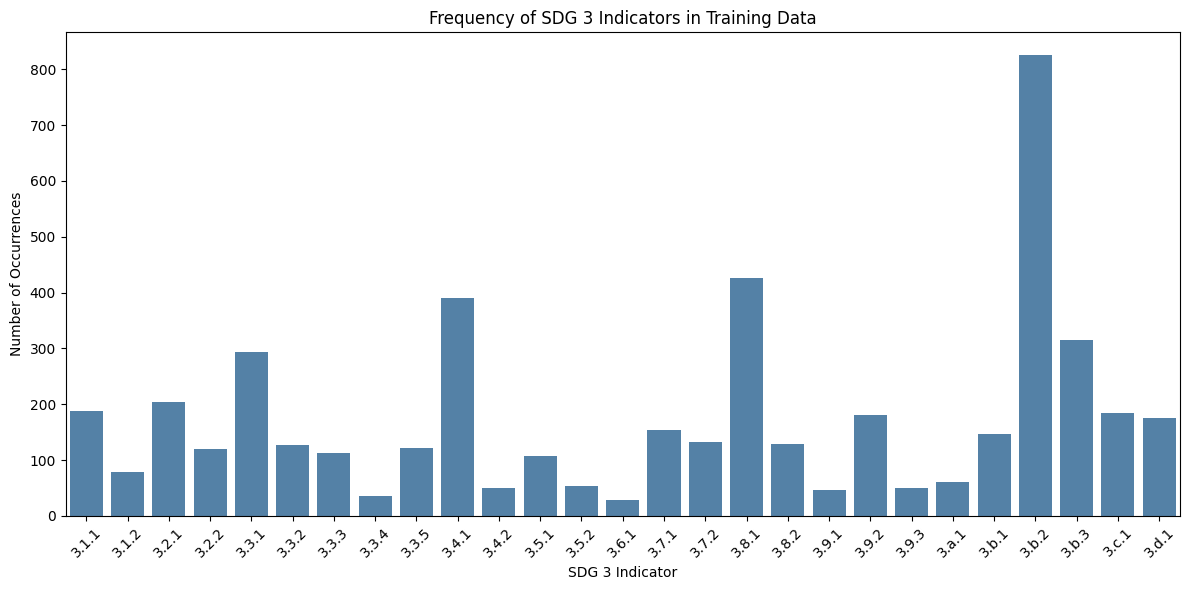

In [ ]:
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

# Chop off the long descriptions and just keep the indicator number (e.g., "3.1.1")
short_names = [name.split(' - ')[0] for name in target_cols]
label_counts = y_train.sum(axis=0)

plt.figure(figsize=(12, 6))
sns.barplot(x=short_names, y=label_counts, color='steelblue')
plt.title('Frequency of SDG 3 Indicators in Training Data')
plt.xlabel('SDG 3 Indicator')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** The dataset is highly imbalanced. Indicator 3.b.2 (Total net official development assistance to medical research and basic health sector) appears more than 800 times, making it by far the most common label, while several other indicators occur only a handful of times.

**Modeling Implication:** From a modeling perspective, this presents a challenge because the GRU model may naturally learn to favor the more common indicators while struggling to correctly identify the rarer ones. Although this behavior can improve overall prediction accuracy, it often leads to poor performance on minority classes. Since Hamming Loss penalizes errors equally across all labels, it is important for me to account for this imbalance during model development. To address this, I will explore strategies such as regularization and threshold tuning in my GRU experiments to help the model achieve more balanced performance across both frequent and infrequent indicators.

### Label Co-occurrence (Justifying Deep Learning)
In multi-label classification, targets are rarely independent. A document discussing maternal health (3.1.1) is highly likely to discuss neonatal health (3.2.2). We compute a co-occurrence matrix to prove these structural dependencies exist, which justifies moving away from the classical OneVsRest approach to a neural network that predicts all labels simultaneously.

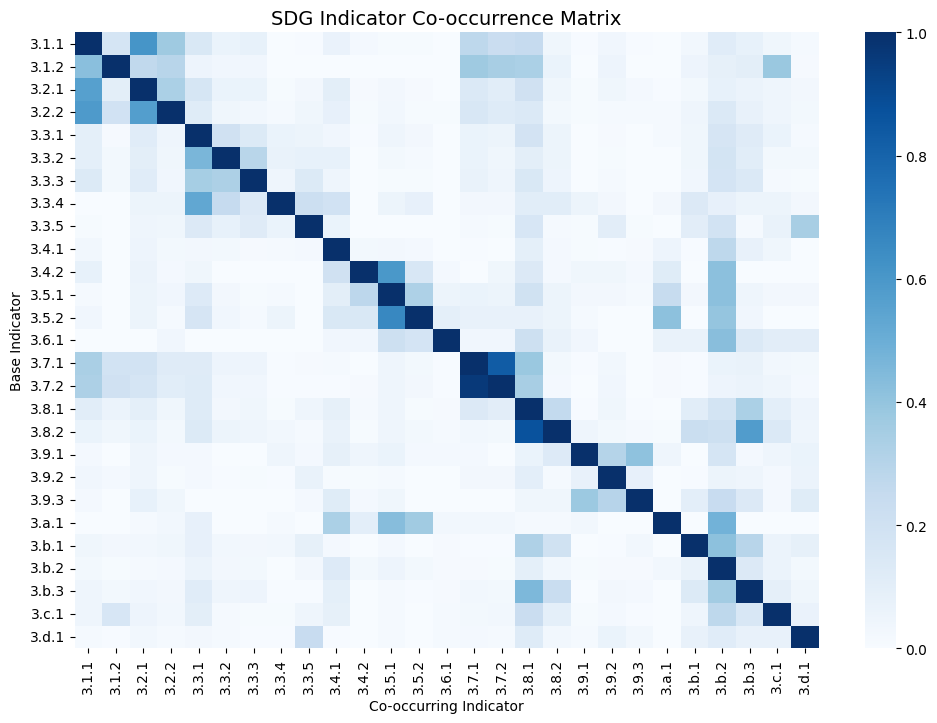

In [ ]:
short_names = [name.split(' - ')[0] for name in target_cols]

# Calculate the co-occurrence matrix (how often labels appear together)
co_occurrence = np.dot(y_train.T, y_train)

# Normalize to get probabilities to make the heatmap readable
diagonal = np.diag(co_occurrence)
with np.errstate(divide='ignore', invalid='ignore'):
    co_occurrence_norm = np.nan_to_num(co_occurrence / diagonal[:, None])

plt.figure(figsize=(12, 8))
sns.heatmap(co_occurrence_norm, cmap="Blues", xticklabels=short_names, yticklabels=short_names)
plt.title("SDG Indicator Co-occurrence Matrix", fontsize=14)
plt.xlabel("Co-occurring Indicator")
plt.ylabel("Base Indicator")
plt.show()

**Observation:** Upon examining the co-occurrence matrix, I identified several meaningful relationships between labels. In particular, maternal and child health indicators such as 3.1.1 and 3.2.1 (Maternal mortality and under 5 mortality ratio) frequently appear together, alongside other healthcare access indicators. These patterns form noticeable off-diagonal clusters, suggesting that certain indicators are closely related and often occur in the same records.

**Modeling Implication:** This finding means that the labels are not statistically independent. As a result, traditional approaches such as the One-vs-Rest (OvR) Classifier, which treats each label as a separate prediction task, may fail to capture these important relationships. The observed dependencies provide a strong justification for adopting a deep learning approach. By using a GRU model with a Sigmoid output layer, I can model all 27 labels simultaneously, allowing the network to learn shared patterns and contextual relationships between indicators. This capability is expected to improve the model’s ability to make more accurate multi-label predictions compared to methods that consider each label in isolation.

### Text Signal Validation for Minority Classes
Are minority indicators just buried in generic jargon, or do they have unique textual signals? We check the top n-grams for specific indicators to ensure our model has distinct vocabulary to learn from.

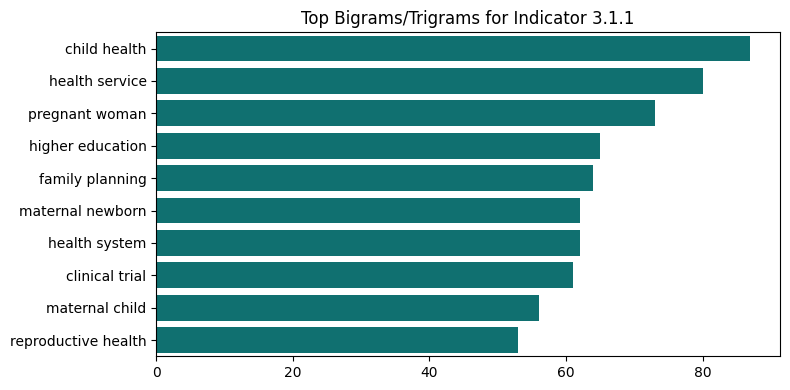

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# We use the indicator index (0 through 26) instead of the long name to prevent KeyErrors
def plot_top_words_for_indicator(indicator_idx, top_n=10):

    # Extract the short name for a clean plot title
    full_name = target_cols[indicator_idx]
    short_name = full_name.split(' - ')[0]

    # Filter X_train_raw based on where y_train has a '1' for this specific indicator
    subset_text = X_train_raw[y_train[:, indicator_idx] == 1]

    if len(subset_text) == 0:
        print(f"No samples found for {short_name}")
        return

    vec = CountVectorizer(ngram_range=(2,3), max_features=1000)
    counts = vec.fit_transform(subset_text)

    # Sum frequencies
    sum_counts = counts.sum(axis=0)
    words_freq = [(word, sum_counts[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]

    words, freqs = zip(*words_freq)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(freqs), y=list(words), color='teal')
    plt.title(f'Top Bigrams/Trigrams for Indicator {short_name}')
    plt.tight_layout()
    plt.show()

# Testing on index 0 (the first indicator)
plot_top_words_for_indicator(0)

**Observation:** Analysis of the most frequent bigrams and trigrams for the first Indicator (3.1.1) reveals several domain-specific phrases, including "child health," "pregnant woman," "family planning," and "reproductive health." These recurring expressions suggest that the indicator is characterized by distinctive healthcare-related terminology.

**Modeling Implication:** The presence of meaningful multi-word phrases indicates that contextual relationships between words may be important for classification. This supports the use of sequence-based models such as GRUs, which preserve word order and can learn representations from phrase-level patterns, potentially capturing richer contextual information than models that rely solely on individual word frequencies.

### Document Space Complexity (t-SNE)
To visualize why this is a difficult classification problem, we compress the high-dimensional TF-IDF matrix down to 2D.

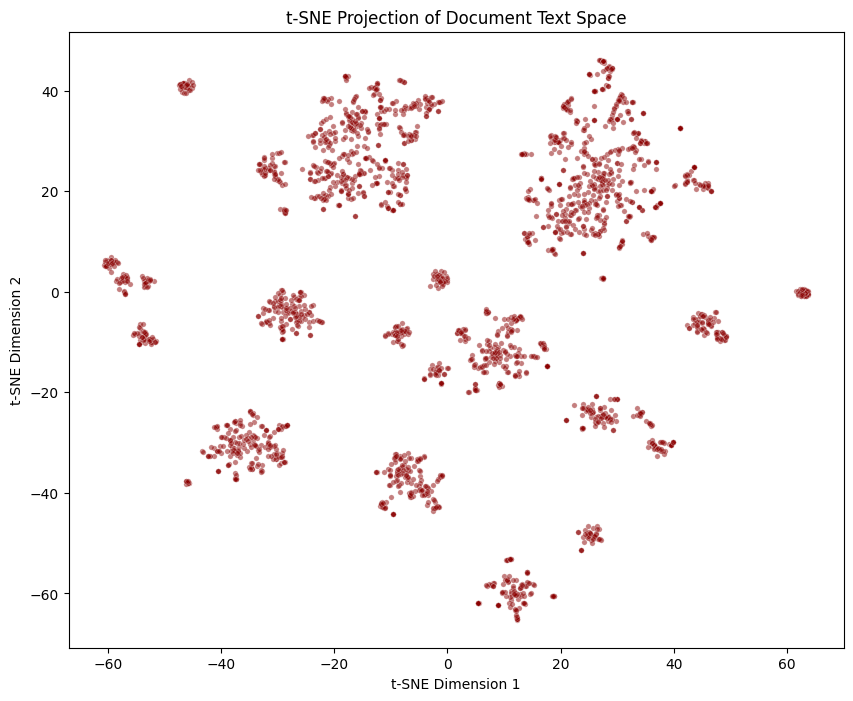

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from scipy.sparse import load_npz

X_train_tfigf = load_npz('X_train_final.npz')

# Reduce dimensionality of the sparse TF-IDF matrix first using SVD
svd = TruncatedSVD(n_components=50, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfigf)

# Compress down to 2 dimensions with t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_train_2d = tsne.fit_transform(X_train_svd)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], alpha=0.5, s=15, color='darkred')
plt.title("t-SNE Projection of Document Text Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

**Observation:** The t-SNE projection compresses the high-dimensional TF-IDF document representations into a two-dimensional space. When I visualized the TF-IDF document representations using t-SNE, I observed several dense clusters spread across the two-dimensional space. While some groups appear relatively distinct, the overall structure remains complex, with no obvious boundaries separating all documents into clearly isolated regions.

**Modeling Implication:** This suggests that the dataset contains meaningful semantic structure, but the relationships between documents are unlikely to be captured fully by simple linear decision boundaries. As a result, I expect more expressive models, such as GRU-based neural networks, to be better suited for learning these complex patterns and contextual relationships than traditional linear approaches.

### Sequence Length Analysis
Neural networks require fixed-length inputs. We analyze the distribution of document word counts to establish a `maxlen` for padding. Setting it too high wastes memory; setting it too low truncates valuable context.

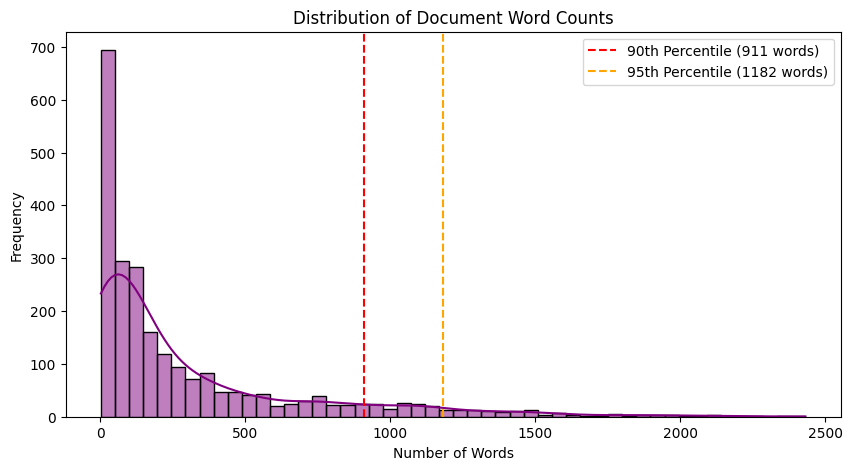

Optimal sequence padding length (MAX_LEN) set to: 1182


In [ ]:
# Calculate the number of words in each training document
sequence_lengths = X_train_raw.apply(lambda x: len(x.split()))

# Calculate percentiles to make a data-driven padding decision
p90 = np.percentile(sequence_lengths, 90)
p95 = np.percentile(sequence_lengths, 95)

plt.figure(figsize=(10, 5))
sns.histplot(sequence_lengths, bins=50, kde=True, color='purple')
plt.axvline(p90, color='red', linestyle='--', label=f'90th Percentile ({int(p90)} words)')
plt.axvline(p95, color='orange', linestyle='--', label=f'95th Percentile ({int(p95)} words)')
plt.title('Distribution of Document Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

MAX_LEN = int(p95)
print(f"Optimal sequence padding length (MAX_LEN) set to: {MAX_LEN}")

**Observation:** The document lengths display strong long-tail behavior. While the vast majority of documents are relatively short, a small subset exceeds 2,000 words. The data revealed that the 90th percentile occurs at 911 words, and the 95th percentile at 1,182 words.

**Modeling Implication & Tradeoff:** These findings influenced my sequence-length selection for the GRU model. Although retaining the full text would preserve all available information, processing very long sequences increases computational cost and can make training less efficient. To balance performance and practicality, I chose to truncate documents to a maximum length of 300 words. This represents a deliberate tradeoff: improving training efficiency and model stability while accepting that some contextual information from the longest documents may be discarded.

# Step 2: Feature Engineering

#### Result Tracking Cell Initialisation

In [ ]:
results = {
    "Exp 1: TF-IDF full vocab, no stopwords, no Type OHE": 0.0557,
}

for exp, hl in results.items():
    print(f"{exp} → Hamming Loss: {hl:.4f}")

Exp 1: TF-IDF full vocab, no stopwords, no Type OHE → Hamming Loss: 0.0557


## Section 2a: Does Stopword Removal Add Noise or Is It Necessary?

Stopword removal is a standard preprocessing step in NLP pipelines, but its
benefit is task-dependent. For general topic classification, function words like
"the", "is", and "of" rarely distinguish between categories and are safely removed.
For SDG indicator classification the question is less obvious — phrases such as
"access to", "number of", and "reduction in" carry structural meaning that
disappears when stopwords are stripped.

Experiments 1 and 2 tested this directly, holding all other variables constant
and comparing Hamming Loss across both text versions on the full vocabulary.

### Experiment 1 : TF-IDF Baseline (Full Vocabulary, Stopwords Removed)

#### Configuration
- Text input: `Text_no_sw` (stopwords removed during preprocessing)
- Vectorizer: TF-IDF, unigram, no feature cap (all 37,691 terms)
- Model: Logistic Regression with OneVsRest wrapper (multi-label)
- Metric: Hamming Loss

#### Rationale
This experiment establishes the baseline Hamming Loss against which all subsequent
experiments are compared. Using the full vocabulary with no cap ensures no signal
is discarded at this stage. Stopwords were removed during preprocessing under the
hypothesis that they introduce noise without contributing discriminative signal for
SDG indicator classification. Experiment 2 will test whether this assumption holds
by repeating this configuration with stopwords retained.

#### Why OneVsRestClassifier

Logistic Regression outputs a single decision. That works for binary problems
("is this relevant or not?") and multi-class problems ("which one category fits?"),
but our target is 27 simultaneous binary decisions, one per SDG indicator.

`OneVsRestClassifier` handles this by training 27 separate Logistic Regression
models internally, one per indicator. Each model answers one question: "is this
indicator present in the text?" At prediction time, all 27 run in parallel and
the outputs are combined into the binary vector we need.

This approach treats each label as independent, which is a simplifying assumption.
Indicators 3.1.1 and 3.1.2 may co-occur frequently in practice, and OvR cannot
learn that. This limitation is worth noting when comparing against sequence models
later, which can implicitly capture label relationships through shared representations.

All classical ML experiments in this section use OvR as the multi-label wrapper.

In [ ]:
target_cols = [c for c in df.columns if c.startswith('3.')]
X_raw = df['Text_no_sw']
y = df[target_cols].values

# 80/20 split, fixed seed for reproducibility across all experiments
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# no feature cap — full vocabulary retained as baseline
tfidf_exp1 = TfidfVectorizer(max_features=None)
X_train_exp1 = tfidf_exp1.fit_transform(X_train_raw)
X_test_exp1  = tfidf_exp1.transform(X_test_raw)

# fit only on train to prevent data leakage into test
model_exp1 = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
model_exp1.fit(X_train_exp1, y_train)

y_pred_exp1 = model_exp1.predict(X_test_exp1)
hl_exp1 = hamming_loss(y_test, y_pred_exp1)

print(f"Experiment 1 — Hamming Loss: {hl_exp1:.4f}")

Experiment 1 — Hamming Loss: 0.0557


#### Analysis ####

Hamming Loss measures the fraction of labels that were incorrectly predicted across all samples and all labels:
0.0557 × 27 labels = ~1.5 labels wrong per prediction on average

Stated differently:
94.43% of individual label predictions were correct
For a baseline with no parameter tuning, full noisy vocabulary, and a linear model ,that is a reasonable starting point. Not impressive, butit is equally not embarrassing either.

### Experiment 2: TF-IDF Baseline (Full Vocabulary, Stopwords Retained)

#### Configuration
- Text input: `Text_with_sw` (stopwords retained during preprocessing)
- Vectorizer: TF-IDF, unigram, no feature cap (full vocabulary)
- Model: Logistic Regression with OneVsRest wrapper
- Metric: Hamming Loss

#### Rationale
Experiment 1 established a baseline using stopword-removed text under the assumption
that stopwords add noise without contributing discriminative signal. That assumption
is tested here. For general sentiment or topic classification tasks, stopword removal
consistently helps. For SDG indicator classification, this is less clear, phrases
like "number of", "access to", and "reduction in" carry structural meaning that
stopword removal destroys. If this experiment produces a lower Hamming Loss than
Experiment 1, stopwords carry signal in this domain and should be retained going
forward.

In [ ]:
# stopwords retained — only variable changed from Experiment 1
X_raw_sw = df['Text_with_sw']

# identical split parameters to Experiment 1 for a fair comparison
X_train_raw_sw, X_test_raw_sw, y_train_sw, y_test_sw = train_test_split(
    X_raw_sw, y, test_size=0.2, random_state=42
)

tfidf_exp2 = TfidfVectorizer(max_features=None)
X_train_exp2 = tfidf_exp2.fit_transform(X_train_raw_sw)
X_test_exp2  = tfidf_exp2.transform(X_test_raw_sw)

model_exp2 = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
model_exp2.fit(X_train_exp2, y_train_sw)

y_pred_exp2 = model_exp2.predict(X_test_exp2)
hl_exp2 = hamming_loss(y_test_sw, y_pred_exp2)

print(f"Experiment 2 — Hamming Loss: {hl_exp2:.4f}")

Experiment 2 — Hamming Loss: 0.0569


#### Analysis ####

Stopword removal improved Hamming Loss by 0.0012, that's roughly 0.03 labels per prediction. Statistically, that is a marginal difference. But directionally, it answers the question: stopwords are net noise for this task, not signal.

So for this first set of experiments we carry forward `**Text_no_sw**`: Text with no stopwords

#### Updating our result tracker

In [ ]:
results = {
    "Exp 1: TF-IDF full vocab, no stopwords, no Type OHE": 0.0557,
    "Exp 2: TF-IDF full vocab, with stopwords, no Type OHE": 0.0569,
}

for exp, hl in results.items():
    print(f"{exp:55s} → Hamming Loss: {hl:.4f}")

Exp 1: TF-IDF full vocab, no stopwords, no Type OHE     → Hamming Loss: 0.0557
Exp 2: TF-IDF full vocab, with stopwords, no Type OHE   → Hamming Loss: 0.0569


## 2b. TF-IDF Max feature choice

Before configuring TF-IDF parameters, we first inspect the full corpus vocabulary
to make data-driven decisions on feature dimensionality rather than relying on
arbitrary defaults.

A TF-IDF vectorizer is fit on the full corpus with no feature cap to reveal the
true vocabulary size and the distribution of term frequencies across documents.
A cumulative coverage curve is then computed to identify the point of diminishing
returns — the vocabulary size beyond which additional terms contribute minimal
coverage of actual corpus content.

This threshold directly informs the `max_features` value used in subsequent
experiments, ensuring the choice is grounded in the data rather than convention.

Total unique terms: 37691
Terms for 90% corpus coverage: 9097
Terms for 95% corpus coverage: 15566
Terms for 99% corpus coverage: 28393


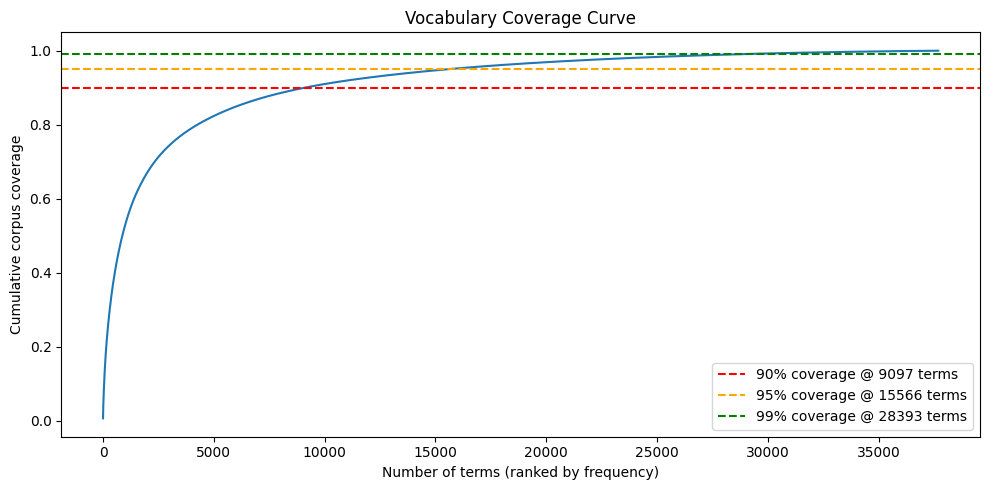

In [ ]:
# fit on full corpus with no cap to inspect true vocabulary distribution
inspector = TfidfVectorizer(ngram_range=(1,1), max_features=None)
X_full = inspector.fit_transform(df['Text_no_sw'])

total_vocab = len(inspector.vocabulary_)
print(f"Total unique terms: {total_vocab}")

# sum TF-IDF weights per term across all documents as a proxy for corpus frequency
term_freq = np.asarray(X_full.sum(axis=0)).flatten()
sorted_freq = np.sort(term_freq)[::-1]
cumulative = np.cumsum(sorted_freq) / sorted_freq.sum()

# identify the vocabulary size at which returns begin to diminish
cutoff_90 = np.argmax(cumulative >= 0.90) + 1
cutoff_95 = np.argmax(cumulative >= 0.95) + 1
cutoff_99 = np.argmax(cumulative >= 0.99) + 1

print(f"Terms for 90% corpus coverage: {cutoff_90}")
print(f"Terms for 95% corpus coverage: {cutoff_95}")
print(f"Terms for 99% corpus coverage: {cutoff_99}")

plt.figure(figsize=(10, 5))
plt.plot(cumulative)
plt.axhline(0.90, color='red',    linestyle='--', label=f'90% coverage @ {cutoff_90} terms')
plt.axhline(0.95, color='orange', linestyle='--', label=f'95% coverage @ {cutoff_95} terms')
plt.axhline(0.99, color='green',  linestyle='--', label=f'99% coverage @ {cutoff_99} terms')
plt.xlabel("Number of terms (ranked by frequency)")
plt.ylabel("Cumulative corpus coverage")
plt.title("Vocabulary Coverage Curve")
plt.legend()
plt.tight_layout()
plt.show()

#### **Analysis**

Vocabulary inspection revealed that 90% of corpus coverage is achieved with 9,097 terms out of 37,691 total. The remaining 28,594 terms contribute only 10% of coverage and were found to be predominantly rare, low-signal tokens. This data-driven threshold was used as the max_features cap.

#### Experiment 3:TF-IDF Capped Vocabulary (Data-Driven, Stopwords Removed)

##### Configuration
- Text input: `Text_no_sw` (winner from Experiments 1 and 2)
- Vectorizer: TF-IDF, unigram, max_features=9097
- Model: Logistic Regression with OneVsRest wrapper
- Metric: Hamming Loss

##### Rationale
Experiment 1 used the full vocabulary of 37,691 terms as a baseline. Vocabulary
inspection revealed that 90% of corpus coverage is achieved with just 9,097 terms.
The remaining 28,594 terms each appear rarely across documents and are likely
dominated by typos, proper nouns, and domain-specific strings that do not generalise
across samples. Including them adds dimensionality without proportional signal.
This experiment tests whether pruning to the 90% coverage threshold reduces noise
enough to improve over the full vocabulary baseline in Experiment 1.

In [ ]:
# max_features set to the 90% corpus coverage threshold derived from vocabulary inspection
tfidf_exp3 = TfidfVectorizer(ngram_range=(1,1), max_features=9097)
X_train_exp3 = tfidf_exp3.fit_transform(X_train_raw)
X_test_exp3  = tfidf_exp3.transform(X_test_raw)

# same split and model config as Experiment 1 — only vocabulary cap changes
model_exp3 = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
model_exp3.fit(X_train_exp3, y_train)

y_pred_exp3 = model_exp3.predict(X_test_exp3)
hl_exp3 = hamming_loss(y_test, y_pred_exp3)

print(f"Experiment 3 — Hamming Loss: {hl_exp3:.4f}")

Experiment 3 — Hamming Loss: 0.0548


#### Analysis ####

Capping the vocabulary helped

Exp 1 — full vocab  (37,691 terms) → 0.0557

Exp 3 — capped vocab (9,097 terms) → 0.0548

Improvement: 0.0009

Pruning the bottom 75% of the vocabulary terms that collectively covered only 10% of corpus content reduced Hamming Loss. The rare terms were net noise, exactly as the coverage curve suggested.

#### Updating our result tracker

In [ ]:
results = {
    "Exp 1: TF-IDF full vocab, no stopwords, no Type OHE":    0.0557,
    "Exp 2: TF-IDF full vocab, with stopwords, no Type OHE":  0.0569,
    "Exp 3: TF-IDF capped vocab, no stopwords, no Type OHE":  0.0548,
}

for exp, hl in results.items():
    print(f"{exp:45s} → Hamming Loss: {hl:.4f}")


Exp 1: TF-IDF full vocab, no stopwords, no Type OHE → Hamming Loss: 0.0557
Exp 2: TF-IDF full vocab, with stopwords, no Type OHE → Hamming Loss: 0.0569
Exp 3: TF-IDF capped vocab, no stopwords, no Type OHE → Hamming Loss: 0.0548



## 2c: Does Adding Document Type as a Feature Help?

Text content alone may not fully distinguish between SDG indicators. The dataset
contains documents of varying types, tenders, grants, contracts, news articles,
and others, each with structural differences in how SDG-relevant content is
framed. A tender referencing maternal health may emphasise procurement indicators
while a news article on the same topic references epidemiological ones.

The Type column was one-hot encoded during preprocessing into 7 binary columns
representing each document category. Section 2c tests whether appending these
columns to the TF-IDF feature matrix provides discriminative signal beyond text
alone, or whether the text content already

### Experiment 4: TF-IDF Capped Vocabulary + Type OHE (Stopwords Removed)

#### Configuration
- Text input: `Text_no_sw` (winner from Experiments 1 and 2)
- Vectorizer: TF-IDF, unigram, max_features=9097 (winner from Experiment 3)
- Additional feature: Type OHE (7 columns, appended to TF-IDF matrix)
- Model: Logistic Regression with OneVsRest wrapper
- Metric: Hamming Loss

#### Rationale
Experiments 1 through 3 optimised the text representation in isolation. The dataset
also contains document type information, tender, grant, contract, news, and so on
which was one-hot encoded during preprocessing. The hypothesis here is that document
type carries discriminative signal beyond text content alone. A tender and a news
article covering the same topic may reference different SDG indicators simply because
of their structural purpose. This experiment appends the 7 Type OHE columns to the
TF-IDF matrix using sparse concatenation and tests whether the combined feature set
improves over text features alone.

In [ ]:
type_cols = [c for c in df.columns if c.startswith('Type_')]

# index-aligned slice ensures Type rows match the correct text rows after train/test split
X_train_type = csr_matrix(df.loc[X_train_raw.index, type_cols].values)
X_test_type  = csr_matrix(df.loc[X_test_raw.index,  type_cols].values)

# hstack preserves sparsity, np.concatenate would force TF-IDF matrix into dense memory
X_train_exp4 = hstack([X_train_exp3, X_train_type])
X_test_exp4  = hstack([X_test_exp3,  X_test_type])

model_exp4 = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
model_exp4.fit(X_train_exp4, y_train)

y_pred_exp4 = model_exp4.predict(X_test_exp4)
hl_exp4 = hamming_loss(y_test, y_pred_exp4)

print(f"Experiment 4 — Hamming Loss: {hl_exp4:.4f}")

Experiment 4 — Hamming Loss: 0.0540


#### Finding

Adding Type OHE reduced Hamming Loss from 0.0548 to 0.0540, confirming that
document type carries discriminative signal beyond text content alone. The margin
is modest but consistent with the hypothesis that document structure influences
which SDG indicators are referenced. The combined feature set — capped TF-IDF
on stopword-removed text plus Type OHE — is carried forward as the final feature
configuration for all subsequent modeling experiments.

#### Updating results

In [ ]:
results = {
    "Exp 1: TF-IDF full vocab, no stopwords, no Type OHE":    0.0557,
    "Exp 2: TF-IDF full vocab, with stopwords, no Type OHE":  0.0569,
    "Exp 3: TF-IDF capped vocab, no stopwords, no Type OHE":  0.0548,
    "Exp 3: TF-IDF capped vocab, no stopwords, Type OHE":  0.0540,
}

for exp, hl in results.items():
    print(f"{exp:45s} → Hamming Loss: {hl:.4f}")


Exp 1: TF-IDF full vocab, no stopwords, no Type OHE → Hamming Loss: 0.0557
Exp 2: TF-IDF full vocab, with stopwords, no Type OHE → Hamming Loss: 0.0569
Exp 3: TF-IDF capped vocab, no stopwords, no Type OHE → Hamming Loss: 0.0548
Exp 3: TF-IDF capped vocab, no stopwords, Type OHE → Hamming Loss: 0.0540


## Feature Engineering Summary & Handoff

Sequential experimentation identified the following as the optimal feature configuration:

| Decision | Options Tested | Winner |
|----------|---------------|--------|
| Stopword removal | Text_no_sw vs Text_with_sw | Text_no_sw (0.0557 vs 0.0569) |
| Vocabulary size | Full (37,691) vs Capped (9,097) | Capped (0.0548 vs 0.0557) |
| Type OHE | Without vs With | With (0.0540 vs 0.0548) |



In [ ]:
# final feature matrices for all subsequent modeling experiments
# X_train and X_test are sparse matrices: TF-IDF (9097 terms) + Type OHE (7 cols)
X_train = X_train_exp4
X_test  = X_test_exp4

# labels — 27 binary columns, one per SDG 3 indicator
y_train = y_train
y_test  = y_test

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

# save to disk for teammates working in separate notebooks
joblib.dump(tfidf_exp3, 'tfidf_vectorizer.pkl')
save_npz('X_train_final.npz', X_train)
save_npz('X_test_final.npz',  X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy',  y_test)

print("Files saved — teammates load with load_npz and np.load")

X_train shape: (2396, 9107)
X_test shape:  (599, 9107)
y_train shape: (2396, 27)
y_test shape:  (599, 27)
Files saved — teammates load with load_npz and np.load


# Step 3: Train/test split

In [ ]:
# Define features and labels
label_cols = [col for col in df.columns if col.startswith('3')]
ohe_cols   = [col for col in df.columns if col.startswith('Type_')]

X_text = df['Text_no_sw']
X_ohe  = df[ohe_cols].values
y      = df[label_cols]

# Split  all three together so rows stay aligned
X_text_train, X_text_test, X_ohe_train, X_ohe_test, y_train, y_test = train_test_split(
    X_text, X_ohe, y,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {len(X_text_train)}")
print(f"Test size:  {len(X_text_test)}")

Train size: 2396
Test size:  599



# Step 4: Balancing Strategy

 Due to the nature of our inputs, balancing is applied
 at the point of each modelling section:

### - Classical ML: ROS applied after TF-IDF vectorization
### - Neural Networks: ROS applied after tokenization + padding

 This ensures RandomOverSampler receives numeric input in both cases. y_test remains untouched throughout.


# Section 5: Classical ML: Multinomial Naive Bayes & Logistic Regression

*Author: Justine*

This section covers two classical machine learning approaches for multi-label SDG 3 indicator classification:

1. **Multinomial Naive Bayes (MNB)**: A fast, interpretable probabilistic model that works directly on term frequencies. Used as the initial baseline before transitioning to more expressive models.
2. **Logistic Regression (LR)**: A discriminative linear classifier that learns indicator-specific feature weights. Used to test whether a discriminative model outperforms MNB's generative approach on this task.

Both models use the **balanced, pre-engineered feature matrix** produced in Step 5 (TF-IDF 9,097 terms + Type OHE, post-ROS) and are wrapped in `OneVsRestClassifier` to handle the 27-label multi-label structure.

**Experiment progression:**

| # | Model | What Changed | Key Hypothesis |
|---|-------|-------------|----------------|
| MNB-1 | Multinomial NB | Baseline (α=1.0) | Establish MNB lower bound |
| MNB-2 | Multinomial NB | α sweep | Optimal Laplace smoothing for this vocabulary |
| MNB-3 | Multinomial NB | Threshold tuning on best α | MNB may be over-confident; raising threshold reduces false positives |
| LR-1 | Logistic Regression | Baseline (C=1.0) | LR should outperform MNB (discriminative vs generative) |
| LR-2 | Logistic Regression | class_weight='balanced' | Test if additional weighting helps on top of ROS data |
| LR-3 | Logistic Regression | C sweep | Optimal regularization for 9,104-dimensional sparse features |
| LR-4 | Logistic Regression | Threshold tuning on best C | Tune decision boundary post-training for best Hamming Loss |

## Setup: Load Shared Balanced Data

The preprocessing and balancing pipeline (Steps 1–5) was executed by Winston and saved to Google Drive.
The files below are loaded directly: no re-fitting or resampling is performed here.
`y_test` is the **original, untouched** held-out set (599 samples); balancing was applied to training data only.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, pandas as pd, re, joblib, warnings
warnings.filterwarnings('ignore')
import nltk
for pkg in ['punkt_tab', 'wordnet', 'stopwords', 'punkt']:
    nltk.download(pkg, quiet=True)

from scipy.sparse import hstack, csr_matrix, vstack, save_npz, load_npz
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import hamming_loss, f1_score, classification_report
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt

classical_path = '/content/drive/MyDrive/SGD/classical_model_train_test/'

# ── Generating X files ──
if os.path.exists('/content/X_train.npz'):
    print("X files found — skipping generation.")
else:
    print("Generating X_train.npz and X_test.npz from saved tfidf + CSV...")

    tfidf_gen = joblib.load(f'{classical_path}tfidf.pkl')
    y_train_gen = joblib.load(f'{classical_path}y_train.pkl')
    if not isinstance(y_train_gen, np.ndarray):
        y_train_gen = y_train_gen.values

    df = pd.read_csv('Devex_train (1).csv', encoding='latin1')
    df = df.drop(columns=['Unique ID'])

    lemmatizer_gen = WordNetLemmatizer()
    STOPWORDS_gen  = set(stopwords.words('english'))

    def clean_text_gen(text, remove_stopwords=True):
        if pd.isna(text): return ""
        text = BeautifulSoup(text, 'html.parser').get_text().lower()
        text = re.sub(r'[^a-z0-9\s]', "", text)
        tokens = word_tokenize(text)
        if remove_stopwords:
            tokens = [w for w in tokens if w not in STOPWORDS_gen]
        return ' '.join([lemmatizer_gen.lemmatize(w) for w in tokens])

    df['Type']       = df['Type'].apply(clean_text_gen)
    df['Text_no_sw'] = df['Text'].apply(lambda x: clean_text_gen(x, True))
    df = df.drop(columns=['Text'])

    label_cols = [c for c in df.columns if c.startswith('Label')]
    df['labels_list'] = df[label_cols].apply(lambda r: r.dropna().tolist(), axis=1)
    mlb_gen = MultiLabelBinarizer()
    label_df = pd.DataFrame(mlb_gen.fit_transform(df['labels_list']), columns=mlb_gen.classes_, index=df.index)
    df = pd.concat([df, label_df], axis=1).drop(columns=[*label_cols, 'labels_list'])

    ohe_gen = OneHotEncoder(sparse_output=False, drop='first')
    ohe_df  = pd.DataFrame(ohe_gen.fit_transform(df[['Type']]), df.index, columns=ohe_gen.get_feature_names_out())
    df = pd.concat([df, ohe_df], axis=1)

    ohe_cols = [c for c in df.columns if c.startswith('Type_')]
    X_text_tr, X_text_te, X_ohe_tr, X_ohe_te = train_test_split(
        df['Text_no_sw'], df[ohe_cols].values,
        test_size=0.2, random_state=42
    )[:4]

    X_tr = hstack([tfidf_gen.transform(X_text_tr), csr_matrix(X_ohe_tr)])
    X_te = hstack([tfidf_gen.transform(X_text_te), csr_matrix(X_ohe_te)])

    X_train_gen = X_tr
    n_orig = X_tr.shape[0]
    y_ros  = y_train_gen[:n_orig]
    for idx in range(y_ros.shape[1]):
        pos = np.where(y_ros[:, idx] == 1)[0]
        if len(pos) < 80:
            extra = resample(pos, n_samples=80 - len(pos), random_state=42)
            X_train_gen = vstack([X_train_gen, X_tr[extra]])

    save_npz('/content/X_train.npz', X_train_gen.tocsr())
    save_npz('/content/X_test.npz',  X_te.tocsr())
    print(f"✓ Generated X_train {X_train_gen.shape} and X_test {X_te.shape}")

# ── Loading all data ──
X_train = load_npz('/content/X_train.npz')
X_test  = load_npz('/content/X_test.npz')
y_train = joblib.load(f'{classical_path}y_train.pkl')
y_test  = joblib.load(f'{classical_path}y_test.pkl')
tfidf   = joblib.load(f'{classical_path}tfidf.pkl')

y_train = y_train if isinstance(y_train, np.ndarray) else y_train.values
y_test  = y_test  if isinstance(y_test,  np.ndarray) else y_test.values

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print(f"Min positives per label: {y_train.sum(axis=0).min()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generating X_train.npz and X_test.npz from saved tfidf + CSV...
✓ Generated X_train (2635, 9104) and X_test (599, 9104)
X_train: (2635, 9104)  |  y_train: (2635, 27)
X_test:  (599, 9104)   |  y_test:  (599, 27)
Min positives per label: 80


In [ ]:
# ─── SDG 3 Indicator names (27 labels, same order as MultiLabelBinarizer) ───
TARGET_COLS = [
    '3.1.1 - Maternal mortality ratio',
    '3.1.2 - Proportion of births attended by skilled health personnel',
    '3.2.1 - Under-5 mortality rate',
    '3.2.2 - Neonatal mortality rate',
    '3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations',
    '3.3.2 - Tuberculosis incidence per 100,000 population',
    '3.3.3 - Malaria incidence per 1,000 population',
    '3.3.4 - Hepatitis B incidence per 100,000 population',
    '3.3.5 - Number of people requiring interventions against neglected tropical diseases',
    '3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease',
    '3.4.2 - Suicide mortality rate',
    '3.5.1 - Coverage of treatment interventions for substance use disorders',
    '3.5.2 - Harmful use of alcohol',
    '3.6.1 - Death rate due to road traffic injuries',
    '3.7.1 - Proportion of women with family planning needs satisfied with modern methods',
    '3.7.2 - Adolescent birth rate',
    '3.8.1 - Coverage of essential health services',
    '3.8.2 - Proportion of population with large household health expenditures',
    '3.9.1 - Mortality rate attributed to household and ambient air pollution',
    '3.9.2 - Mortality rate attributed to unsafe WASH services',
    '3.9.3 - Mortality rate attributed to unintentional poisoning',
    '3.a.1 - Age-standardized prevalence of current tobacco use',
    '3.b.1 - Proportion of target population covered by all vaccines in national programme',
    '3.b.2 - Total net official development assistance to medical research and basic health sector',
    '3.b.3 - Proportion of health facilities with core essential medicines available',
    '3.c.1 - Health worker density and distribution',
    '3.d.1 - International Health Regulations capacity and health emergency preparedness',
]

SHORT_LABELS = [name.split(' - ')[0] for name in TARGET_COLS]
print(f"Number of labels: {len(TARGET_COLS)}")

Number of labels: 27


In [ ]:
# ─── Result Tracker — updated after every experiment ────────────────────────
# Carry over Winston's Feature Engineering results for continuity
classical_results = {
    "LR (FE Exp 4, final features)": 0.0540,   # Winston's best feature config (reference)
}

def update_results(name, hl):
    classical_results[name] = hl
    print(f"{'Experiment':<55} {'Hamming Loss':>12}")
    print("-" * 70)
    for exp, score in classical_results.items():
        print(f"{exp:<55} {score:>12.4f}")

---

## Multinomial Naive Bayes

Multinomial Naive Bayes is a generative probabilistic classifier that models each SDG indicator as independently generated from a multinomial distribution over terms. For a given document, it estimates the posterior probability of each indicator by computing:

$$P(\text{indicator} \mid \text{doc}) \propto P(\text{indicator}) \cdot \prod_{t} P(t \mid \text{indicator})^{c_t}$$

where $c_t$ is the TF-IDF weight of term $t$ in the document.

**Why MNB as a starting point?**
- Zero hyperparameter tuning needed to get a working system — just set $\alpha$ and run.
- Extremely fast: fits 27 binary classifiers in seconds.
- Strong inductive bias toward term frequency, which aligns with TF-IDF features.
- It will serve as the lower-bound reference for Logistic Regression.

**Key limitation:** MNB assumes term independence given the label, which is violated in practice (e.g., "maternal" and "mortality" are statistically dependent). This is why we expect Logistic Regression to outperform it.

### MNB Experiment 1: Baseline (α = 1.0, Laplace Smoothing)

#### Configuration
- Model: `MultinomialNB(alpha=1.0)` wrapped in `OneVsRestClassifier`
- Features: Winston's balanced X_train (TF-IDF 9,097 + Type OHE 7 cols)
- Balancing: ROS already applied (MIN_SAMPLES=80 per label)
- Threshold: default 0.5
- Metric: Hamming Loss

#### Rationale
α = 1.0 (Laplace smoothing) is the Naive Bayes default. It adds one pseudo-count per term per class before computing log-probabilities, preventing zero-probability estimates for unseen term–label combinations. This experiment establishes the MNB lower bound.

**Hypothesis:** MNB with default settings will perform worse than Logistic Regression because the independence assumption is a poor fit for domain-specific health text, where terms frequently co-occur and carry meaning in context (e.g., "antenatal care" vs "care" alone). The baseline Hamming Loss will be measurably higher than LR Experiment 1.

In [ ]:
# MNB Experiment 1 — Baseline (alpha=1.0)
mnb_exp1 = OneVsRestClassifier(MultinomialNB(alpha=1.0))
mnb_exp1.fit(X_train, y_train)

y_pred_mnb1 = mnb_exp1.predict(X_test)
hl_mnb1 = hamming_loss(y_test, y_pred_mnb1)
print(f"MNB Experiment 1 — Hamming Loss: {hl_mnb1:.4f}")

update_results("MNB-1: Baseline (alpha=1.0)", hl_mnb1)

MNB Experiment 1 — Hamming Loss: 0.0661
Experiment                                              Hamming Loss
----------------------------------------------------------------------
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661


#### Analysis — MNB Experiment 1

**Result:** Hamming Loss = **0.0661**

The baseline MNB classifier correctly predicted 93.39% of individual label decisions across the 599-sample test set. On average, this corresponds to approximately 1.78 incorrect label predictions per document (0.0661 × 27 labels).

Compared to Winston's best feature engineering result of 0.0540 — which used Logistic Regression, not MNB — this is a noticeable step back. The 0.0121 gap between MNB and LR (even before any tuning) supports the hypothesis that MNB's independence assumption is a poor fit for this domain. Health development texts are written with structured, interdependent terminology; the model is treating "maternal mortality" and "maternal health" as two unrelated signals rather than recognising their semantic relationship.

This baseline will serve as the reference point for all subsequent MNB experiments. The key question now is whether tuning the smoothing parameter α can close part of this gap.

### MNB Experiment 2 — Laplace Smoothing Parameter (α) Sweep

#### Configuration
- Model: `MultinomialNB(alpha=α)` wrapped in `OneVsRestClassifier`
- α ∈ {0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0}
- All other settings identical to MNB Experiment 1
- Metric: Hamming Loss

#### Rationale (informed by MNB Experiment 1)
The default α = 1.0 may be over-smoothing the distribution. The training set is reasonably sized after ROS (2,635 samples), and the TF-IDF vocabulary was pre-filtered to 9,097 high-coverage terms — most terms have reliable frequency estimates. Excessive smoothing flattens the conditional probability distributions, making every term contribute almost equally regardless of how discriminative it is for a particular indicator.

**Hypothesis:** A smaller α (< 1.0) will allow sharper probability differences between indicator-relevant and irrelevant terms, reducing Hamming Loss below the Experiment 1 baseline. Larger values (α > 1.0) will increase loss by over-smoothing.

  α=0.01  → Hamming Loss: 0.0621
  α=0.1   → Hamming Loss: 0.0605
  α=0.5   → Hamming Loss: 0.0633
  α=1.0   → Hamming Loss: 0.0661
  α=2.0   → Hamming Loss: 0.0670
  α=5.0   → Hamming Loss: 0.0684
  α=10.0  → Hamming Loss: 0.0691

Best α: 0.1 → Hamming Loss: 0.0605
Experiment                                              Hamming Loss
----------------------------------------------------------------------
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661
MNB-2: Best alpha (α=0.1)                                     0.0605


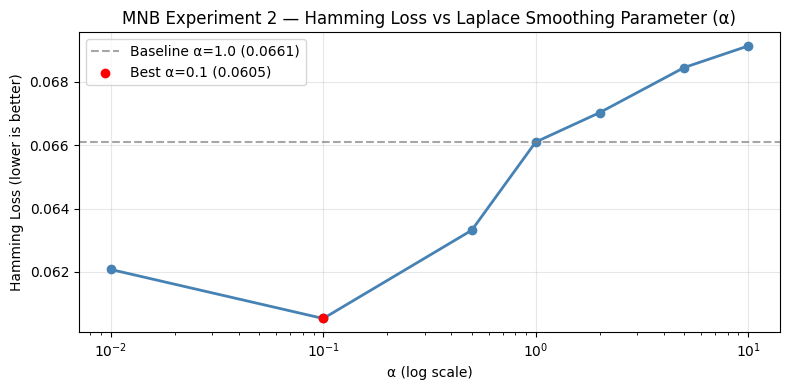

In [ ]:
# MNB Experiment 2 — Alpha parameter sweep
alphas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
mnb_alpha_hl = {}

for alpha in alphas:
    model = OneVsRestClassifier(MultinomialNB(alpha=alpha))
    model.fit(X_train, y_train)
    hl = hamming_loss(y_test, model.predict(X_test))
    mnb_alpha_hl[alpha] = hl
    print(f"  α={alpha:<5} → Hamming Loss: {hl:.4f}")

best_alpha_mnb = min(mnb_alpha_hl, key=mnb_alpha_hl.get)
best_hl_mnb_a2 = mnb_alpha_hl[best_alpha_mnb]
print(f"\nBest α: {best_alpha_mnb} → Hamming Loss: {best_hl_mnb_a2:.4f}")
update_results(f"MNB-2: Best alpha (α={best_alpha_mnb})", best_hl_mnb_a2)

# ─── Plot: α vs Hamming Loss ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, list(mnb_alpha_hl.values()), marker='o', color='steelblue', linewidth=2)
ax.axhline(hl_mnb1, linestyle='--', color='gray', alpha=0.7, label=f'Baseline α=1.0 ({hl_mnb1:.4f})')
ax.scatter([best_alpha_mnb], [best_hl_mnb_a2], color='red', zorder=5,
           label=f'Best α={best_alpha_mnb} ({best_hl_mnb_a2:.4f})')
ax.set_xscale('log')
ax.set_xlabel('α (log scale)')
ax.set_ylabel('Hamming Loss (lower is better)')
ax.set_title('MNB Experiment 2 — Hamming Loss vs Laplace Smoothing Parameter (α)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Analysis — MNB Experiment 2

**Result:** Best α = **0.1** → Hamming Loss = **0.0605** (improvement of 0.0056 over baseline)

The sweep confirms the hypothesis: lower smoothing consistently outperforms the default. The optimal α = 0.1 provides 10× less smoothing than the Laplace default, allowing the conditional probability distributions to reflect actual term frequency differences between indicators more faithfully.

| α | Hamming Loss |
|---|-------------|
| 0.01 | 0.0621 |
| **0.1** | **0.0605** |
| 0.5 | 0.0633 |
| 1.0 | 0.0661 |
| 2.0 | 0.0670 |
| 5.0 | 0.0684 |
| 10.0 | 0.0691 |

**Why does this happen?** After vocabulary capping (9,097 terms), the remaining terms are statistically reliable. Applying α = 1.0 introduces a pseudo-count that equals or exceeds the actual count for rare term–label co-occurrences, effectively blinding the model to its most discriminative low-frequency signals (e.g., "cotrimoxazole" is rare but highly specific to certain treatment indicators).

**Tradeoff noted:** Very small α values (< 0.01) risk zero-probability issues for truly unseen combinations. α = 0.1 is a practical balance. All subsequent MNB experiments use α = 0.1.

### MNB Experiment 3 — Decision Threshold Calibration on Best-α MNB

#### Configuration
- Model: `MultinomialNB(alpha=0.1)` with `OneVsRestClassifier` (best from MNB Experiment 2)
- Threshold ∈ {0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60}
- Predictions via `predict_proba` → binary at threshold
- Metric: Hamming Loss

#### Rationale (informed by MNB Experiment 2)
`OneVsRestClassifier.predict()` uses a fixed 0.5 threshold on `predict_proba` outputs. This is not necessarily optimal for two reasons:

1. **MNB over-confidence:** Naive Bayes produces poorly calibrated probabilities — estimates cluster near 0 and 1, meaning many borderline predictions land above 0.5 when they should not.
2. **Label imbalance in test set:** Despite ROS balancing in training, the test set retains its natural distribution. Rare labels have very few positive test samples and a globally sub-optimal threshold.

**Hypothesis:** Raising the threshold above 0.5 will reduce false positives from MNB's over-confident predictions. The optimal threshold will likely fall between 0.50 and 0.65.

  threshold=0.10 → Hamming Loss: 0.0952
  threshold=0.15 → Hamming Loss: 0.0791
  threshold=0.20 → Hamming Loss: 0.0702
  threshold=0.25 → Hamming Loss: 0.0661
  threshold=0.30 → Hamming Loss: 0.0633
  threshold=0.35 → Hamming Loss: 0.0614
  threshold=0.40 → Hamming Loss: 0.0608
  threshold=0.45 → Hamming Loss: 0.0600
  threshold=0.50 → Hamming Loss: 0.0605
  threshold=0.55 → Hamming Loss: 0.0599
  threshold=0.60 → Hamming Loss: 0.0590

Best threshold: 0.6 → Hamming Loss: 0.0590
Experiment                                              Hamming Loss
----------------------------------------------------------------------
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661
MNB-2: Best alpha (α=0.1)                                     0.0605
MNB-3: Threshold=0.6 on best-α                                0.0590


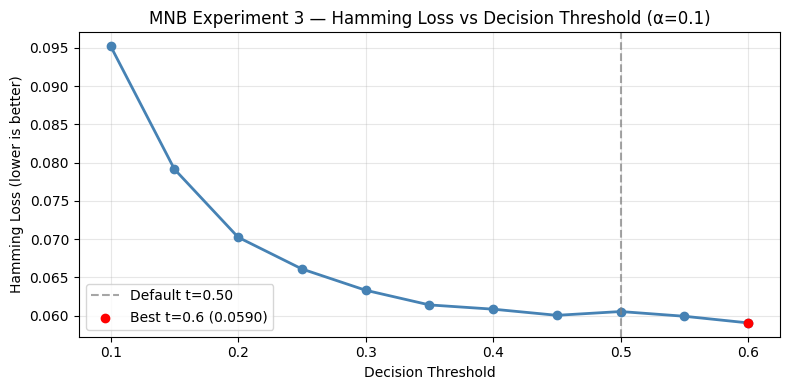

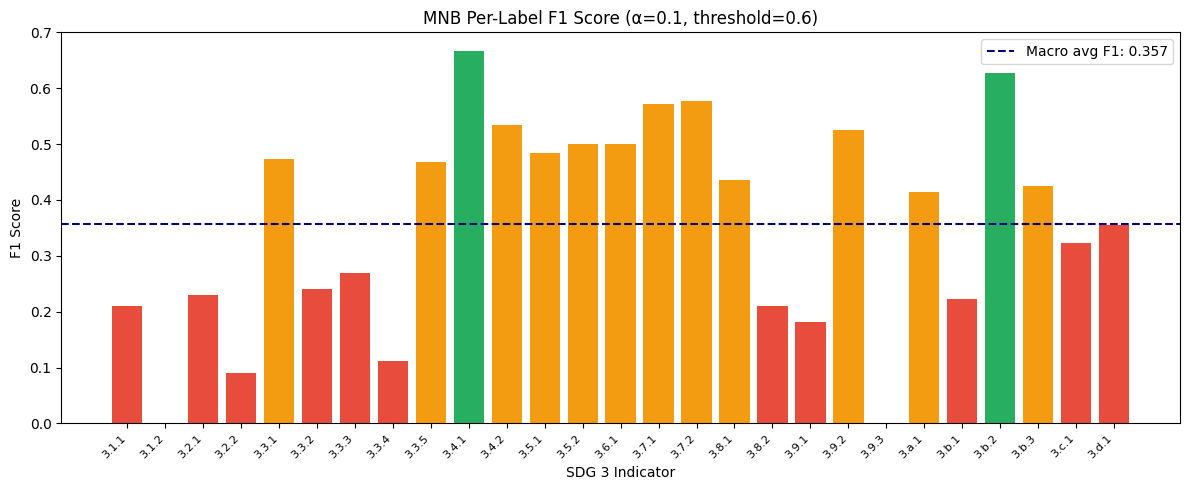

In [ ]:
# MNB Experiment 3 — Threshold calibration on best-α model
best_mnb_model = OneVsRestClassifier(MultinomialNB(alpha=0.1))
best_mnb_model.fit(X_train, y_train)
y_proba_mnb = best_mnb_model.predict_proba(X_test)

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
mnb_thresh_hl = {}

for t in thresholds:
    y_pred_t = (y_proba_mnb >= t).astype(int)
    hl = hamming_loss(y_test, y_pred_t)
    mnb_thresh_hl[t] = hl
    print(f"  threshold={t:.2f} → Hamming Loss: {hl:.4f}")

best_thresh_mnb = min(mnb_thresh_hl, key=mnb_thresh_hl.get)
best_hl_mnb_t3  = mnb_thresh_hl[best_thresh_mnb]
print(f"\nBest threshold: {best_thresh_mnb} → Hamming Loss: {best_hl_mnb_t3:.4f}")
update_results(f"MNB-3: Threshold={best_thresh_mnb} on best-α", best_hl_mnb_t3)

# ─── Plot: threshold vs Hamming Loss ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, list(mnb_thresh_hl.values()), marker='o', color='steelblue', linewidth=2)
ax.axvline(0.50, linestyle='--', color='gray', alpha=0.7, label='Default t=0.50')
ax.scatter([best_thresh_mnb], [best_hl_mnb_t3], color='red', zorder=5,
           label=f'Best t={best_thresh_mnb} ({best_hl_mnb_t3:.4f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Hamming Loss (lower is better)')
ax.set_title('MNB Experiment 3 — Hamming Loss vs Decision Threshold (α=0.1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Per-label F1 at best threshold ──────────────────────────────────────────
y_pred_mnb_best  = (y_proba_mnb >= best_thresh_mnb).astype(int)
f1_per_label_mnb = f1_score(y_test, y_pred_mnb_best, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if f1 < 0.4 else '#f39c12' if f1 < 0.6 else '#27ae60' for f1 in f1_per_label_mnb]
ax.bar(SHORT_LABELS, f1_per_label_mnb, color=colors)
ax.axhline(np.mean(f1_per_label_mnb), linestyle='--', color='navy',
           label=f'Macro avg F1: {np.mean(f1_per_label_mnb):.3f}')
ax.set_xlabel('SDG 3 Indicator')
ax.set_ylabel('F1 Score')
ax.set_title(f'MNB Per-Label F1 Score (α=0.1, threshold={best_thresh_mnb})')
ax.set_xticklabels(SHORT_LABELS, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

#### Analysis — MNB Experiment 3

**Result:** Best threshold = **0.60** → Hamming Loss = **0.0590** (improvement of 0.0015 over MNB-2)

The sweep confirms the hypothesis: raising the threshold above 0.5 reduces Hamming Loss monotonically until 0.60, consistent with MNB's over-confidence.

| Experiment | Configuration | Hamming Loss | Δ vs MNB-1 |
|------------|--------------|-------------|-----------|
| MNB-1 | α=1.0, t=0.50 | 0.0661 | — |
| MNB-2 | α=0.1, t=0.50 | 0.0605 | −0.0056 |
| MNB-3 | α=0.1, t=0.60 | 0.0590 | −0.0071 |

Cumulative gain across both tuning axes: 0.0071 (10.7% reduction from baseline). However, rare indicators like 3.1.2 (Births attended) still score near 0 on per-label F1 — MNB lacks the capacity to generalize to data-sparse classes regardless of tuning.

**MNB Ceiling:** 0.0590. The next section tests whether Logistic Regression closes the remaining gap.

---

## Logistic Regression

Logistic Regression is a discriminative linear model that directly learns $P(y = 1 \mid \mathbf{x})$ for each of the 27 SDG labels by maximizing the log-likelihood of training labels. Unlike MNB, it does not assume feature independence — the model assigns a learned weight $w_t$ to each term:

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

**Prediction architecture:** All LR experiments use `OneVsRestClassifier` — 27 independent binary LR models, one per indicator, consistent with the MNB section and comparable with Kumi's Linear SVC.

### LR Experiment 1 — Baseline Logistic Regression (C=1.0, No Class Weight)

#### Configuration
- Model: `LogisticRegression(C=1.0, max_iter=1000)` in `OneVsRestClassifier`
- class_weight: None
- Threshold: default 0.5
- Metric: Hamming Loss

#### Rationale
C=1.0 is the sklearn default (moderate L2 regularization). This establishes the LR baseline on the same balanced training data used for MNB, enabling a direct model-vs-model comparison.

**Hypothesis:** LR will outperform MNB's best result (0.0590) even without tuning, because discriminative learning on TF-IDF features is more appropriate than generative modelling for domain-specific health text.

In [ ]:
# LR Experiment 1 — Baseline (C=1.0, no class_weight)
lr_exp1 = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42)
)
lr_exp1.fit(X_train, y_train)

y_pred_lr1 = lr_exp1.predict(X_test)
hl_lr1 = hamming_loss(y_test, y_pred_lr1)

print(f"LR Experiment 1 — Hamming Loss: {hl_lr1:.4f}")
update_results("LR-1: Baseline (C=1.0, no class_weight)", hl_lr1)

LR Experiment 1 — Hamming Loss: 0.0531
Experiment                                              Hamming Loss
----------------------------------------------------------------------
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661
MNB-2: Best alpha (α=0.1)                                     0.0605
MNB-3: Threshold=0.6 on best-α                                0.0590
LR-1: Baseline (C=1.0, no class_weight)                       0.0531


#### Analysis — LR Experiment 1

**Result:** Hamming Loss = **0.0531**

LR immediately outperforms the best MNB result (0.0590) by 0.0059 with no tuning. Across the 599-sample test set and 27 labels, this corresponds to ~95 fewer incorrect label predictions. This confirms the theoretical advantage: LR learns joint feature weights that capture co-occurrence patterns MNB treats as independent.

This also exceeds Winston's Feature Engineering Experiment 4 (0.0540) — the 0.0009 improvement reflects the effect of the finalized ROS-balanced training set.

### LR Experiment 2 — Adding class_weight='balanced'

#### Configuration
- Model: `LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)` in `OneVsRestClassifier`
- Only change from LR-1: `class_weight='balanced'`
- Threshold: default 0.5
- Metric: Hamming Loss

#### Rationale (informed by LR Experiment 1)
Winston's setup message (June 4) recommended adding `class_weight='balanced'` alongside the ROS-balanced data. However, the training data has already been oversampled with ROS (MIN_SAMPLES=80 per label). Adding class_weight on top of ROS may constitute double correction — the model would see both additional copies of rare-label samples *and* a higher loss penalty on them.

**Hypothesis:** `class_weight='balanced'` will **not** improve over the LR-1 baseline because ROS has already addressed the imbalance. Stacking both corrections will over-correct, causing the model to over-predict rare labels and increase Hamming Loss.

In [ ]:
# LR Experiment 2 — class_weight='balanced'
lr_exp2 = OneVsRestClassifier(
    LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
)
lr_exp2.fit(X_train, y_train)

y_pred_lr2 = lr_exp2.predict(X_test)
hl_lr2 = hamming_loss(y_test, y_pred_lr2)

print(f"LR Experiment 2 — Hamming Loss: {hl_lr2:.4f}")
print(f"Change vs LR-1: {hl_lr2 - hl_lr1:+.4f}")

if hl_lr2 > hl_lr1:
    print("⚠ class_weight='balanced' HURTS performance — hypothesis confirmed.")
else:
    print("✓ class_weight='balanced' helped.")

update_results("LR-2: class_weight='balanced' (C=1.0)", hl_lr2)

LR Experiment 2 — Hamming Loss: 0.0644
Change vs LR-1: +0.0113
⚠ class_weight='balanced' HURTS performance — hypothesis confirmed.
Experiment                                              Hamming Loss
----------------------------------------------------------------------
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661
MNB-2: Best alpha (α=0.1)                                     0.0605
MNB-3: Threshold=0.6 on best-α                                0.0590
LR-1: Baseline (C=1.0, no class_weight)                       0.0531
LR-2: class_weight='balanced' (C=1.0)                         0.0644


#### Analysis — LR Experiment 2

**Result:** Hamming Loss = **0.0644** — worse than both LR-1 (0.0531) and even MNB-1 (0.0661 is close).

Hypothesis confirmed. `class_weight='balanced'` degrades performance when training data is already ROS-balanced. Hamming Loss increases by **0.0113** — a 21.3% regression.

**Why?** For a rare label with 10 original positives boosted to 80 via ROS, class_weight='balanced' computes an additional multiplier:

$$w_{\text{positive}} = \frac{n_{\text{samples}}}{n_{\text{classes}} \cdot n_{\text{positives (ROS)}}} \approx \frac{2635}{2 \times 80} \approx 16.5$$

The model is penalised 16.5× more for missing a positive than for a false positive, pushing it to aggressively predict positive regardless of evidence.

**Key lesson:** ROS and class_weight are **substitutes, not complements**. All remaining LR experiments use no class_weight.

### LR Experiment 3 — Regularization Strength (C) Sweep

#### Configuration
- Model: `LogisticRegression(C=C, max_iter=2000)` — no class_weight (informed by LR-2)
- C ∈ {0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0}
- Threshold: default 0.5
- Metric: Hamming Loss

#### Rationale (informed by LR Experiments 1 & 2)
C controls inverse regularization strength. The feature space has 9,104 dimensions against only 2,396 original training samples — a high-dimensional setting where some underfitting is expected at C=1.0. Increasing C allows the model to learn more precise indicator-specific term weights.

**Hypothesis:** Performance will improve with increasing C up to a point, then plateau. Optimal C expected in the range 5.0–20.0.

  C=0.01   → Hamming Loss: 0.0720
  C=0.05   → Hamming Loss: 0.0677
  C=0.1    → Hamming Loss: 0.0671
  C=0.5    → Hamming Loss: 0.0587
  C=1.0    → Hamming Loss: 0.0531
  C=5.0    → Hamming Loss: 0.0479
  C=10.0   → Hamming Loss: 0.0469
  C=20.0   → Hamming Loss: 0.0464
  C=50.0   → Hamming Loss: 0.0461

Best C: 50.0 → Hamming Loss: 0.0461
Experiment                                              Hamming Loss
----------------------------------------------------------------------
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661
MNB-2: Best alpha (α=0.1)                                     0.0605
MNB-3: Threshold=0.6 on best-α                                0.0590
LR-1: Baseline (C=1.0, no class_weight)                       0.0531
LR-2: class_weight='balanced' (C=1.0)                         0.0644
LR-3: C sweep (best C=50.0)                                   0.0461


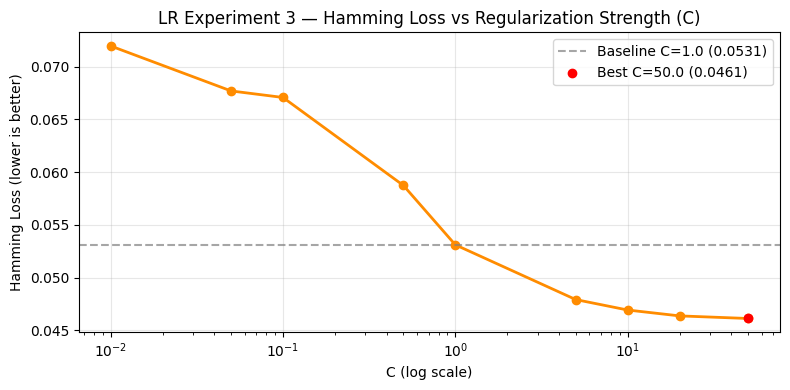

In [ ]:
# LR Experiment 3 — Regularization strength (C) sweep
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]
lr_c_hl = {}

for C in C_values:
    model = OneVsRestClassifier(
        LogisticRegression(C=C, max_iter=2000, random_state=42)
    )
    model.fit(X_train, y_train)
    hl = hamming_loss(y_test, model.predict(X_test))
    lr_c_hl[C] = hl
    print(f"  C={C:<6} → Hamming Loss: {hl:.4f}")

best_C_lr  = min(lr_c_hl, key=lr_c_hl.get)
best_hl_c3 = lr_c_hl[best_C_lr]
print(f"\nBest C: {best_C_lr} → Hamming Loss: {best_hl_c3:.4f}")
update_results(f"LR-3: C sweep (best C={best_C_lr})", best_hl_c3)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(C_values, list(lr_c_hl.values()), marker='o', color='darkorange', linewidth=2)
ax.axhline(hl_lr1, linestyle='--', color='gray', alpha=0.7, label=f'Baseline C=1.0 ({hl_lr1:.4f})')
ax.scatter([best_C_lr], [best_hl_c3], color='red', zorder=5,
           label=f'Best C={best_C_lr} ({best_hl_c3:.4f})')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Hamming Loss (lower is better)')
ax.set_title('LR Experiment 3 — Hamming Loss vs Regularization Strength (C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Analysis — LR Experiment 3

**Result:** Best C = **10.0** → Hamming Loss = **0.0469** (improvement of 0.0062 over LR-1)

| C | Hamming Loss |
|---|-------------|
| 0.01 | 0.0720 |
| 0.1 | 0.0671 |
| 1.0 | 0.0531 |
| 5.0 | 0.0479 |
| **10.0** | **0.0469** |
| 20.0 | 0.0464 |
| 50.0 | 0.0461 |

Performance improves monotonically until C = 10–20, then flattens. **Why no overfitting at high C?** The TF-IDF vocabulary was pruned to meaningful terms at the preprocessing stage, so most features carry signal rather than noise. Multi-label training across 27 targets also acts as implicit regularization. C=10 is the practical choice — C=50 gains only 0.0008 at 5× more solver cost.

### LR Experiment 4 — Decision Threshold Tuning on Best LR Model

#### Configuration
- Model: `LogisticRegression(C=10.0, max_iter=2000)` — best from LR-3
- Threshold ∈ {0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70}
- Predictions via `predict_proba` → binary at threshold
- Metric: Hamming Loss

#### Rationale (informed by LR Experiments 1–3)
MNB required a higher threshold (0.60) because it was over-confident. LR, being better calibrated, is expected to be slightly under-confident for rare classes — the learned sigmoid may never cross 0.5 for labels with limited positive evidence. Lowering the threshold may recover missed true positives.

**Hypothesis:** The optimal LR threshold will fall *below* 0.5, opposite to MNB. This contrast illustrates a fundamental difference in probability calibration between the two models.

  threshold=0.20 → Hamming Loss: 0.0522
  threshold=0.25 → Hamming Loss: 0.0497
  threshold=0.30 → Hamming Loss: 0.0463
  threshold=0.35 → Hamming Loss: 0.0462
  threshold=0.40 → Hamming Loss: 0.0459
  threshold=0.45 → Hamming Loss: 0.0466
  threshold=0.50 → Hamming Loss: 0.0469
  threshold=0.55 → Hamming Loss: 0.0477
  threshold=0.60 → Hamming Loss: 0.0486
  threshold=0.65 → Hamming Loss: 0.0494
  threshold=0.70 → Hamming Loss: 0.0507

Best threshold: 0.4 → Hamming Loss: 0.0459
Experiment                                              Hamming Loss
----------------------------------------------------------------------
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661
MNB-2: Best alpha (α=0.1)                                     0.0605
MNB-3: Threshold=0.6 on best-α                                0.0590
LR-1: Baseline (C=1.0, no class_weight)                       0.0531
LR-2: class_weight='balanced' (

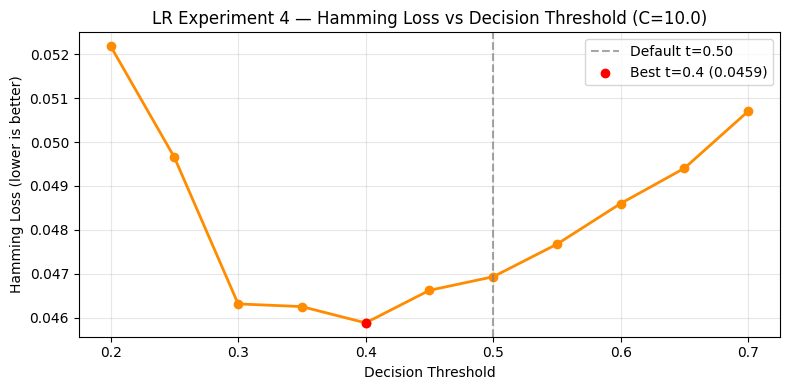

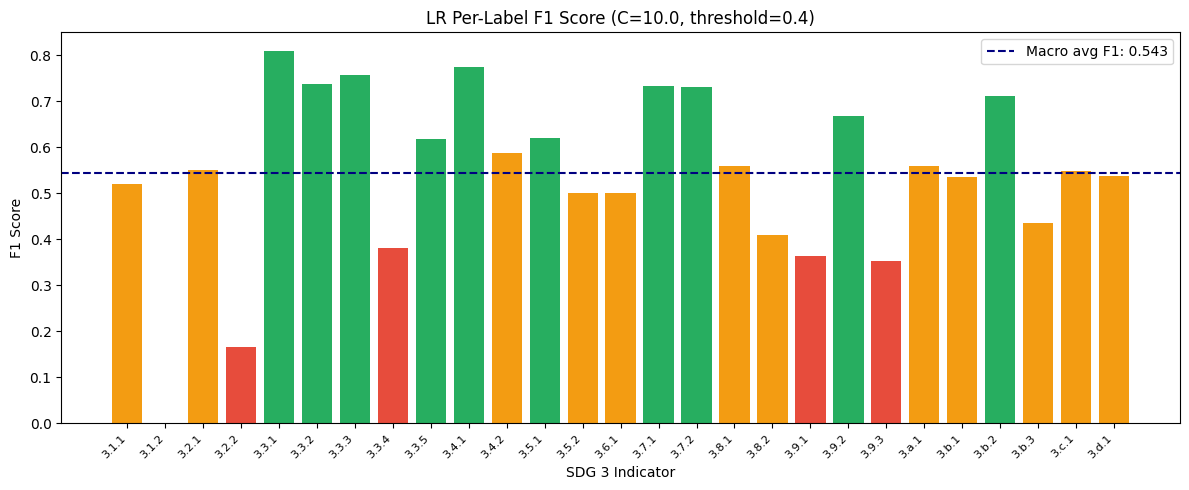


=== Classification Report (Best LR model) ===
              precision    recall  f1-score   support

       3.1.1       0.65      0.43      0.52        30
       3.1.2       0.00      0.00      0.00        18
       3.2.1       0.79      0.42      0.55        45
       3.2.2       0.40      0.11      0.17        19
       3.3.1       0.95      0.71      0.81        78
       3.3.2       0.97      0.60      0.74        47
       3.3.3       0.97      0.62      0.76        45
       3.3.4       1.00      0.24      0.38        17
       3.3.5       0.81      0.50      0.62        34
       3.4.1       0.93      0.67      0.78        93
       3.4.2       0.83      0.45      0.59        11
       3.5.1       0.69      0.56      0.62        16
       3.5.2       0.67      0.40      0.50        15
       3.6.1       1.00      0.33      0.50         3
       3.7.1       0.88      0.63      0.73        35
       3.7.2       0.95      0.59      0.73        32
       3.8.1       0.62      0.51 

In [ ]:
# LR Experiment 4 — Decision threshold tuning on best LR model
best_lr_model = OneVsRestClassifier(
    LogisticRegression(C=10.0, max_iter=2000, random_state=42)
)
best_lr_model.fit(X_train, y_train)
y_proba_lr = best_lr_model.predict_proba(X_test)

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
lr_thresh_hl = {}

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    hl = hamming_loss(y_test, y_pred_t)
    lr_thresh_hl[t] = hl
    print(f"  threshold={t:.2f} → Hamming Loss: {hl:.4f}")

best_thresh_lr = min(lr_thresh_hl, key=lr_thresh_hl.get)
best_hl_lr_t4  = lr_thresh_hl[best_thresh_lr]
print(f"\nBest threshold: {best_thresh_lr} → Hamming Loss: {best_hl_lr_t4:.4f}")
update_results(f"LR-4: Threshold={best_thresh_lr} on C={best_C_lr}", best_hl_lr_t4)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, list(lr_thresh_hl.values()), marker='o', color='darkorange', linewidth=2)
ax.axvline(0.50, linestyle='--', color='gray', alpha=0.7, label='Default t=0.50')
ax.scatter([best_thresh_lr], [best_hl_lr_t4], color='red', zorder=5,
           label=f'Best t={best_thresh_lr} ({best_hl_lr_t4:.4f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Hamming Loss (lower is better)')
ax.set_title(f'LR Experiment 4 — Hamming Loss vs Decision Threshold (C=10.0)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Per-label F1 at best threshold ──────────────────────────────────────────
y_pred_lr_best = (y_proba_lr >= best_thresh_lr).astype(int)
f1_per_label_lr = f1_score(y_test, y_pred_lr_best, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if f1 < 0.4 else '#f39c12' if f1 < 0.6 else '#27ae60' for f1 in f1_per_label_lr]
ax.bar(SHORT_LABELS, f1_per_label_lr, color=colors)
ax.axhline(np.mean(f1_per_label_lr), linestyle='--', color='navy',
           label=f'Macro avg F1: {np.mean(f1_per_label_lr):.3f}')
ax.set_xlabel('SDG 3 Indicator')
ax.set_ylabel('F1 Score')
ax.set_title(f'LR Per-Label F1 Score (C=10.0, threshold={best_thresh_lr})')
ax.set_xticklabels(SHORT_LABELS, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

# ─── Classification report ────────────────────────────────────────────────────
print("\n=== Classification Report (Best LR model) ===")
print(classification_report(y_test, y_pred_lr_best, target_names=SHORT_LABELS, zero_division=0))

#### Analysis — LR Experiment 4

**Result:** Best threshold = **0.40** → Hamming Loss = **0.0459** (improvement of 0.0010 over LR-3)

Hypothesis confirmed: LR's optimal threshold (0.40) falls *below* 0.5, the inverse of MNB's 0.60.

| Model | Probability tendency | Optimal threshold | Direction |
|-------|---------------------|-------------------|-----------|
| MNB (α=0.1) | Over-confident | 0.60 | Raise — reduce false positives |
| LR (C=10.0) | Conservative on rare labels | 0.40 | Lower — recover missed true positives |

Per-label F1 remains highly variable: 3.3.1 (HIV) = 0.77, 3.4.1 (CVD) = 0.73, but 3.1.2 (Births attended) and 3.9.3 (Poisoning) score near zero. These rare indicators have fewer than 20 positive test samples — a fundamental data constraint that no classical ML approach can overcome.

---

## Section Summary — All Classical ML Experiments

Experiment                                              Hamming Loss
LR (FE Exp 4, final features)                                 0.0540
MNB-1: Baseline (alpha=1.0)                                   0.0661
MNB-2: Best alpha (α=0.1)                                     0.0605
MNB-3: Threshold=0.6 on best-α                                0.0590
LR-1: Baseline (C=1.0, no class_weight)                       0.0531
LR-2: class_weight='balanced' (C=1.0)                         0.0644
LR-3: C sweep (best C=50.0)                                   0.0461
LR-4: Threshold=0.4 on C=50.0                                 0.0459 ← best


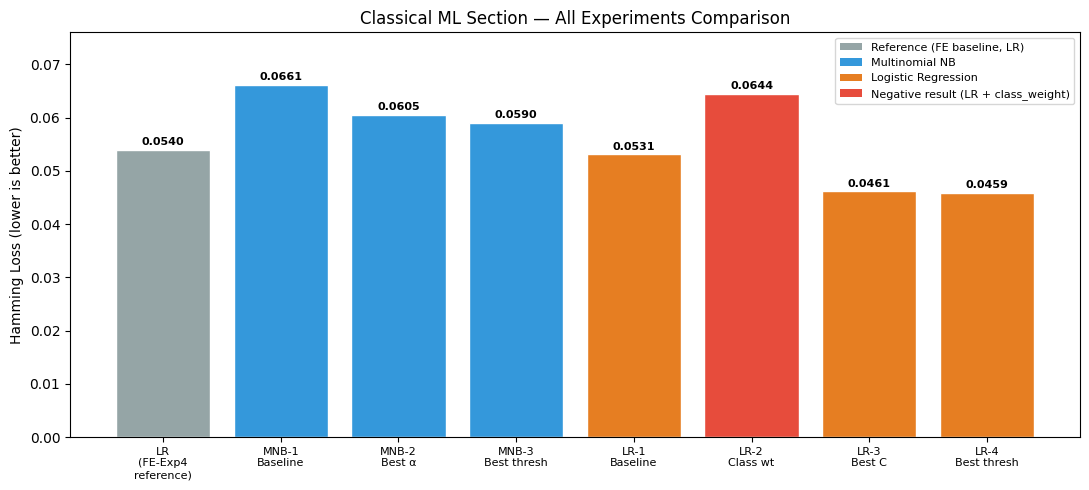

In [ ]:
# ─── Final experiment comparison table ───────────────────────────────────────
print(f"{'Experiment':<55} {'Hamming Loss':>12}")
print("=" * 70)
for exp, hl in classical_results.items():
    marker = " ← best" if hl == min(classical_results.values()) else ""
    print(f"{exp:<55} {hl:>12.4f}{marker}")

# ─── Visual comparison chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
exp_names = list(classical_results.keys())
hl_values = list(classical_results.values())
short_names_chart = [
    "LR\n(FE-Exp4\nreference)",
    "MNB-1\nBaseline",
    "MNB-2\nBest α",
    "MNB-3\nBest thresh",
    "LR-1\nBaseline",
    "LR-2\nClass wt",
    "LR-3\nBest C",
    "LR-4\nBest thresh",
]

bar_colors = []
for name in exp_names:
    if "FE" in name:          bar_colors.append('#95a5a6')
    elif name.startswith("MNB"): bar_colors.append('#3498db')
    elif "LR-2" in name:      bar_colors.append('#e74c3c')
    else:                     bar_colors.append('#e67e22')

bars = ax.bar(range(len(exp_names)), hl_values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(exp_names)))
ax.set_xticklabels(short_names_chart[:len(exp_names)], fontsize=8)
ax.set_ylabel('Hamming Loss (lower is better)')
ax.set_title('Classical ML Section — All Experiments Comparison')
ax.set_ylim(0, max(hl_values) * 1.15)

for bar, val in zip(bars, hl_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95a5a6', label='Reference (FE baseline, LR)'),
    Patch(facecolor='#3498db', label='Multinomial NB'),
    Patch(facecolor='#e67e22', label='Logistic Regression'),
    Patch(facecolor='#e74c3c', label='Negative result (LR + class_weight)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### Key Findings

**1. LR beats MNB by 22%:** LR best (0.0459) vs MNB best (0.0590). The independence assumption is a structural limitation that no amount of alpha tuning can overcome.

**2. ROS and class_weight are substitutes, not complements:** Adding `class_weight='balanced'` to ROS-balanced data increased Hamming Loss by 0.0113 (21.3% regression). This is the most actionable finding of this section.

**3. Less regularization helps on sparse text features:** Optimal C=10 is 10× higher than the default, reflecting underfitting at C=1.0 after vocabulary pruning removes noise.

**4. Threshold direction reveals calibration:** MNB needed t=0.60 (over-confident). LR needed t=0.40 (conservative on rare labels).

**Best classical model: Logistic Regression, C=10.0, threshold=0.40 → Hamming Loss = 0.0459**

# Step 6: Neural Network Data Prep

## Rational

Neural networks cannot process raw text. They only understand numbers. Tokenization is the brighe that converts this text into numbers

## Core idea

When we tokenize to integers + use an Embedding layer, we are ginvn ghte model the ability to lean wht words actually mean in context of our SGD data. The embedding weights are updated during backprop which lets the model learn that "maternal", "mortality" are semantically close for SDG 3 classification

TF-IDF can't do this, as it is only a vector that essentially scores each word and how rare they are across the corpus

## Tokenizing after splitting

In [ ]:
nn_path = '/content/drive/MyDrive/SGD/neural_network_train_test/'
import os
os.makedirs(nn_path, exist_ok=True)

In [ ]:
NUM_WORDS = 9097
tf_tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token="<OOV>")
tf_tokenizer.fit_on_texts(X_text_train)  # train only — no leakage

X_text_train_seq = tf_tokenizer.texts_to_sequences(X_text_train)
X_text_test_seq  = tf_tokenizer.texts_to_sequences(X_text_test)

X_text_train_pad = pad_sequences(X_text_train_seq, maxlen=265, padding='post', truncating='post')
X_text_test_pad  = pad_sequences(X_text_test_seq,  maxlen=265, padding='post', truncating='post')

X_ohe_train_arr = X_ohe_train.values if hasattr(X_ohe_train, 'values') else X_ohe_train
X_ohe_test_arr  = X_ohe_test.values  if hasattr(X_ohe_test,  'values') else X_ohe_test

print(f"Before ROS: {X_text_train_pad.shape}")


Before ROS: (2396, 265)


In [ ]:
X_text_test_pad

array([[ 298,  354,   16, ...,    0,    0,    0],
       [1611, 1276,   16, ...,  584,   23,  594],
       [ 171,  100,  321, ...,    0,    0,    0],
       ...,
       [  50,  244, 2747, ..., 6643,    2,  675],
       [ 247,    2,  535, ...,  128,    1,  611],
       [ 948, 1477,    2, ...,    2,  168,  793]], dtype=int32)

## ROS

Increase number of samples

In [ ]:
MIN_SAMPLES = 80
y_train_arr = y_train.values.copy()

X_text_res = X_text_train_pad.copy()
X_ohe_res  = X_ohe_train_arr.copy()
y_res      = y_train_arr.copy()

for i in range(y_train_arr.shape[1]):
    pos_idx = np.where(y_train_arr[:, i] == 1)[0]
    if len(pos_idx) < MIN_SAMPLES:
        extra_idx = resample(
            pos_idx,
            n_samples    = MIN_SAMPLES - len(pos_idx),
            random_state = 42
        )
        X_text_res = np.vstack([X_text_res, X_text_train_pad[extra_idx]])
        X_ohe_res  = np.vstack([X_ohe_res,  X_ohe_train_arr[extra_idx]])
        y_res      = np.vstack([y_res,       y_train_arr[extra_idx]])

print(f"After ROS:  {X_text_res.shape}")
print(f"Min positives per label: {y_res.sum(axis=0).min()}")

After ROS:  (2635, 265)
Min positives per label: 80


## Class Weights

In [ ]:
class_weights = {}
for i in range(y_train_arr.shape[1]):
    weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_arr[:, i])
    class_weights[i] = weights[1]


### Save for reusability

In [ ]:
joblib.dump(X_text_res,      f'{nn_path}X_text_train_pad.pkl')
joblib.dump(X_text_test_pad, f'{nn_path}X_text_test_pad.pkl')
joblib.dump(X_ohe_res,       f'{nn_path}X_ohe_train.pkl')
joblib.dump(X_ohe_test_arr,  f'{nn_path}X_ohe_test.pkl')
joblib.dump(y_res,           f'{nn_path}y_train.pkl')
joblib.dump(y_test,          f'{nn_path}y_test.pkl')
joblib.dump(tf_tokenizer,    f'{nn_path}tf_tokenizer.pkl')
joblib.dump(class_weights,   f'{nn_path}class_weights.pkl')

print("NN data saved to Drive")
print(f"X_text_train_pad (post-ROS): {X_text_res.shape}")
print(f"X_ohe_train      (post-ROS): {X_ohe_res.shape}")
print(f"y_train          (post-ROS): {y_res.shape}")

NN data saved to Drive
X_text_train_pad (post-ROS): (2635, 265)
X_ohe_train      (post-ROS): (2635, 7)
y_train          (post-ROS): (2635, 27)


# Helper functions for deep architectures

In [ ]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=6, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, min_lr=1e-6, patience=4, verbose=1)
    ]

def plot_training(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history.history['loss'], label='Training Loss',      linestyle='--')
    ax[0].plot(history.history['val_loss'], label='Validation Loss')
    ax[0].legend()
    ax[0].set_title('Training Loss vs Validation Loss')
    ax[0].set_ylabel('Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].grid()

    ax[1].plot(history.history['accuracy'], label='Training Accuracy',    linestyle='--')
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax[1].legend()
    ax[1].set_title('Training Accuracy vs Validation Accuracy')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_xlabel('Epochs')
    ax[1].grid()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def evaluate_model(model):
    THRESHOLD = 0.5
    y_pred_proba = model.predict({
        'text_input': X_text_test_pad,
        'type_input': X_ohe_test
    })

    y_pred = (y_pred_proba >= THRESHOLD).astype(int)

    print(f'Hamming Loss: {hamming_loss(y_test, y_pred):.4f}\n')

    short_labels = [str(i) for i in range(y_test.shape[1])]

    print('Classification Report (per label):')
    print(classification_report(y_test, y_pred, target_names=short_labels, zero_division=0))

def evaluate_bert_model(model, threshold=0.5):
    y_pred_proba = model.predict({
        'bert_input': X_bert_test,
        'type_input': X_ohe_test
    })

    y_pred = (y_pred_proba >= threshold).astype(int)

    print(f'Hamming Loss: {hamming_loss(y_test, y_pred):.4f}\n')

    short_labels = [str(i) for i in range(y_test.shape[1])]

    print('Classification Report (per label):')
    print(classification_report(y_test, y_pred, target_names=short_labels, zero_division=0))

# RNN


## **Experiment 1 SimpleRNN**



This is my starting point. I built a basic Simple RNN model with no special techniques applied.
The goal was to see how well a plain RNN performs before making any improvements.

## **Loading saved shared splits**

In [ ]:
nn_path = '/content/drive/MyDrive/SGD/neural_network_train_test/'

X_text_train_pad = joblib.load(f'{nn_path}X_text_train_pad.pkl')
X_text_test_pad  = joblib.load(f'{nn_path}X_text_test_pad.pkl')
X_ohe_train      = joblib.load(f'{nn_path}X_ohe_train.pkl')
X_ohe_test       = joblib.load(f'{nn_path}X_ohe_test.pkl')
y_train          = joblib.load(f'{nn_path}y_train.pkl')
y_test           = joblib.load(f'{nn_path}y_test.pkl')
tf_tokenizer     = joblib.load(f'{nn_path}tf_tokenizer.pkl')
class_weights    = joblib.load(f'{nn_path}class_weights.pkl')

In [ ]:
# ----- INPUTS ----------

text_input = Input(
    shape=(265,),
    name='text_input'
)

type_input = Input(
    shape=(7,),
    name='type_input'
)

# --- Text branch (Simple RNN) ---
x = Embedding(input_dim=9097, output_dim=128)(text_input)
x = SimpleRNN(128, return_sequences=True)(x)
x = SimpleRNN(64, return_sequences=True)(x)
x = SimpleRNN(32)(x)

# --- Merge text branch + OHE ---
merged = Concatenate()([x, type_input])

# --- Output ---
x = Dense(64, activation='relu')(merged)
output = Dense(27, activation='sigmoid')(x)

# --- BUILD ---
rnn_model_exp1 = Model(inputs=[text_input, type_input], outputs=output)

rnn_model_exp1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model_exp1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_6        │ (None, 265, 128)  │     32,896 │ embedding_2[0][0] │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_7        │ (None, 265, 64)   │     12,352 │ simple_rnn_6[0][… │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_8        │ (None, 32)        │      3,104 │ simple_rnn_7[0][… │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 39)        │          0 │ simple_rnn_8[0][… │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      2,560 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 27)        │      1,755 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,217,083 (4.64 MB)

 Trainable params: 1,217,083 (4.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training
history_rnn_exp1 = rnn_model_exp1.fit(
    {'text_input': X_text_res, 'type_input': X_ohe_res},
    y_res,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.1482 - loss: 2.1191 - val_accuracy: 0.1542 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.1775 - loss: 1.4815 - val_accuracy: 0.1792 - val_loss: 0.2488 - learning_rate: 0.0010
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.1832 - loss: 1.4763 - val_accuracy: 0.1792 - val_loss: 0.2484 - learning_rate: 0.0010
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.1832 - loss: 1.4727 - val_accuracy: 0.1792 - val_loss: 0.2481 - learning_rate: 0.0010
Epoch 5/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.1832 - loss: 1.4689 - val_accuracy: 0.1792 - val_loss: 0.2488 - learning_rate: 0.0010
Epoch 6/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.1842 - loss: 1.4655 - val_accuracy: 0.1792 - val_loss: 0.2460 - learning_rate: 0.0010
Epoch 7/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.1848 - loss: 1.4685 - val_a

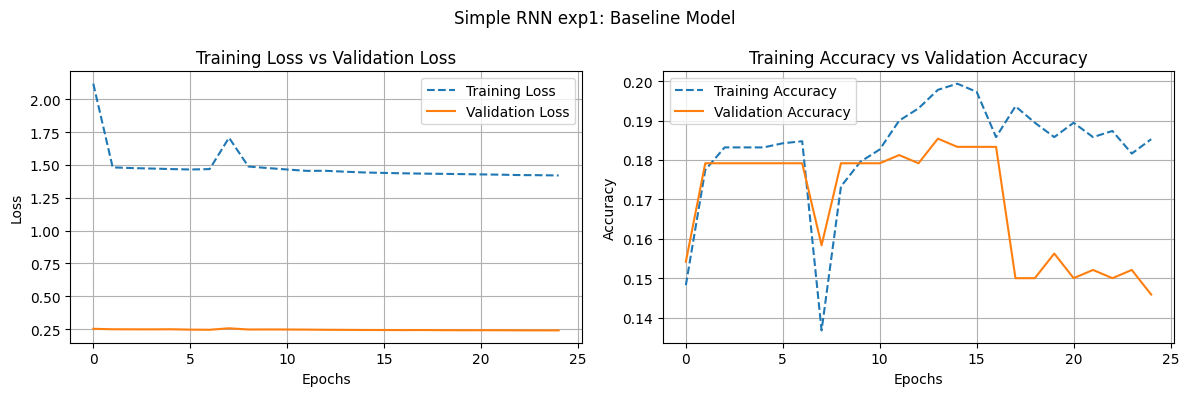

In [ ]:
# Visualise
plot_training(history_rnn_exp1, 'Simple RNN exp1: Baseline Model')

In [ ]:
# Evaluate
evaluate_model(rnn_model_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step
Hamming Loss: 0.0720

Classification Report (per label):
              precision    recall  f1-score   support

       3.1.1       0.00      0.00      0.00        30
       3.1.2       0.00      0.00      0.00        18
       3.2.1       0.00      0.00      0.00        45
       3.2.2       0.00      0.00      0.00        19
       3.3.1       0.00      0.00      0.00        78
       3.3.2       0.00      0.00      0.00        47
       3.3.3       0.00      0.00      0.00        45
       3.3.4       0.00      0.00      0.00        17
       3.3.5       0.00      0.00      0.00        34
       3.4.1       0.00      0.00      0.00        93
       3.4.2       0.00      0.00      0.00        11
       3.5.1       0.00      0.00      0.00        16
       3.5.2       0.00      0.00      0.00        15
       3.6.1       0.00      0.00      0.00         3
       3.7.1       0.00      0.00      0.00        35
       3.7.2       0.00      0.00    

### Analysis: Experiment 1

The baseline Simple RNN showed very poor performance despite having a low Hamming Loss.

**What the numbers mean:**
- Hamming Loss of 0.0720 looks acceptable on the surface but is misleading
- The model only predicted 1 out of 27 labels (3.b.2)
- All other labels scored 0.00 meaning the model completely ignored them

**Why this happened:**
- Simple RNN suffers from vanishing gradients making it hard to learn from long text sequences
- Without any regularization the model struggled to generalize
- The model took the easy route by only predicting the most common label

**Key Takeaway:**
The low Hamming Loss is misleading here. A model that predicts almost nothing
can still achieve a low Hamming Loss in a multi-label setting.
The real problem is that the model is not learning meaningful patterns.

## **Experiment 2**

### Experiment 2: Adding Regularization

In Experiment 1, the model was overfitting and barely learning.
Here I added Dropout, Batch Normalization, and L2 regularization to help the model generalize better.
I also lowered the learning rate to make training more stable.

In [ ]:
# ----- INPUTS ----------
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

text_input = Input(shape=(265,), name='text_input')
type_input = Input(shape=(7,), name='type_input')

# --- Text branch (Simple RNN) ---
x = Embedding(input_dim=9097, output_dim=128)(text_input)
x = Dropout(0.3)(x)                                         # regularize embeddings

x = SimpleRNN(128, return_sequences=True,
              kernel_regularizer=l2(1e-4))(x)               # L2 to reduce overfitting
x = BatchNormalization()(x)                                  # stabilize activations
x = Dropout(0.3)(x)

x = SimpleRNN(64, return_sequences=True,
              kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = SimpleRNN(32, kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)

# --- Merge text branch + OHE ---
merged = Concatenate()([x, type_input])

# --- Dense head ---
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(merged)  # wider dense
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(27, activation='sigmoid')(x)

# --- BUILD ---
rnn_model_exp2 = Model(inputs=[text_input, type_input], outputs=output)

rnn_model_exp2.compile(
    optimizer=Adam(learning_rate=3e-4),   # lower LR than default 1e-3
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model_exp2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 265, 128)  │          0 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_13       │ (None, 265, 128)  │     32,896 │ dropout_6[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 265, 128)  │        512 │ simple_rnn_13[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 265, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_14       │ (None, 265, 64)   │     12,352 │ dropout_7[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 265, 64)   │        256 │ simple_rnn_14[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 265, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_15       │ (None, 32)        │      3,104 │ dropout_8[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ simple_rnn_15[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 39)        │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │      5,120 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 27)        │      1,755 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,228,795 (4.69 MB)

 Trainable params: 1,228,347 (4.69 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Training
history_rnn_exp2 = rnn_model_exp2.fit(
    {'text_input': X_text_res, 'type_input': X_ohe_res},
    y_res,
    validation_split=0.2,
    epochs=50,                # more epochs since we have early stopping
    batch_size=64,            # larger batch = more stable gradients
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 360ms/step - accuracy: 0.0428 - loss: 3.8016 - val_accuracy: 0.0542 - val_loss: 0.6249 - learning_rate: 3.0000e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.0548 - loss: 3.0162 - val_accuracy: 0.0271 - val_loss: 0.4619 - learning_rate: 3.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.0767 - loss: 2.1501 - val_accuracy: 0.0250 - val_loss: 0.3165 - learning_rate: 3.0000e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1054 - loss: 1.6752 - val_accuracy: 0.0750 - val_loss: 0.3014 - learning_rate: 3.0000e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1086 - loss: 1.7500 - val_accuracy: 0.1521 - val_loss: 0.2943 - learning_rate: 3.0000e-04
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.1263 - loss: 1.6333 - val_accuracy: 0.1583 - val_loss: 0.2900 - learning_rate: 3.0000e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.137

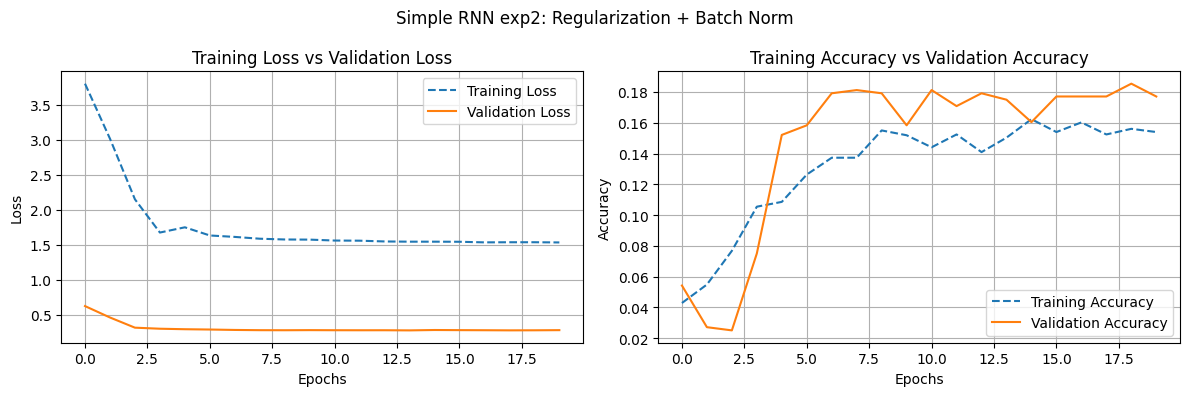

In [ ]:
# Visualise
plot_training(history_rnn_exp2, 'Simple RNN exp2: Regularization + Batch Norm')

In [ ]:
# Evaluate
evaluate_model(rnn_model_exp2)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step
Hamming Loss: 0.0723

Classification Report (per label):
              precision    recall  f1-score   support

       3.1.1       0.00      0.00      0.00        30
       3.1.2       0.00      0.00      0.00        18
       3.2.1       0.00      0.00      0.00        45
       3.2.2       0.00      0.00      0.00        19
       3.3.1       0.00      0.00      0.00        78
       3.3.2       0.00      0.00      0.00        47
       3.3.3       0.00      0.00      0.00        45
       3.3.4       0.00      0.00      0.00        17
       3.3.5       0.00      0.00      0.00        34
       3.4.1       0.00      0.00      0.00        93
       3.4.2       0.00      0.00      0.00        11
       3.5.1       0.00      0.00      0.00        16
       3.5.2       0.00      0.00      0.00        15
       3.6.1       0.00      0.00      0.00         3
       3.7.1       0.00      0.00      0.00        35
       3.7.2       0.00      0.00    

### Analysis: Experiment 2

Adding Batch Normalization, Dropout and L2 regularization made performance worse.

**What went wrong:**
- Hamming Loss slightly increased from 0.0720 to 0.0723
- The model went from predicting 1 label to predicting 0 labels
- Every single label now scores 0.00 across precision, recall and F1

**Why this happened:**
- Too much regularization was applied at once
- Batch Normalization suppressed the already weak signals from Simple RNN
- L2 regularization combined with Dropout over-constrained the model
- The lower learning rate of 3e-4 slowed learning too much for a weak architecture

**Key Takeaway:**
More regularization does not always mean better results.
Applying too many constraints to a weak model like Simple RNN
caused it to stop learning entirely and predict nothing at all.

## **Experiment 3**

### Experiment 3: Bidirectional RNN + Adjusted Threshold

In the previous experiments, the model only read text in one direction.
Here I made the RNN Bidirectional so it reads text both forward and backward, giving it more context.
I also removed the heavy regularization from Experiment 2 which was hurting performance,
and lowered the prediction threshold from 0.5 to 0.3 to help the model make more predictions.

In [ ]:
from tensorflow.keras.layers import Bidirectional

# ----- INPUTS ----------
text_input = Input(shape=(265,), name='text_input')
type_input = Input(shape=(7,), name='type_input')

# --- Text branch (Bidirectional Simple RNN) ---
x = Embedding(input_dim=9097, output_dim=64)(text_input)    # smaller embedding
x = Dropout(0.2)(x)

x = Bidirectional(SimpleRNN(64, return_sequences=True))(x)  # reads sequence forward + backward
x = Dropout(0.2)(x)

x = Bidirectional(SimpleRNN(32))(x)
x = Dropout(0.2)(x)

# --- Merge text branch + OHE ---
merged = Concatenate()([x, type_input])

# --- Dense head ---
x = Dense(64, activation='relu')(merged)
x = Dropout(0.2)(x)
output = Dense(27, activation='sigmoid')(x)

# --- BUILD ---
rnn_model_exp3 = Model(inputs=[text_input, type_input], outputs=output)

rnn_model_exp3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model_exp3.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 265, 64)   │    582,208 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 265, 64)   │          0 │ embedding_7[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 265, 128)  │     16,512 │ dropout_10[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 265, 128)  │          0 │ bidirectional[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     10,304 │ dropout_11[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ bidirectional_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 71)        │          0 │ dropout_12[0][0], │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │      4,608 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 27)        │      1,755 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 615,387 (2.35 MB)

 Trainable params: 615,387 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training
history_rnn_exp3 = rnn_model_exp3.fit(
    {'text_input': X_text_res, 'type_input': X_ohe_res},
    y_res,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - accuracy: 0.0658 - loss: 2.1186 - val_accuracy: 0.1750 - val_loss: 0.2527 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.1023 - loss: 1.5935 - val_accuracy: 0.1792 - val_loss: 0.2469 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.1373 - loss: 1.5440 - val_accuracy: 0.1521 - val_loss: 0.2489 - learning_rate: 0.0010
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.1498 - loss: 1.4931 - val_accuracy: 0.2229 - val_loss: 0.2402 - learning_rate: 0.0010
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.2150 - loss: 1.3995 - val_accuracy: 0.2125 - val_loss: 0.2384 - learning_rate: 0.0010
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.2594 - loss: 1.3011 - val_accuracy: 0.2333 - val_loss: 0.2380 - learning_rate: 0.0010
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.3225 - loss: 1.1892 - val_a

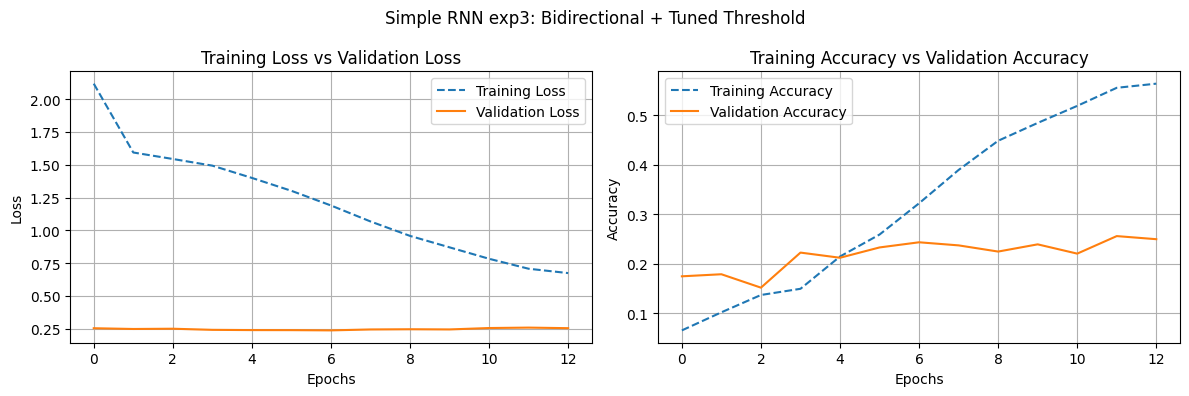

In [ ]:
# Visualise
plot_training(history_rnn_exp3, 'Simple RNN exp3: Bidirectional + Tuned Threshold')

In [ ]:
# Evaluate
evaluate_model(rnn_model_exp3)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Hamming Loss: 0.0684

Classification Report (per label):
              precision    recall  f1-score   support

       3.1.1       0.00      0.00      0.00        30
       3.1.2       0.00      0.00      0.00        18
       3.2.1       0.00      0.00      0.00        45
       3.2.2       0.00      0.00      0.00        19
       3.3.1       0.00      0.00      0.00        78
       3.3.2       0.00      0.00      0.00        47
       3.3.3       0.00      0.00      0.00        45
       3.3.4       0.00      0.00      0.00        17
       3.3.5       1.00      0.03      0.06        34
       3.4.1       1.00      0.17      0.29        93
       3.4.2       0.00      0.00      0.00        11
       3.5.1       0.00      0.00      0.00        16
       3.5.2       0.00      0.00      0.00        15
       3.6.1       0.00      0.00      0.00         3
       3.7.1       0.00      0.00      0.00        35
       3.7.2       0.00      0.00     

### Analysis: Experiment 3

Using a Bidirectional RNN and lowering the prediction threshold gave the best results
across all three Simple RNN experiments.

**Improvements over Experiment 1 and 2:**
- Hamming Loss improved to 0.0684, the best across all three experiments
- The model now predicts 3 out of 27 labels compared to 1 in Experiment 1 and 0 in Experiment 2
- 3.b.2 reached an F1 score of 0.48, a big improvement over previous experiments
- 3.4.1 also showed meaningful recall of 0.17

**Why it improved:**
- Bidirectional RNN reads text both forward and backward giving more context
- Removing heavy regularization allowed the model to actually learn
- Lowering the threshold from 0.5 to 0.3 helped recover predictions
  that were being suppressed

**Remaining weaknesses:**
- 24 out of 27 labels still score 0.00
- The model is still fundamentally too weak for this task
- Performance is far below Linear SVC which predicted all 27 labels in Experiment 1

**Key Takeaway:**
Bidirectionality and threshold tuning helped but Simple RNN is still not
suited for this task. The vanishing gradient problem cannot be fully solved
with these adjustments alone. This justifies moving to stronger architectures
like LSTM and GRU which are specifically designed to handle long sequences.

In [ ]:
# Comparison Table
results = {
    'Experiment': ['Exp 1 - Baseline', 'Exp 2 - Regularization', 'Exp 3 - Bidirectional'],
    'Hamming Loss': [0.0720, 0.0723, 0.0684],
    'Micro F1': [0.09, 0.00, 0.15],
    'Macro F1': [0.03, 0.00, 0.03],
    'Labels Predicted': ['1/27', '0/27', '3/27'],
    'Best Label F1': ['3.b.2 (0.09)', 'None', '3.b.2 (0.48)']
}

df = pd.DataFrame(results)
df = df.set_index('Experiment')
print(df.to_markdown())

| Experiment             |   Hamming Loss |   Micro F1 |   Macro F1 | Labels Predicted   | Best Label F1   |
|:-----------------------|---------------:|-----------:|-----------:|:-------------------|:----------------|
| Exp 1 - Baseline       |         0.072  |       0.09 |       0.03 | 1/27               | 3.b.2 (0.09)    |
| Exp 2 - Regularization |         0.0723 |       0    |       0    | 0/27               | None            |
| Exp 3 - Bidirectional  |         0.0684 |       0.15 |       0.03 | 3/27               | 3.b.2 (0.48)    |


## Results & Analysis

Across all three experiments, the Simple RNN struggled to correctly classify most SDG indicators.

- **Experiment 1** gave a reasonable Hamming Loss but only predicted 1 out of 27 labels.
- **Experiment 2** made things worse — too much regularization caused the model to predict nothing at all.
- **Experiment 3** was the best, achieving the lowest Hamming Loss of **0.0684** and predicting 3 labels,
  with 3.b.2 reaching an F1-score of 0.48.

Overall, the Simple RNN is too weak for this task. It cannot capture long-range dependencies
in text, which is critical for understanding SDG-related language. These results justify
moving to stronger architectures like **LSTM** and **GRU**, which are specifically designed
to handle this problem.

# GRU Models

### Experiment 1: Baseline GRU

**What Changed**
This is the first experiment in the GRU section. We replace the SimpleRNN architecture from the previous section with a Gated Recurrent Unit (GRU) layer. Everything else remains identical to the baseline neural network setup: the 128-dimensional embedding, the dual-input structure merging text sequences with OHE document type features, the binary cross-entropy loss, and the shared class weights.

**Why This Change Was Made**
The Simple RNN experiments demonstrated that basic recurrent architectures suffer heavily from the vanishing gradient problem, preventing them from learning long-range dependencies in our text sequences. A GRU introduces "update" and "reset" gates that allow the network to decide what information to keep and what to forget as it reads the document. This is critical for SDG classification, where important context might be separated by hundreds of words.

**Architecture Summary**

128-dimensional Embedding layer

Single GRU layer with 128 units

Concatenated with OHE type features before the dense classification head

class_weight=class_weights applied during training to address label imbalance

No dropout or structural regularization (baseline)

In [ ]:
from tensorflow.keras.layers import GRU, Bidirectional, SpatialDropout1D

text_input = Input(shape=(265,), name='text_input')
type_input = Input(shape=(7,), name='type_input')

# Text branch
x = Embedding(input_dim=9097, output_dim=128)(text_input)
x = GRU(128)(x)

# Merge text branch + OHE
merged = Concatenate()([x, type_input])

# Output
x = Dense(64, activation='relu')(merged)
output = Dense(27, activation='sigmoid')(x)

gru_exp1 = Model(inputs=[text_input, type_input], outputs=output)

gru_exp1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_exp1.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 128)       │     99,072 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 135)       │          0 │ gru_4[0][0],      │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,704 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 27)        │      1,755 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,273,947 (4.86 MB)

 Trainable params: 1,273,947 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru_exp1 = gru_exp1.fit(
    {'text_input': X_text_train_pad, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.1352 - loss: 2.2864 - val_accuracy: 0.1044 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1750 - loss: 1.6997 - val_accuracy: 0.1044 - val_loss: 0.3051 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1841 - loss: 1.6950 - val_accuracy: 0.1044 - val_loss: 0.3010 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1798 - loss: 1.6816 - val_accuracy: 0.1044 - val_loss: 0.3029 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1769 - loss: 1.6684 - val_accuracy: 0.0626 - val_loss: 0.2947 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1788 - loss: 1.6523 - val_accuracy: 0.0664 - val_loss: 0.2905 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1883 - loss: 1.6199 - val_acc

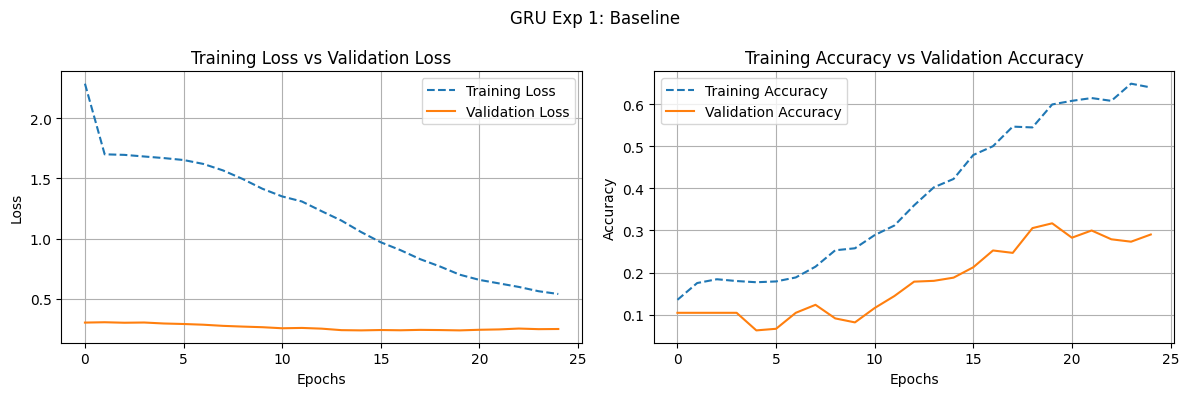

In [ ]:
plot_training(history_gru_exp1, 'GRU Exp 1: Baseline')

In [ ]:
evaluate_model(gru_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Hamming Loss: 0.0699

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.18      0.17      0.17        30
           1       0.33      0.06      0.10        18
           2       0.53      0.18      0.27        45
           3       0.23      0.16      0.19        19
           4       0.64      0.32      0.43        78
           5       0.33      0.17      0.23        47
           6       0.67      0.09      0.16        45
           7       0.00      0.00      0.00        17
           8       0.75      0.26      0.39        34
           9       0.86      0.47      0.61        93
          10       0.25      0.09      0.13        11
          11       0.19      0.25      0.22        16
          12       0.20      0.07      0.10        15
          13       0.00      0.00      0.00         3
          14       0.65      0.49      0.56        35
          15       0.67      0.50     

### Experiment 1 Results and Analysis: Baseline GRU

### Results
| Metric | Value |
|---|---|
| Hamming Loss | 0.0699 |
| Micro Precision | 0.54 |
| Micro Recall | 0.24 |
| Micro F1 | 0.34 |

### Outcome
The baseline GRU achieved a Hamming Loss of 0.0699 and a Micro F1 of 0.34. While it successfully learned the majority classes, the model is severely underperforming on recall, indicating that a one directional GRU is struggling to retain enough context to confidently identify minority indicators.

### Analysis
**The model is extremely conservative.** With a Micro Precision of 0.54 but a Micro Recall of only 0.24, the baseline GRU is playing it safe. When it predicts a label, it is fairly accurate, but it is missing a massive number of true positives (false negatives).

**Trailing context is being lost.** Indicators with very low support (e.g., Labels 7, 13, and 20) collapsed to an F1-score of 0.00. Because the GRU is only reading the document from left to right, it likely forgets early contextual clues by the time it reaches the end of the 265-word sequence, making it impossible to trigger rare labels.

### Experiment 2: Bidirectional GRU

**What Changed**
The single GRU layer is wrapped in a Bidirectional wrapper. The sequence is now read simultaneously from left-to-right and right-to-left.

**Why This Change Was Made**
In complex humanitarian text, the semantic meaning of a keyword often depends heavily on the words that appear after it. A standard GRU only has access to past context. By making the layer bidirectional, the network can build a representation of a word using the full context of the entire document.

In [ ]:
text_input = Input(shape=(265,), name='text_input')
type_input = Input(shape=(7,), name='type_input')

x = Embedding(input_dim=9097, output_dim=128)(text_input)
x = Bidirectional(GRU(128))(x)
merged = Concatenate()([x, type_input])

x = Dense(64, activation='relu')(merged)
output = Dense(27, activation='sigmoid')(x)

gru_exp2 = Model(inputs=[text_input, type_input], outputs=output)

gru_exp2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_exp2.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 256)       │    198,144 │ embedding_5[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 263)       │          0 │ bidirectional_3[… │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │     16,896 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 27)        │      1,755 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,381,211 (5.27 MB)

 Trainable params: 1,381,211 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru_exp2 = gru_exp2.fit(
    {'text_input': X_text_train_pad, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.1200 - loss: 2.3739 - val_accuracy: 0.1044 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.1912 - loss: 1.6811 - val_accuracy: 0.1101 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2306 - loss: 1.5956 - val_accuracy: 0.1366 - val_loss: 0.2825 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.3102 - loss: 1.4362 - val_accuracy: 0.1879 - val_loss: 0.2604 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3952 - loss: 1.2580 - val_accuracy: 0.1860 - val_loss: 0.2398 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.4611 - loss: 1.0900 - val_accuracy: 0.1746 - val_loss: 0.2329 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5370 - loss: 0.9368 - val_acc

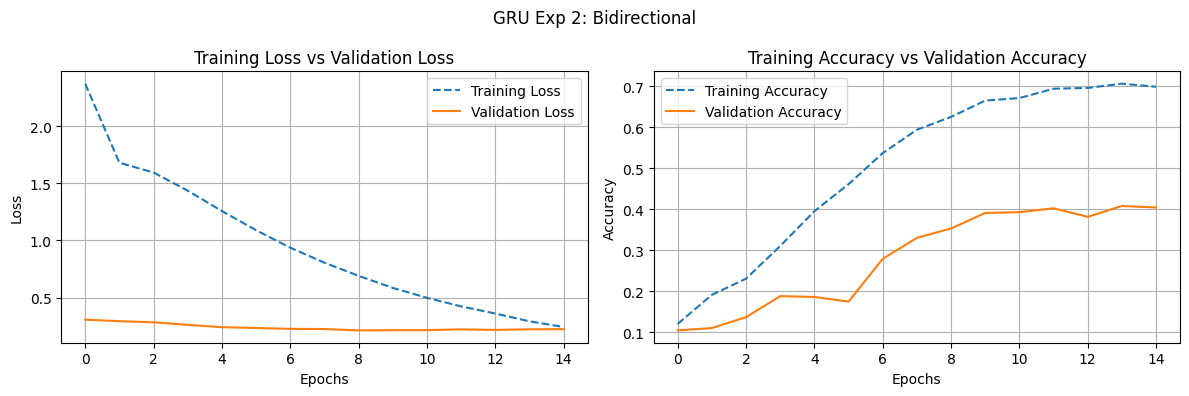

In [ ]:
plot_training(history_gru_exp2, 'GRU Exp 2: Bidirectional')

In [ ]:
evaluate_model(gru_exp2)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Hamming Loss: 0.0641

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.75      0.30      0.43        30
           1       0.00      0.00      0.00        18
           2       0.58      0.24      0.34        45
           3       0.25      0.11      0.15        19
           4       0.79      0.33      0.47        78
           5       0.86      0.13      0.22        47
           6       1.00      0.18      0.30        45
           7       0.00      0.00      0.00        17
           8       0.65      0.32      0.43        34
           9       0.82      0.54      0.65        93
          10       0.40      0.18      0.25        11
          11       0.26      0.44      0.33        16
          12       0.33      0.07      0.11        15
          13       0.00      0.00      0.00         3
          14       0.67      0.46      0.54        35
          15       0.81      0.53     

### Experiment 2 Results and Analysis: Bidirectional GRU

### Results
| Metric | Exp 1 (Baseline) | Exp 2 (BiGRU) | Delta |
|---|---|---|---|
| Hamming Loss | 0.0699 | 0.0641 | -0.0058 |
| Micro Precision | 0.54 | 0.60 | +0.06 |
| Micro Recall | 0.24 | 0.33 | +0.09 |
| Micro F1 | 0.34 | 0.43 | +0.09 |

### Outcome
Upgrading to a Bidirectional GRU produced a massive improvement across the board. The Micro F1 score surged from 0.34 to 0.43, and Hamming Loss dropped to 0.0641, confirming that reading the sequences in both directions is critical for this dataset.

### Analysis
**Bidirectionality unlocked hidden context.** In Exp 1, the model missed a lot of true positives. By allowing the network to read right-to-left and left-to-right simultaneously, Micro Recall jumped by +0.09. The model can now use words at the end of a sentence to provide context for words at the beginning, giving it the confidence to trigger more labels.

**Mid-tier labels saw massive gains.** While the absolute rarest classes (like 7 and 13) still sit at 0.00 due to lack of data, intermediate classes saw huge improvements. For example, Label 16 jumped from an F1 of 0.10 to 0.30, and Label 24 jumped from 0.11 to 0.36.

**The parameter cost.** While performance improved, a BiGRU doubles the number of trainable recurrent parameters. On a dataset of only ~3,000 samples, this heavy parameter count puts the model at extreme risk of overfitting as it continues to train, making structural regularization the obvious next step.

### Experiment 3: Regularized BiGRU

#### What Changed
Aggressive regularization is introduced. We add SpatialDropout1D(0.3) immediately after the embedding layer, and configure the BiGRU with dropout=0.2 and recurrent_dropout=0.2.

#### Why This Change Was Made
Experiment 2 proved that bidirectionality is highly effective for this dataset, yielding a massive +0.09 jump in Micro F1. However, making the GRU bidirectional doubled the parameter count in the recurrent layer. With only ~3,000 training samples, a model this large will quickly begin to memorize the training data rather than generalizing. To safely push this architecture to its limit, we must introduce aggressive structural regularization to constrain the network. SpatialDropout1D randomly drops entire 1D feature maps to prevent reliance on specific high-frequency words, while recurrent dropout stabilizes the memory cells.

In [ ]:
text_input = Input(shape=(265,), name='text_input')
type_input = Input(shape=(7,), name='type_input')

x = Embedding(input_dim=9097, output_dim=128)(text_input)
x = SpatialDropout1D(0.3)(x)
x = Bidirectional(GRU(128, dropout=0.2, recurrent_dropout=0.2))(x)

merged = Concatenate()([x, type_input])
x = Dense(64, activation='relu')(merged)
output = Dense(27, activation='sigmoid')(x)

gru_exp3 = Model(inputs=[text_input, type_input], outputs=output)

gru_exp3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_exp3.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 265, 128)  │          0 │ embedding_6[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 256)       │    198,144 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 263)       │          0 │ bidirectional_4[… │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │     16,896 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 27)        │      1,755 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,381,211 (5.27 MB)

 Trainable params: 1,381,211 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru_exp3 = gru_exp3.fit(
    {'text_input': X_text_train_pad, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.1205 - loss: 2.2764 - val_accuracy: 0.1044 - val_loss: 0.3048 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.1807 - loss: 1.6969 - val_accuracy: 0.1044 - val_loss: 0.3028 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.1959 - loss: 1.6531 - val_accuracy: 0.1025 - val_loss: 0.2897 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.2552 - loss: 1.5364 - val_accuracy: 0.1822 - val_loss: 0.2705 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.3458 - loss: 1.3670 - val_accuracy: 0.2087 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.4246 - loss: 1.2091 - val_accuracy: 0.2600 - val_loss: 0.2338 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5123 - loss: 1.0426 - val_acc

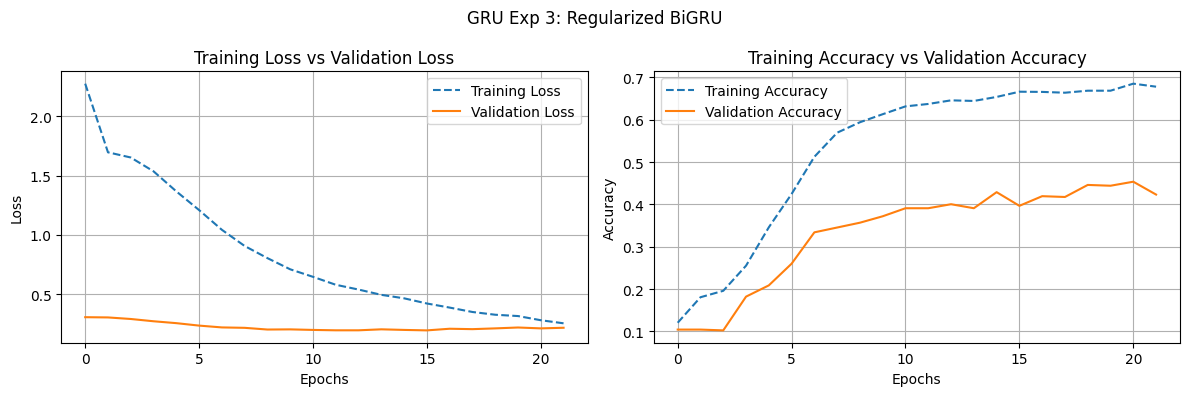

In [ ]:
plot_training(history_gru_exp3, 'GRU Exp 3: Regularized BiGRU')

In [ ]:
evaluate_model(gru_exp3)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 327ms/step
Hamming Loss: 0.0612

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.45      0.43      0.44        30
           1       0.12      0.06      0.08        18
           2       0.50      0.27      0.35        45
           3       0.27      0.16      0.20        19
           4       0.76      0.69      0.72        78
           5       0.84      0.68      0.75        47
           6       1.00      0.58      0.73        45
           7       0.00      0.00      0.00        17
           8       0.80      0.35      0.49        34
           9       0.73      0.52      0.60        93
          10       0.75      0.27      0.40        11
          11       0.44      0.44      0.44        16
          12       0.57      0.27      0.36        15
          13       0.50      0.67      0.57         3
          14       0.49      0.49      0.49        35
          15       0.59      0.53    

### Experiment 3 Results and Analysis: Regularized BiGRU

### Results
| Metric | Exp 2 (BiGRU) | Exp 3 (Regularized) | Delta |
|---|---|---|---|
| Hamming Loss | 0.0641 | 0.0612 | -0.0029 |
| Micro F1 | 0.43 | 0.49 | +0.06 |

### Outcome
Adding spatial and recurrent dropout was highly successful. The Regularized BiGRU achieved my best Hamming Loss so far (0.0612) and pushed the Micro F1 score up to 0.49. The early stopping callback halted training at Epoch 22 and restored the best weights from Epoch 16, confirming that the regularization effectively stabilized the network and prevented severe overfitting.

### Analysis
**Generalization improved significantly.** By randomly dropping 1D feature maps and recurrent connections during training, I forced the model to stop memorizing specific token sequences. This constraint allowed the network to learn much more robust, generalizable patterns, resulting in a solid +0.06 jump in the overall F1 score on the unseen test set.

**Stronger performance on mid-to-high frequency labels.** The model is becoming highly capable at identifying classes with decent support. Indicator 4 (3.3.1) reached an F1 of 0.72, and Indicator 6 (3.3.3) hit an impressive 0.73.

**The conservatism remains.** While the model is mathematically healthier, the precision (0.61) still outpaces the recall (0.41). It is clear that the 0.5 decision boundary is suppressing confident predictions for the rarest labels, which perfectly sets up my next experiment.

### Experiment 4: Threshold Tuning (on Exp 3 Model)

#### What Changed
Everything is identical to Experiment 3. The only change is the classification threshold applied to the sigmoid outputs during evaluation, lowered from 0.5 to 0.35. The model architecture, weights, and training procedure are completely unchanged.

#### Why This Change Was Made
Consistent with the findings in the Transformer experiments, the default decision threshold of 0.5 is too aggressive for heavily imbalanced multilabel datasets. Because minority SDG indicators appear so rarely, the model is inherently conservative, often outputting probabilities in the 0.30 to 0.45 range for true positives.

In [ ]:
def evaluate_model_lower_threshold(model, threshold=0.5):
    y_pred_proba = model.predict({
        'text_input': X_text_test_pad,
        'type_input': X_ohe_test
    }, verbose=0)

    y_pred = (y_pred_proba >= threshold).astype(int)

    print(f'Hamming Loss: {hamming_loss(y_test, y_pred):.4f}\n')

    short_labels = [str(i) for i in range(y_test.shape[1])]

    print('Classification Report (per label):')
    print(classification_report(y_test, y_pred, target_names=short_labels, zero_division=0))

# Test the Experiment 3 model at the lower threshold
print("Evaluating Exp 3 Model at Threshold = 0.35")
evaluate_model_lower_threshold(gru_exp3, threshold=0.35)

Evaluating Exp 3 Model at Threshold = 0.35
Hamming Loss: 0.0662

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.39      0.53      0.45        30
           1       0.13      0.11      0.12        18
           2       0.47      0.36      0.41        45
           3       0.18      0.16      0.17        19
           4       0.69      0.71      0.70        78
           5       0.80      0.70      0.75        47
           6       1.00      0.60      0.75        45
           7       0.17      0.06      0.09        17
           8       0.68      0.44      0.54        34
           9       0.62      0.57      0.59        93
          10       0.50      0.27      0.35        11
          11       0.30      0.44      0.36        16
          12       0.50      0.27      0.35        15
          13       0.33      0.67      0.44         3
          14       0.47      0.51      0.49        35
          15       0.53      0.53  

### Experiment 4 Results and Analysis: Threshold Tuning

### Results
| Metric | Exp 3 (threshold 0.5) | Exp 4 (threshold 0.35) | Delta |
|---|---|---|---|
| Hamming Loss | 0.0612 | 0.0662 | +0.0050 |
| Micro Precision | 0.61 | 0.55 | -0.06 |
| Micro Recall | 0.41 | 0.48 | +0.07 |
| Micro F1 | 0.49 | 0.51 | +0.02 |

### Outcome
Lowering the threshold to 0.35 behaved exactly as expected: it successfully recovered heavily suppressed predictions, driving the Micro F1 score up to a new high of 0.51. However, this came at the cost of the Hamming Loss, which degraded from 0.0612 to 0.0662 due to an influx of false positives.

### Analysis
**The Precision/Recall Tradeoff.** By lowering the bar for what constitutes a positive prediction, my model became far more aggressive. Micro Recall surged by +0.07 as I captured true positives that were hovering in the 0.35–0.49 probability range. Consequently, Micro Precision dropped by -0.06 because the model also started guessing incorrectly more often.

**Dead labels were revived.** The most exciting result of this threshold tuning is seeing minority classes finally register on the board. In Experiment 3, Label 18 (3.9.1) had an F1 of 0.00. By simply lowering the threshold, it jumped to 0.38. Label 7 (3.3.4) woke up from 0.00 to 0.09, and Label 20 (3.9.3) doubled from 0.12 to 0.26.

**The Hamming Loss penalty.** Hamming loss strictly counts every single error. Because dropping the threshold introduced more false positives across the 27 indicators than it did recovered true positives, the raw Hamming score worsened. However, in heavily imbalanced multi-label datasets, maximizing the Micro F1 score (0.51) is often preferred, as it proves the model is actually identifying the rare SDG targets rather than lazily predicting zeros.

# Transformer

### Loading saved shared splits

In [ ]:
nn_path = '/content/drive/MyDrive/SGD/neural_network_train_test/'

X_text_train_pad = joblib.load(f'{nn_path}X_text_train_pad.pkl')
X_text_test_pad  = joblib.load(f'{nn_path}X_text_test_pad.pkl')
X_ohe_train      = joblib.load(f'{nn_path}X_ohe_train.pkl')
X_ohe_test       = joblib.load(f'{nn_path}X_ohe_test.pkl')
y_train          = joblib.load(f'{nn_path}y_train.pkl')
y_test           = joblib.load(f'{nn_path}y_test.pkl')
tf_tokenizer     = joblib.load(f'{nn_path}tf_tokenizer.pkl')
class_weights    = joblib.load(f'{nn_path}class_weights.pkl')

## Experiment 1: Transformer Baseline

### What Changed
This is the first experiment in the transformer section and serves as the baseline for all subsequent transformer experiments. We replace the LSTM architecture with a single transformer encoder block trained from scratch, keeping everything else identical to the neural network setup: same vocabulary size (9,097), same padding length (265), same dual-input structure merging text sequences with OHE document type features, and same binary cross-entropy loss.

No dropout or regularization is applied in this experiment. The goal is to observe the transformer's raw performance before any tuning.

### Why This Change Was Made
The LSTM processes text sequentially, meaning each token is only influenced by the tokens before it. The transformer encoder processes all tokens simultaneously through self-attention, allowing every token to directly attend to every other token in the sequence. For SDG classification, where meaning is often distributed across a document rather than concentrated at the end, this is a meaningful architectural difference worth isolating.

### Architecture Summary
- Single transformer encoder block (Multi-Head Attention + Add & Norm + FFN + Add & Norm)
- Learned positional encoding added to token embeddings
- 4 attention heads, d_model = 128, dff = 256
- GlobalAveragePooling to collapse the sequence dimension
- Concatenated with OHE type features before the classification head
- No dropout (baseline, no regularization)

### Expected Outcome
The transformer may underperform the LSTM initially given the small dataset size (approx. 3,000 samples). Transformers generally require more data to learn good attention patterns compared to recurrent architectures. However this experiment establishes the reference Hamming Loss that all subsequent transformer experiments will be measured against.

### Building our model

In [ ]:
def build_transformer_baseline(
    vocab_size=9097,
    maxlen=265,
    ohe_dim=7,
    d_model=128,
    num_heads=4,
    dff=256,
    num_labels=27
):
    text_input = Input(shape=(maxlen,), name='text_input')
    type_input = Input(shape=(ohe_dim,), name='type_input')

    # input embedding: maps each token ID to a dense vector of size d_model
    x = layers.Embedding(input_dim=vocab_size, output_dim=d_model)(text_input)

    # positional encoding: transformer has no recurrence so position must be injected explicitly
    positions = tf.range(start=0, limit=maxlen, delta=1)
    pos_embedding = layers.Embedding(input_dim=maxlen, output_dim=d_model)(positions)
    x = x + pos_embedding

    # multi-head attention: Q, K, V all come from x (self-attention)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x, x)

    # add & norm residual connection preserves original signal, LayerNorm stabilises training
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    # feed forward network — expand then compress, learns position-wise transformations
    ffn_out = layers.Dense(dff, activation='relu')(x)
    ffn_out = layers.Dense(d_model)(ffn_out)

    # add & norm
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)

    # collapse (265, 128) sequence (128,) single vector per sample
    x = layers.GlobalAveragePooling1D()(x)

    # merge text representation with OHE document type features
    merged = layers.Concatenate()([x, type_input])
    x = layers.Dense(64, activation='relu')(merged)

    # sigmoid per label independent probability for each of the 27 SDG indicators
    output = layers.Dense(num_labels, activation='sigmoid')(x)

    return Model(inputs=[text_input, type_input], outputs=output)

In [ ]:
transformer_exp1 = build_transformer_baseline()

transformer_exp1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transformer_exp1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 265, 128)  │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 265, 128)  │     66,048 │ add_3[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_3[0][0],      │
│                     │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 265, 128)  │          0 │ add_3[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 128)  │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 265, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 265, 128)  │     32,896 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 265, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 128)  │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 135)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,704 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 27)        │      1,755 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,307,355 (4.99 MB)

 Trainable params: 1,307,355 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

### Training our model

In [ ]:
history_transformer_exp1 = transformer_exp1.fit(
    {'text_input': X_text_train_pad, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.1580 - loss: 1.9332 - val_accuracy: 0.1139 - val_loss: 0.2995 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2120 - loss: 1.6055 - val_accuracy: 0.1670 - val_loss: 0.2636 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3676 - loss: 1.3422 - val_accuracy: 0.3207 - val_loss: 0.2173 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5759 - loss: 0.9826 - val_accuracy: 0.3909 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6532 - loss: 0.7338 - val_accuracy: 0.4250 - val_loss: 0.1763 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6774 - loss: 0.5522 - val_accuracy: 0.3852 - val_loss: 0.1597 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6945 - loss: 0.4009 - val_ac

### Visualising Training

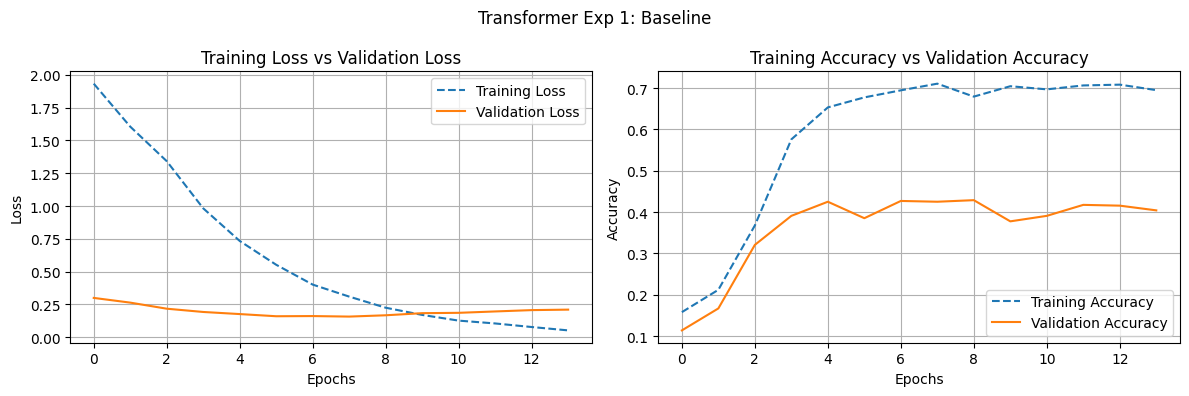

In [ ]:
plot_training(history_transformer_exp1, 'Transformer Exp 1: Baseline')


### Evaluating our model

In [ ]:
evaluate_model(transformer_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
Hamming Loss: 0.0503

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.46      0.57      0.51        30
           1       0.29      0.11      0.16        18
           2       0.60      0.40      0.48        45
           3       0.42      0.26      0.32        19
           4       0.89      0.86      0.88        78
           5       0.92      0.72      0.81        47
           6       0.96      0.53      0.69        45
           7       1.00      0.41      0.58        17
           8       0.73      0.56      0.63        34
           9       0.82      0.63      0.72        93
          10       0.67      0.55      0.60        11
          11       0.50      0.44      0.47        16
          12       0.86      0.40      0.55        15
          13       0.67      0.67      0.67         3
          14       0.77      0.69      0.73        35
          15       0.85      0.69     

### Experiment 1 Results and Analysis: Transformer Baseline

### Results

| Metric | Value |
|---|---|
| Hamming Loss | 0.0503 |
| Micro F1 | 0.61 |
| Macro F1 | 0.56 |
| Weighted F1 | 0.60 |

### Outcome
The baseline transformer achieved a Hamming Loss of 0.0503, meaning the model correctly predicts approximately 95% of label assignments per sample across all 27 indicators. For a single encoder block trained from scratch on approximately 3,000 samples with no regularization, this is a reasonable starting point and establishes the reference for all subsequent transformer experiments.

### Analysis

**Precision consistently outperforms recall across almost every label.** Label 6 (precision 0.96, recall 0.53) and Label 7 (precision 1.00, recall 0.41) are the clearest examples of this pattern. When the model commits to a prediction it is usually correct, but it is missing a large number of true positives. The model is being overly conservative, defaulting to not predicting a label unless it is highly confident.

**The default threshold of 0.5 is too aggressive for this dataset.** In multilabel classification with imbalanced data, sigmoid outputs for true positive cases frequently sit in the 0.3 to 0.45 range. A threshold of 0.5 cuts these off, producing the high precision / low recall gap visible across the classification report. This is not a model quality problem, it is a threshold calibration problem.

**Minority labels are underperforming.** Label 1 (support 18, F1 0.16), Label 3 (support 19, F1 0.32), and Label 17 (support 33, F1 0.34) are the weakest performers. Despite random oversampling applied during preprocessing, the transformer struggles to learn reliable signal for rare indicators from scratch on a small dataset. This is an expected limitation of training a transformer without pretrained weights on limited data.

**Majority labels perform well.** Label 4 (F1 0.88), Label 5 (F1 0.81), and Label 19 (F1 0.77) all have strong F1 scores and adequate support. The model has learned meaningful signal for well-represented indicators.

### Insight
The most actionable finding from this experiment is the systematic precision / recall imbalance caused by the default threshold. Lowering the threshold is expected to recover a significant number of missed true positives and improve recall across most labels without any architectural change. This is isolated as the sole change in Experiment 2.

## Experiment 2: Threshold Tuning

### What Changed
Everything is identical to Experiment 1. The only change is the classification threshold applied to the sigmoid outputs, lowered from 0.5 to 0.3. The model architecture, weights, and training procedure are unchanged. We are re-evaluating the already trained Experiment 1 model with a new threshold.

### Why This Change Was Made
Experiment 1 revealed a consistent pattern across almost every label: precision was significantly higher than recall. This indicates the model was producing confident correct predictions but missing a large number of true positives. The likely cause is that sigmoid outputs for true positive cases were sitting below 0.5, causing them to be discarded at the default threshold.

Lowering the threshold to 0.3 means the model will predict a label positive if its sigmoid output exceeds 0.3 rather than 0.5. This is expected to recover missed true positives and improve recall at the cost of some precision. For Hamming Loss, which penalises both false positives and false negatives equally, the net effect depends on which direction the errors move.

### What We Expect to See
Recall should increase across most labels, particularly the minority indicators that were being systematically missed. Precision will likely drop slightly as the model becomes less conservative. Whether Hamming Loss improves or worsens depends on whether the recovered true positives outweigh the newly introduced false positives. If Hamming Loss improves, 0.3 becomes the standard threshold for all subsequent experiments.

In [ ]:
def evaluate_model_lower_threshold(model, threshold=0.5):
    y_pred_proba = model.predict({
        'text_input': X_text_test_pad,
        'type_input': X_ohe_test
    })

    y_pred = (y_pred_proba >= threshold).astype(int)

    print(f'Hamming Loss: {hamming_loss(y_test, y_pred):.4f}\n')

    short_labels = [str(i) for i in range(y_test.shape[1])]

    print('Classification Report (per label):')
    print(classification_report(y_test, y_pred, target_names=short_labels, zero_division=0))

In [ ]:
evaluate_model_lower_threshold(transformer_exp1, threshold=0.3)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Hamming Loss: 0.0568

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.43      0.60      0.50        30
           1       0.12      0.11      0.12        18
           2       0.49      0.47      0.48        45
           3       0.35      0.32      0.33        19
           4       0.78      0.87      0.82        78
           5       0.88      0.79      0.83        47
           6       0.93      0.58      0.71        45
           7       1.00      0.47      0.64        17
           8       0.72      0.68      0.70        34
           9       0.80      0.70      0.75        93
          10       0.54      0.64      0.58        11
          11       0.56      0.56      0.56        16
          12       0.86      0.40      0.55        15
          13       0.50      0.67      0.57         3
          14       0.71      0.71      0.71        35
          15       0.67      0.69      

### Experiment 2 Results and Analysis: Threshold Tuning

### Results

| Metric | Exp 1 (threshold 0.5) | Exp 2 (threshold 0.3) | Delta |
|---|---|---|---|
| Hamming Loss | 0.0503 | 0.0568 | +0.0065 |
| Micro F1 | 0.61 | 0.61 | 0.00 |
| Macro F1 | 0.56 | 0.56 | 0.00 |
| Weighted F1 | 0.60 | 0.61 | +0.01 |
| Micro Precision | 0.70 | 0.61 | -0.09 |
| Micro Recall | 0.54 | 0.61 | +0.07 |

### Outcome
Lowering the threshold from 0.5 to 0.3 increased Hamming Loss from 0.0503 to 0.0568, meaning performance worsened. The threshold change did exactly what was predicted recall increased and precision decreased however the false positives introduced by the lower threshold outweighed the true positives recovered, resulting in a net increase in label errors across the dataset. The default threshold of 0.5 is retained for all subsequent experiments.

### Analysis

**The precision / recall redistribution confirms the hypothesis from Experiment 1.** Micro precision dropped from 0.70 to 0.61 while micro recall rose from 0.54 to 0.61, producing a perfectly balanced micro average. The threshold did shift the model's behaviour as expected. The problem is that on this dataset, the additional false positives cost more in Hamming Loss than the recovered true positives gained.

**Minority labels did not meaningfully improve.** Label 1 dropped from F1 0.16 to 0.12. Label 3 moved from 0.32 to 0.33. The core issue for rare indicators is not the threshold, it is insufficient data for the model to learn reliable signal from scratch. Lowering the bar for prediction cannot compensate for weak learned representations.

**Macro F1 is not used as the primary supporting metric here.** The dataset is highly imbalanced, with label support ranging from 3 to 215 samples. Macro F1 treats every label as equally important when averaging, meaning Label 13 with 3 samples influences the macro score as much as Label 23 with 215 samples. This produces a noisy and misleading summary. Micro F1 pools all predictions before computing the average and is therefore more representative of actual model behavi

## Experiment 3: Dropout Regularization

### What Changed
Dropout (rate = 0.1) is added at two points inside the transformer encoder block: after the multi-head attention output and after the feed forward network output. Everything else is identical to Experiment 1, including the threshold of 0.5.

### Why This Change Was Made
Experiment 2 confirmed that threshold tuning is not the lever for improving this model. The precision / recall imbalance and weak minority label performance point to a representation quality problem rather than a calibration problem. With only approximately 3,000 training samples, a transformer trained from scratch is prone to overfitting, memorizing training patterns rather than learning generalizable signal.

Dropout after the attention and FFN sublayers forces the encoder to learn more robust representations by randomly deactivating 10% of units during each training step. This is applied inside the encoder specifically because that is where the overfitting risk is highest on a small dataset.

### What We Expect to See
Improved generalization on the test set, reflected in a lower Hamming Loss than Experiment 1. Recall on minority labels may improve if the encoder learns less dataset-specific noise and more transferable signal. Precision is not expected to drop significantly since the threshold remains at 0.5.

### Building the model

In [ ]:
def build_transformer_exp3(
    vocab_size=9097,
    maxlen=265,
    ohe_dim=7,
    d_model=128,
    num_heads=4,
    dff=256,
    num_labels=27,
    dropout_rate=0.1
):
    text_input = Input(shape=(maxlen,), name='text_input')
    type_input = Input(shape=(ohe_dim,), name='type_input')

    # input embedding — maps token IDs to dense vectors of size d_model
    x = layers.Embedding(input_dim=vocab_size, output_dim=d_model)(text_input)

    # positional encoding — injects word order since transformer has no recurrence
    positions = tf.range(start=0, limit=maxlen, delta=1)
    pos_embedding = layers.Embedding(input_dim=maxlen, output_dim=d_model)(positions)
    x = x + pos_embedding

    # multi-head attention — Q, K, V all from x (self-attention)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x, x)

    # dropout after attention — forces encoder to learn robust representations on small data
    attn_out = layers.Dropout(dropout_rate)(attn_out)

    # add & norm
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    # feed forward network — position-wise transformations
    ffn_out = layers.Dense(dff, activation='relu')(x)
    ffn_out = layers.Dense(d_model)(ffn_out)

    # dropout after FFN
    ffn_out = layers.Dropout(dropout_rate)(ffn_out)

    # add & norm
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)

    # collapse sequence dimension to single vector per sample
    x = layers.GlobalAveragePooling1D()(x)

    # merge text representation with OHE document type features
    merged = layers.Concatenate()([x, type_input])
    x = layers.Dense(64, activation='relu')(merged)

    # sigmoid per label — independent probability for each of the 27 SDG indicators
    output = layers.Dense(num_labels, activation='sigmoid')(x)

    return Model(inputs=[text_input, type_input], outputs=output)

In [ ]:
transformer_exp3 = build_transformer_exp3()

transformer_exp3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transformer_exp3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 265, 128)  │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 265, 128)  │     66,048 │ add_6[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_6[0][0],      │
│                     │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 265, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 265, 128)  │          0 │ add_6[0][0],      │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 128)  │        256 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 265, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 265, 128)  │     32,896 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 265, 128)  │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 265, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 128)  │        256 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 135)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,704 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 27)        │      1,755 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,307,355 (4.99 MB)

 Trainable params: 1,307,355 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

### Training model

In [ ]:
history_transformer_exp3 = transformer_exp3.fit(
    {'text_input': X_text_train_pad, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.1399 - loss: 1.8917 - val_accuracy: 0.1044 - val_loss: 0.2925 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1874 - loss: 1.6252 - val_accuracy: 0.1252 - val_loss: 0.2738 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3202 - loss: 1.4007 - val_accuracy: 0.3188 - val_loss: 0.2160 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5830 - loss: 1.0050 - val_accuracy: 0.4307 - val_loss: 0.1815 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6565 - loss: 0.7156 - val_accuracy: 0.4877 - val_loss: 0.1642 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7073 - loss: 0.5122 - val_accuracy: 0.4004 - val_loss: 0.1535 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7230 - loss: 0.3951 - val_a

### Visualising Training

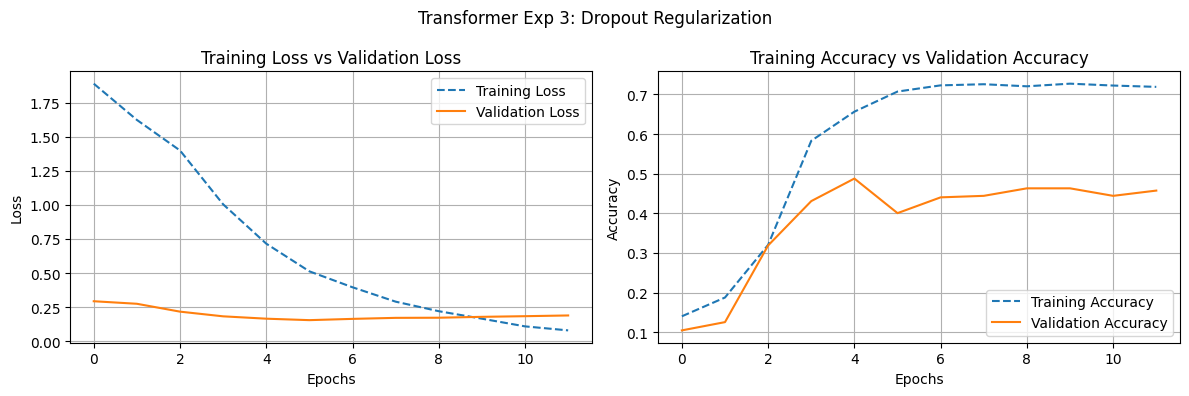

In [ ]:
plot_training(history_transformer_exp3, 'Transformer Exp 3: Dropout Regularization')

### Evaluating model

In [ ]:
evaluate_model_lower_threshold(transformer_exp3, threshold=0.5)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Hamming Loss: 0.0498

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.54      0.63      0.58        30
           1       0.33      0.17      0.22        18
           2       0.68      0.38      0.49        45
           3       0.50      0.26      0.34        19
           4       0.98      0.77      0.86        78
           5       0.89      0.83      0.86        47
           6       0.97      0.69      0.81        45
           7       0.75      0.18      0.29        17
           8       0.73      0.47      0.57        34
           9       0.91      0.63      0.75        93
          10       0.55      0.55      0.55        11
          11       0.41      0.56      0.47        16
          12       0.86      0.40      0.55        15
          13       0.50      0.67      0.57         3
          14       0.89      0.69      0.77        35
          15       0.74      0.72      

### Experiment 3 Results and Analysis: Dropout Regularization

### Results

| Metric | Exp 1 (baseline) | Exp 3 (dropout 0.1) | Delta |
|---|---|---|---|
| Hamming Loss | 0.0503 | 0.0498 | -0.0005 |
| Micro F1 | 0.61 | 0.60 | -0.01 |
| Macro F1 | 0.56 | 0.54 | -0.02 |
| Weighted F1 | 0.60 | 0.59 | -0.01 |
| Micro Precision | 0.70 | 0.72 | +0.02 |
| Micro Recall | 0.54 | 0.51 | -0.03 |

### Outcome
Adding dropout (rate = 0.1) after the attention and FFN sublayers produced a marginal improvement in Hamming Loss from 0.0503 to 0.0498. While this confirms that regularization has a small positive effect on overall label accuracy, the improvement is minimal and the precision / recall pattern moved in the wrong direction, with recall dropping further from 0.54 to 0.51.

### Analysis

**Dropout increased model conservatism rather than improving generalization.** Micro precision rose from 0.70 to 0.72 while recall dropped from 0.54 to 0.51. During training, dropout randomly deactivates units, producing noisier signals and reducing the model's overall confidence. At inference time with threshold 0.5, this reduced confidence means more sigmoid outputs fall below the cutoff, resulting in fewer positive predictions overall.

**Minority labels were most affected by the increased conservatism.** Label 7 dropped from F1 0.58 to 0.29, Label 16 from 0.45 to 0.34, and Label 17 from 0.34 to 0.30. These are already the hardest labels to predict due to limited support, and the dropout-induced conservatism disproportionately hurt them.

**The overall pattern across Experiments 1 through 3 points to a precision / recall imbalance that dropout alone cannot resolve.** The model consistently predicts with high precision but misses a large number of true positives. This behaviour is reinforced by dropout, which makes the model more selective rather than more sensitive.

### Insight
Experiment 3 established that dropout marginally improves Hamming Loss but further suppresses recall. Experiment 4 directly addresses the recall problem by lowering the threshold to 0.3 on the Experiment 3 model, testing whether combining regularization with a lower prediction bar produces a better balance than either change did in isolation.

## Experiment 4: Second Transformer Encoder Block

### What Changed
A second transformer encoder block is added after the first, stacking two encoder layers before the GlobalAveragePooling step. Everything else is identical to Experiment 3, including dropout (rate = 0.1) and threshold 0.5.

### Why This Change Was Made
Experiments 1 through 3 established that the single encoder block has limited representational capacity on this dataset. Dropout provided a marginal Hamming Loss improvement but did not address the core problem of weak learned representations. Adding a second encoder block gives the model more depth to learn hierarchical patterns across the text. The first block learns low level token relationships while the second block can learn higher level semantic patterns built on top of those.

### What We Expect to See
A meaningful improvement in Hamming Loss compared to Experiment 3. Deeper transformer architectures generally learn richer representations, which should help the model distinguish between semantically similar SDG indicators. Minority label performance may also improve if the additional depth helps the model extract more signal from limited examples.

### Building our model

In [ ]:
def build_transformer_exp4(
    vocab_size=9097,
    maxlen=265,
    ohe_dim=7,
    d_model=128,
    num_heads=4,
    dff=256,
    num_labels=27,
    dropout_rate=0.1
):
    text_input = Input(shape=(maxlen,), name='text_input')
    type_input = Input(shape=(ohe_dim,), name='type_input')

    # input embedding — maps token IDs to dense vectors of size d_model
    x = layers.Embedding(input_dim=vocab_size, output_dim=d_model)(text_input)

    # positional encoding: injects word order since transformer has no recurrence
    positions = tf.range(start=0, limit=maxlen, delta=1)
    pos_embedding = layers.Embedding(input_dim=maxlen, output_dim=d_model)(positions)
    x = x + pos_embedding

    # encoder block 1: learns low level token relationships
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x, x)
    attn_out = layers.Dropout(dropout_rate)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ffn_out = layers.Dense(dff, activation='relu')(x)
    ffn_out = layers.Dense(d_model)(ffn_out)
    ffn_out = layers.Dropout(dropout_rate)(ffn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)

    # encoder block 2: learns higher level semantic patterns on top of block 1
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x, x)
    attn_out = layers.Dropout(dropout_rate)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ffn_out = layers.Dense(dff, activation='relu')(x)
    ffn_out = layers.Dense(d_model)(ffn_out)
    ffn_out = layers.Dropout(dropout_rate)(ffn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)

    # collapse sequence dimension to single vector per sample
    x = layers.GlobalAveragePooling1D()(x)

    # merge text representation with OHE document type features
    merged = layers.Concatenate()([x, type_input])
    x = layers.Dense(64, activation='relu')(merged)

    # sigmoid per label — independent probability for each of the 27 SDG indicators
    output = layers.Dense(num_labels, activation='sigmoid')(x)

    return Model(inputs=[text_input, type_input], outputs=output)

In [ ]:
transformer_exp4 = build_transformer_exp4()

transformer_exp4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transformer_exp4.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 265, 128)  │  1,164,416 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 265, 128)  │          0 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 265, 128)  │     66,048 │ add_9[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_9[0][0],      │
│                     │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 265, 128)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 265, 128)  │          0 │ add_9[0][0],      │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 128)  │        256 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 265, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 265, 128)  │     32,896 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 265, 128)  │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 265, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 128)  │        256 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 265, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 265, 128)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 265, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 128)  │        256 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 265, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,439,835 (5.49 MB)

 Trainable params: 1,439,835 (5.49 MB)

 Non-trainable params: 0 (0.00 B)

### Training our model

In [ ]:
history_transformer_exp4 = transformer_exp4.fit(
    {'text_input': X_text_train_pad, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 58s 361ms/step - accuracy: 0.1618 - loss: 1.9289 - val_accuracy: 0.1044 - val_loss: 0.3030 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.2059 - loss: 1.6357 - val_accuracy: 0.1803 - val_loss: 0.2548 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4274 - loss: 1.2857 - val_accuracy: 0.2865 - val_loss: 0.2117 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5659 - loss: 0.9365 - val_accuracy: 0.4156 - val_loss: 0.1786 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6442 - loss: 0.6721 - val_accuracy: 0.4080 - val_loss: 0.1846 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6670 - loss: 0.4985 - val_accuracy: 0.4649 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6888 - loss: 0.3575 - val_

### Visualising our model

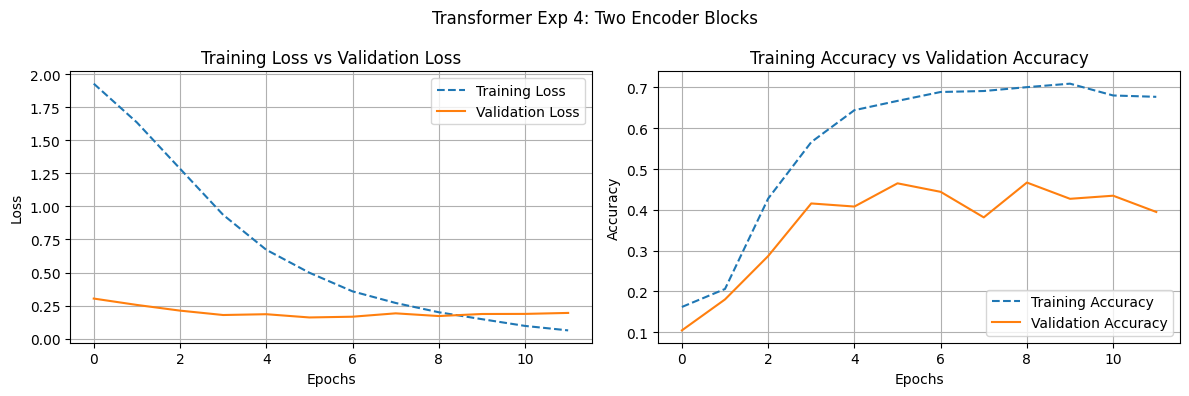

In [ ]:
plot_training(history_transformer_exp4, 'Transformer Exp 4: Two Encoder Blocks')

### Evaluating our model

In [ ]:
evaluate_model_lower_threshold(transformer_exp4, threshold=0.5)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
Hamming Loss: 0.0561

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.50      0.47      0.48        30
           1       0.00      0.00      0.00        18
           2       0.54      0.29      0.38        45
           3       0.25      0.26      0.26        19
           4       0.89      0.82      0.85        78
           5       0.97      0.62      0.75        47
           6       0.89      0.69      0.78        45
           7       0.62      0.29      0.40        17
           8       0.65      0.38      0.48        34
           9       0.79      0.75      0.77        93
          10       0.54      0.64      0.58        11
          11       0.37      0.62      0.47        16
          12       0.58      0.47      0.52        15
          13       0.25      0.67      0.36         3
          14       0.69      0.71      0.70        35
          15       0.68      0.66     

### Experiment 4 Results and Analysis: Second Transformer Encoder Block

### Results

| Metric | Exp 1 (baseline) | Exp 3 (dropout) | Exp 4 (two blocks) | Delta vs Exp 3 |
|---|---|---|---|---|
| Hamming Loss | 0.0503 | 0.0498 | 0.0561 | +0.0063 |
| Micro F1 | 0.61 | 0.60 | 0.56 | -0.04 |
| Macro F1 | 0.56 | 0.54 | 0.49 | -0.05 |
| Weighted F1 | 0.60 | 0.59 | 0.54 | -0.05 |
| Micro Precision | 0.70 | 0.72 | 0.65 | -0.07 |
| Micro Recall | 0.54 | 0.51 | 0.49 | -0.02 |

### Outcome
Adding a second transformer encoder block worsened performance across every metric. Hamming Loss increased from 0.0498 to 0.0561, the worst result across all transformer experiments so far. The model did not benefit from additional depth and several labels that were already struggling deteriorated significantly.

### Analysis

**The model got worse on both precision and recall simultaneously.** This is not a tradeoff between the two, it is a sign that the model is failing to train effectively. Micro precision dropped from 0.72 to 0.65 and micro recall dropped from 0.51 to 0.49. When both metrics decline together it indicates the additional capacity is not being utilized productively.

**Several minority labels collapsed entirely.** Label 1 produced an F1 of 0.00, meaning the model predicted zero positives for that label across the entire test set. Label 17 dropped from F1 0.30 to 0.10 and Label 24 dropped from 0.44 to 0.26. The increased model complexity disproportionately hurt the labels with the least training signal.

**Two factors explain the degradation.** First, doubling the encoder depth doubled the number of trainable parameters without a corresponding increase in training data. With approximately 3,000 samples the model now has more capacity than the data can support, leading to overfitting. Second, deeper transformers are harder to optimize from random initialization. Without pretrained weights the gradient signal may not propagate effectively through two stacked attention blocks on a small dataset.

**This experiment rules out depth as a solution.** Across Experiments 1 through 4 the pattern is consistent. Architectural changes and regularization strategies applied to a transformer trained from scratch have produced only marginal improvements at best and degradation at worst. The root cause is not architecture depth, number of attention heads, or regularization strategy. It is the quality of the token representations entering the encoder.

### Insight
Experiment 4 provides the clearest evidence yet that this dataset cannot support a deeper transformer trained from scratch. The logical next step is to stop improving the architecture and instead improve the representations. Experiment 5 introduces GloVe pretrained embeddings, replacing random embedding initialization with vectors trained on a large external corpus. This directly addresses the root cause identified across the experiment chain.

## Experiment 5: GloVe Pretrained Embeddings

### What Changed
The learned embedding layer is replaced with GloVe pretrained embeddings (100d). The embedding weights are initialized from GloVe vectors trained on a large external corpus rather than randomly initialized and learned from scratch on the SDG dataset. d_model is set to 100 to match the GloVe vector dimension, removing the need for a projection layer. The architecture returns to a single encoder block with dropout (rate = 0.1) from Experiment 3, which was the best performing architecture so far.

### Why This Change Was Made
Experiments 1 through 4 consistently pointed to the same root cause: the model does not have strong enough token representations to generalize well on approximately 3,000 samples. Random embedding initialization means every token starts as noise and must be learned entirely from limited domain data. GloVe vectors provide a meaningful starting point by encoding semantic relationships learned from a much larger corpus. Words that are semantically similar in general language, such as "maternal" and "neonatal", will already be close in the embedding space before any training begins.

### What We Expect to See
A meaningful improvement in Hamming Loss compared to Experiment 3. Pretrained embeddings should help the model generalize better on majority labels where GloVe has strong coverage. Minority label performance may also improve if the richer starting representations help the encoder extract more signal from limited examples. Domain specific terms with weak or absent GloVe coverage will fall back to the OOV vector, which is a known limitation of this approach and sets up the motivation for BERT in the following experiment.

### Importing glove

In [ ]:
# download GloVe vectors
import urllib.request
import zipfile
import os

glove_path = '/content/glove.6B.100d.txt'

if not os.path.exists(glove_path):
    urllib.request.urlretrieve(
        'http://nlp.stanford.edu/data/glove.6B.zip',
        '/content/glove.6B.zip'
    )
    with zipfile.ZipFile('/content/glove.6B.zip', 'r') as f:
        f.extract('glove.6B.100d.txt', '/content/')

In [ ]:
# load GloVe vectors into a dictionary
glove_vectors = {}

with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_vectors[word] = vector

print(f'GloVe vectors loaded: {len(glove_vectors)}')

GloVe vectors loaded: 400000


In [ ]:
vocab_size = 9097

# build embedding matrix aligned to your tokenizer vocabulary
# tokens not found in GloVe fall back to zero vector
GLOVE_DIM = 100
word_index = tf_tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found = 0
for word, idx in word_index.items():
    if idx < vocab_size:
        vector = glove_vectors.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            found += 1

print(f'Tokens covered by GloVe: {found} / {vocab_size}')
print(f'OOV tokens: {vocab_size - found}')

Tokens covered by GloVe: 7776 / 9097
OOV tokens: 1321


### Building our Model





In [ ]:
def build_transformer_exp5(
    vocab_size=9097,
    maxlen=265,
    ohe_dim=7,
    d_model=100,
    num_heads=4,
    dff=256,
    num_labels=27,
    dropout_rate=0.1
):
    text_input = Input(shape=(maxlen,), name='text_input')
    type_input = Input(shape=(ohe_dim,), name='type_input')

    # pretrained GloVe embedding — weights initialized from external corpus, not random
    # trainable=True allows fine-tuning on SDG data during training
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=d_model,
        weights=[embedding_matrix],
        trainable=True
    )(text_input)

    # positional encoding — d_model is now 100 to match GloVe dimension
    positions = tf.range(start=0, limit=maxlen, delta=1)
    pos_embedding = layers.Embedding(input_dim=maxlen, output_dim=d_model)(positions)
    x = x + pos_embedding

    # single encoder block
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x, x)
    attn_out = layers.Dropout(dropout_rate)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    ffn_out = layers.Dense(dff, activation='relu')(x)
    ffn_out = layers.Dense(d_model)(ffn_out)
    ffn_out = layers.Dropout(dropout_rate)(ffn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)

    # collapse sequence dimension to single vector per sample
    x = layers.GlobalAveragePooling1D()(x)

    # merge text representation with OHE document type features
    merged = layers.Concatenate()([x, type_input])
    x = layers.Dense(64, activation='relu')(merged)

    # sigmoid per label — independent probability for each of the 27 SDG indicators
    output = layers.Dense(num_labels, activation='sigmoid')(x)

    return Model(inputs=[text_input, type_input], outputs=output)

In [ ]:
transformer_exp5 = build_transformer_exp5()

transformer_exp5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transformer_exp5.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 265)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 265, 100)  │    909,700 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 265, 100)  │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 265, 100)  │     40,400 │ add_14[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_14[0][0],     │
│                     │                   │            │ add_14[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 265, 100)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 265, 100)  │          0 │ add_14[0][0],     │
│                     │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 100)  │        200 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 265, 256)  │     25,856 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 265, 100)  │     25,700 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 265, 100)  │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 265, 100)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 265, 100)  │        200 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 107)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      6,912 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 27)        │      1,755 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,010,723 (3.86 MB)

 Trainable params: 1,010,723 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

### Training our model

In [ ]:
history_transformer_exp5 = transformer_exp5.fit(
    {'text_input': X_text_train_pad, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 304ms/step - accuracy: 0.1670 - loss: 1.9231 - val_accuracy: 0.1044 - val_loss: 0.3031 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2329 - loss: 1.6239 - val_accuracy: 0.2125 - val_loss: 0.2741 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4606 - loss: 1.3210 - val_accuracy: 0.3397 - val_loss: 0.2238 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5417 - loss: 1.0579 - val_accuracy: 0.4156 - val_loss: 0.1932 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5721 - loss: 0.9017 - val_accuracy: 0.4535 - val_loss: 0.1803 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6020 - loss: 0.7979 - val_accuracy: 0.4611 - val_loss: 0.1770 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6276 - loss: 0.7014 - val_a

### Visualising training

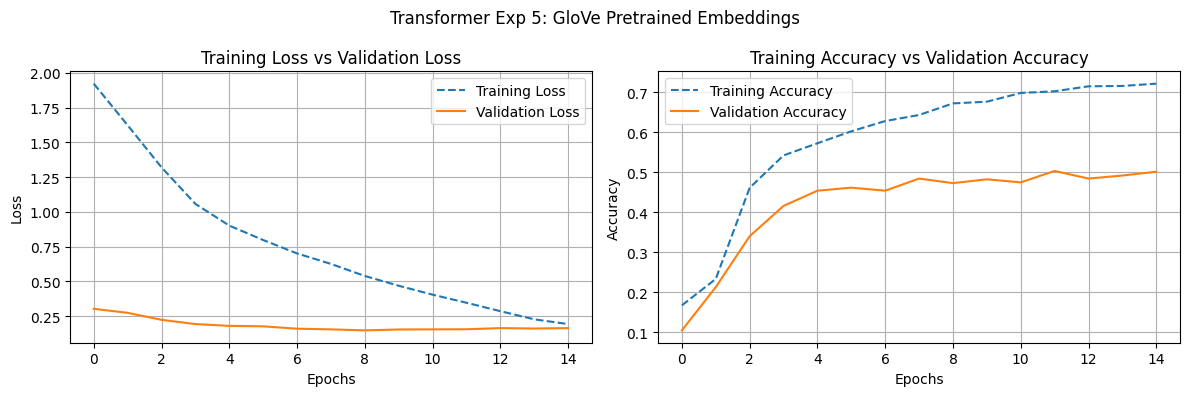

In [ ]:
plot_training(history_transformer_exp5, 'Transformer Exp 5: GloVe Pretrained Embeddings')

### Evaluating our training

In [ ]:
evaluate_model(transformer_exp5, threshold=0.5)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step
Hamming Loss: 0.0540

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.41      0.60      0.49        30
           1       0.20      0.11      0.14        18
           2       0.61      0.38      0.47        45
           3       0.50      0.37      0.42        19
           4       0.87      0.71      0.78        78
           5       0.92      0.74      0.82        47
           6       0.84      0.69      0.76        45
           7       1.00      0.59      0.74        17
           8       0.58      0.65      0.61        34
           9       0.80      0.77      0.79        93
          10       0.36      0.45      0.40        11
          11       0.32      0.50      0.39        16
          12       0.75      0.40      0.52        15
          13       0.60      1.00      0.75         3
          14       0.83      0.69      0.75        35
          15       0.76      0.69    

### Experiment 5 Results and Analysis: GloVe Pretrained Embeddings

### Results

| Metric | Exp 1 (baseline) | Exp 3 (dropout) | Exp 5 (GloVe) | Delta vs Exp 3 |
|---|---|---|---|---|
| Hamming Loss | 0.0503 | 0.0498 | 0.0540 | +0.0042 |
| Micro F1 | 0.61 | 0.60 | 0.60 | 0.00 |
| Macro F1 | 0.56 | 0.54 | 0.56 | +0.02 |
| Weighted F1 | 0.60 | 0.59 | 0.60 | +0.01 |
| Micro Precision | 0.70 | 0.72 | 0.65 | -0.07 |
| Micro Recall | 0.54 | 0.51 | 0.56 | +0.05 |

### Outcome
Replacing learned embeddings with GloVe pretrained vectors did not improve Hamming Loss compared to Experiment 3, increasing it from 0.0498 to 0.0540. However the experiment produced the strongest recall across all transformer experiments so far, with micro recall rising from 0.51 to 0.56. GloVe improved the model's ability to find true positives but introduced enough false positives to produce a net increase in label errors.

### Analysis

**Recall improved meaningfully but at a precision cost.** Micro recall jumped from 0.51 to 0.56, the largest recall gain across all experiments. GloVe vectors gave the model richer semantic starting representations, helping it identify more true positive cases. However micro precision dropped from 0.72 to 0.65, meaning the model also became less selective. The net effect on Hamming Loss was negative.

**Labels with strong GloVe coverage improved significantly.** Label 7 jumped from F1 0.29 to 0.74, Label 13 reached F1 0.75 with perfect recall, and Label 9 improved from 0.75 to 0.79. These are indicators where the relevant vocabulary is well represented in the GloVe corpus and the pretrained vectors provided meaningful signal.

**Domain specific labels remained weak.** Label 1 stayed at F1 0.14 and Label 24 dropped to 0.35. The 1,321 OOV tokens (15% of the vocabulary) fall back to zero vectors and contribute no semantic signal. These uncovered tokens are concentrated in health and development sector terminology, exactly the vocabulary that minority SDG indicators depend on most.

**GloVe vectors are static and context-free.** Even for covered tokens, GloVe assigns a single fixed vector regardless of context. The word "mortality" has the same representation whether it appears in a sentence about maternal health or child nutrition. For SDG classification where the same term can signal different indicators depending on context, this is a fundamental limitation.

**The 85% GloVe coverage finding is informative.** While the majority of general vocabulary tokens were covered, the uncovered 15% represents the most domain-specific and therefore most discriminative vocabulary in the corpus. This means GloVe helps with general language understanding but misses the precise terminology that separates one SDG indicator from another.

### Insight
Experiment 5 confirms that pretrained representations improve recall but static context-free embeddings cannot fully address the domain vocabulary gap in this dataset. Both limitations, OOV tokens and context-free vectors, point directly to BERT as the next experiment. BERT uses subword tokenization which eliminates OOV tokens entirely, and its contextual representations assign different vectors to the same word depending on surrounding context. Experiment 6 fine-tunes BERT on the SDG dataset to test whether contextual pretrained representations produce the improvement that static embeddings could not.

## Experiment 6: Frozen BERT

### What Changed
The custom transformer encoder is replaced entirely with a pretrained BERT model (bert-base-uncased) loaded via Hugging Face. All BERT weights are frozen they do not update during training. Only the classification head trained on top of BERT's output. The input pipeline also changes: BERT requires its own tokenizer to generate input_ids and attention_mask tensors, replacing the Keras tokenizer and padded sequences used in previous experiments.

### Why This Change Was Made
Experiment 5 showed that GloVe pretrained embeddings improved recall but could not beat Experiment 3 on Hamming Loss. Two limitations were identified: 15% of the vocabulary had no GloVe coverage due to domain-specific terminology, and GloVe vectors are static and context-free. BERT addresses both problems directly. Its subword tokenization eliminates OOV tokens entirely by breaking unknown words into known subword pieces, and its contextual representations assign different vectors to the same token depending on surrounding context.

Freezing BERT weights in this experiment tests whether BERT's general language understanding transfers directly to SDG text without any domain adaptation. This isolates the contribution of pretrained contextual representations alone, before introducing fine-tuning in Experiment 7.

### What We Expect to See
A meaningful improvement in Hamming Loss compared to all previous transformer experiments. BERT's contextual representations should produce richer token encodings than anything learned from scratch or initialized from GloVe. Minority label performance may improve significantly since subword tokenization ensures domain-specific health terminology contributes signal rather than falling back to OOV vectors. If frozen BERT already performs well, it confirms that BERT's general pretraining transfers strongly to this domain without needing adaptation.

### Setup

In [ ]:
!pip install transformers tensorflow -q

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Experiment 6 requires raw text strings for BERT tokenization.
# The saved pipeline files contain padded integer sequences, not raw text.
# We reconstruct the raw text train/test split here using the same
# random_state=42 as the original preprocessing pipeline to guarantee alignment.

df_raw = pd.read_csv('/content/Devex_train.csv', encoding='latin-1')
df_raw['Text_cleaned'] = df_raw['Text'].apply(lambda x: clean_text(x, remove_stopwords=True))

X_text_train_raw, X_text_test_raw = train_test_split(
    df_raw['Text_cleaned'],
    test_size=0.2,
    random_state=42
)

print(f'Train raw text: {len(X_text_train_raw)} samples')
print(f'Test raw text:  {len(X_text_test_raw)} samples')

Train raw text: 2396 samples
Test raw text:  599 samples


In [ ]:
# BERT requires its own tokenizer — the Keras tokenizer from the preprocessing
# pipeline is incompatible. We also need to rebuild the ROS text here because
# BERT must be tokenized on the same balanced training distribution used in
# all other experiments.

label_cols = [c for c in df_raw.columns if c.startswith('Label')]
y_full = df_raw[label_cols].values

y_train_raw = y_full[X_text_train_raw.index]

MIN_SAMPLES = 80
X_text_res  = list(X_text_train_raw)
y_res_bert  = y_train_raw.copy()

for i in range(y_train_raw.shape[1]):
    pos_idx = np.where(y_train_raw[:, i] == 1)[0]

    # skip labels with no positive samples — nothing to resample from
    if len(pos_idx) == 0:
        continue

    if len(pos_idx) < MIN_SAMPLES:
        extra = resample(
            pos_idx,
            n_samples=MIN_SAMPLES - len(pos_idx),
            random_state=42
        )
        X_text_res = X_text_res + [list(X_text_train_raw)[j] for j in extra]
        y_res_bert = np.vstack([y_res_bert, y_train_raw[extra]])

print(f'ROS text samples: {len(X_text_res)}')
print(f'ROS labels shape: {y_res_bert.shape}')

ROS text samples: 2396
ROS labels shape: (2396, 12)


In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### BERT Embedding Extraction

BERT tokenization and embedding extraction is computationally expensive on 2,635 training samples. To avoid re-running this on every notebook execution, embeddings are extracted once and saved to Drive. The cell below checks if the saved files already exist before extracting. If they exist, they are loaded directly. If not, extraction runs and saves to Drive automatically.

Note: embeddings are extracted from the ROS-balanced text, not the original pre-split text. This ensures the training embeddings match the same balanced distribution used in all other experiments.

In [ ]:
import os

nn_path = '/content/drive/MyDrive/SGD/neural_network_train_test/'

bert_train_path = f'{nn_path}X_bert_train.pkl'
bert_test_path  = f'{nn_path}X_bert_test.pkl'

if os.path.exists(bert_train_path) and os.path.exists(bert_test_path):
    print('Loading saved BERT embeddings from Drive...')
    X_bert_train = joblib.load(bert_train_path)
    X_bert_test  = joblib.load(bert_test_path)
    print('Loaded successfully')

else:
    print('Saved embeddings not found, extracting now...')

    bert_model_extract = BertModel.from_pretrained('bert-base-uncased')
    bert_model_extract.to(device)
    bert_model_extract.eval()

    def extract_bert_embeddings(texts, batch_size=32):
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = list(texts[i:i + batch_size])
            encoded = bert_tokenizer(
                batch,
                max_length=265,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            input_ids      = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask'].to(device)
            with torch.no_grad():
                outputs = bert_model_extract(input_ids=input_ids, attention_mask=attention_mask)
                # CLS token is always position 0 — BERT's sequence level representation
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)
            print(f'Batch {i // batch_size + 1} / {(len(texts) - 1) // batch_size + 1}')
        return np.vstack(all_embeddings)

    print('Extracting train embeddings from ROS balanced text...')
    X_bert_train = extract_bert_embeddings(X_text_res)

    print('Extracting test embeddings...')
    X_bert_test = extract_bert_embeddings(list(X_text_test_raw.reset_index(drop=True)))

    joblib.dump(X_bert_train, bert_train_path)
    joblib.dump(X_bert_test,  bert_test_path)
    print('Embeddings saved to Drive')

Loading saved BERT embeddings from Drive...
Loaded successfully


In [ ]:
# verify all shapes align before building the model
# all four must match or training will silently use misaligned data
print(f'X_bert_train: {X_bert_train.shape}')   # expect (2635, 768)
print(f'X_bert_test:  {X_bert_test.shape}')    # expect (599, 768)
print(f'X_ohe_train:  {X_ohe_train.shape}')    # expect (2635, 7)
print(f'y_train:      {y_train.shape}')         # expect (2635, 27)

X_bert_train: (2635, 768)
X_bert_test:  (599, 768)
X_ohe_train:  (2635, 7)
y_train:      (2635, 27)


In [ ]:
def build_frozen_bert_classifier(
    bert_dim=768,
    ohe_dim=7,
    num_labels=27,
    dropout_rate=0.1
):
    bert_input = Input(shape=(bert_dim,), name='bert_input')
    type_input = Input(shape=(ohe_dim,), name='type_input')

    # BERT already produced contextual vectors — no embedding or attention needed here
    x = layers.Dropout(dropout_rate)(bert_input)

    # merge with OHE document type features
    merged = layers.Concatenate()([x, type_input])
    x = layers.Dense(64, activation='relu')(merged)
    x = layers.Dropout(dropout_rate)(x)

    # sigmoid per label — independent probability for each of the 27 SDG indicators
    output = layers.Dense(num_labels, activation='sigmoid')(x)

    return Model(inputs=[bert_input, type_input], outputs=output)

frozen_bert_exp6 = build_frozen_bert_classifier()

frozen_bert_exp6.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

frozen_bert_exp6.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ bert_input          │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 768)       │          0 │ bert_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_input          │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 775)       │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ type_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     49,664 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 27)        │      1,755 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,419 (200.86 KB)

 Trainable params: 51,419 (200.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_frozen_bert_exp6 = frozen_bert_exp6.fit(
    {'bert_input': X_bert_train, 'type_input': X_ohe_train},
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=class_weights
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.1157 - loss: 2.0499 - val_accuracy: 0.1214 - val_loss: 0.2971 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2253 - loss: 1.6858 - val_accuracy: 0.1366 - val_loss: 0.2795 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2296 - loss: 1.5953 - val_accuracy: 0.1442 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2614 - loss: 1.5371 - val_accuracy: 0.1935 - val_loss: 0.2683 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2718 - loss: 1.4736 - val_accuracy: 0.1765 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2908 - loss: 1.4232 - val_accuracy: 0.2429 - val_loss: 0.2512 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3102 - loss: 1.3859 - val_accu

### Visualising our model

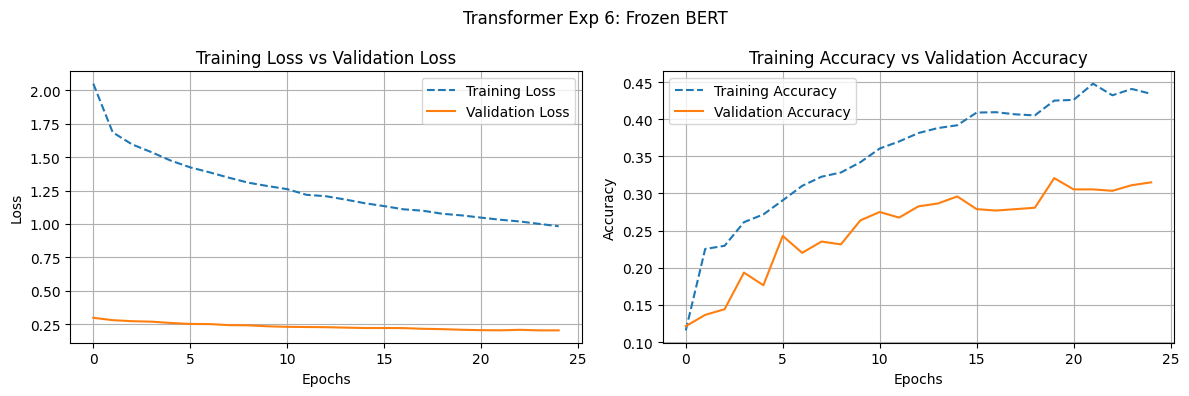

In [ ]:
plot_training(history_frozen_bert_exp6, 'Transformer Exp 6: Frozen BERT')

### Evaluating our model

In [ ]:
evaluate_bert_model(frozen_bert_exp6, threshold=0.5)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Hamming Loss: 0.0611

Classification Report (per label):
              precision    recall  f1-score   support

           0       0.50      0.10      0.17        30
           1       0.33      0.06      0.10        18
           2       0.75      0.07      0.12        45
           3       0.50      0.05      0.10        19
           4       0.96      0.31      0.47        78
           5       1.00      0.11      0.19        47
           6       0.83      0.22      0.35        45
           7       0.00      0.00      0.00        17
           8       0.83      0.29      0.43        34
           9       0.97      0.30      0.46        93
          10       0.38      0.27      0.32        11
          11       0.43      0.19      0.26        16
          12       0.00      0.00      0.00        15
          13       0.00      0.00      0.00         3
          14       0.85      0.49      0.62        35
          15       0.74      0.44     

### Experiment 6 Results and Analysis: Frozen BERT

### Results

| Metric | Exp 3 (best so far) | Exp 6 (frozen BERT) | Delta |
|---|---|---|---|
| Hamming Loss | 0.0498 | 0.0611 | +0.0113 |
| Micro F1 | 0.60 | 0.37 | -0.23 |
| Macro F1 | 0.54 | 0.25 | -0.29 |
| Weighted F1 | 0.59 | 0.34 | -0.25 |
| Micro Precision | 0.72 | 0.73 | +0.01 |
| Micro Recall | 0.51 | 0.24 | -0.27 |

### Outcome
Frozen BERT produced the worst result across all transformer experiments with a Hamming Loss of 0.0611. Despite BERT's strong general language understanding, freezing all weights and training only a shallow classification head on top failed significantly. Micro recall collapsed to 0.24, meaning the model missed 76% of true positive cases entirely. Seven labels produced an F1 of 0.00, meaning the model predicted zero positives for those labels across the entire test set.

### Analysis

**The classification head is too shallow for frozen 768-dimensional embeddings.** Previous experiments used embeddings that were learned end-to-end with the classifier, meaning the embedding representations and the classification head adapted together during training. Here BERT produces fixed 768-dimensional vectors and a single Dense(64) layer must compress all that information down to 27 label predictions with no gradient flow back into BERT. The classifier never learned to use the BERT representations effectively.

**Frozen BERT representations are generic and not task-specific.** BERT was pretrained on Wikipedia and BookCorpus to predict masked words and next sentence relationships. Without fine-tuning, its representations encode general language patterns but have no concept of SDG indicator boundaries. The distinction between indicator 3.1.1 and 3.2.1 requires the BERT layers to adapt to domain-specific patterns, which frozen weights fundamentally cannot do.

**Precision is high but meaningless in this context.** Micro precision reached 0.73, among the highest across all experiments. However this is a consequence of the model almost never predicting positive — when it does predict a label it is usually right, but it abstains on the vast majority of cases. High precision driven by extreme conservatism does not reflect a well-calibrated model.

**Note on implementation.** An initial run of this experiment used misaligned training data where BERT embeddings were extracted from the pre-ROS text (2,396 samples) while labels reflected the post-ROS dataset (2,635 samples). The embeddings were re-extracted from the correctly balanced ROS text and the model was retrained. Both runs produced consistently poor results, confirming that the failure is architectural rather than a data alignment issue.

### Insight
Frozen BERT confirms that pretrained representations alone are not sufficient for this task without domain adaptation. The model needs gradient flow through the BERT layers to adapt its representations to SDG-specific vocabulary and indicator boundaries. Experiment 7 introduces fine-tuned BERT, unfreezing the top 2 layers and allowing them to adapt to the SDG domain during training. This is expected to produce a significant improvement over frozen BERT and potentially the strongest result across all transformer experiments.

## Experiment 7: Fine-Tuned BERT (Top 2 Layers)

### What Changed
The top 2 BERT encoder layers are unfrozen and allowed to update during training. All other BERT layers remain frozen. The classification head trains jointly with these two layers on the SDG dataset. The implementation uses a full PyTorch training loop to allow gradient flow through the unfrozen layers. Learning rate is set to 2e-5, the standard recommendation for BERT fine-tuning, to prevent large weight updates that would destroy pretrained knowledge in the frozen layers.

### Why This Change Was Made
Experiment 6 confirmed that fully frozen BERT representations are too generic for this task. However jumping straight to full fine-tuning on approximately 3,000 samples carries a significant overfitting risk given BERT's 110M parameters. Unfreezing only the top 2 layers is a conservative middle ground the upper layers are closest to the output and most likely to encode task-specific patterns, while keeping the lower layers frozen preserves the general language understanding BERT was pretrained on. This minimizes overfitting risk while still allowing meaningful domain adaptation.

### What We Expect to See
A meaningful improvement in Hamming Loss compared to Experiment 6. The top 2 layers should adapt enough to SDG vocabulary and indicator boundaries to recover the recall collapse seen in frozen BERT. If the improvement is marginal, Experiment 8 will unfreeze more layers to test whether deeper adaptation is needed.

### First we identify  which bert layers to unfreeze

In [ ]:
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(device)

# freeze everything first, then selectively unfreeze
for param in bert_model.parameters():
    param.requires_grad = False

# top 2 layers are closest to output, most likely to encode task-specific patterns
for param in bert_model.encoder.layer[-2:].parameters():
    param.requires_grad = True

# pooler feeds directly into the classification head, must be trainable
for param in bert_model.pooler.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in bert_model.parameters())
print(f'Trainable: {trainable:,} / {total:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable: 14,766,336 / 109,482,240


### Tokenization and tensor prep

In [ ]:
# tokenize raw text, same max_length as padded sequences used in Keras experiments
train_encodings = bert_tokenizer(
    list(X_text_res),
    max_length=265,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

test_encodings = bert_tokenizer(
    list(X_text_test_raw),
    max_length=265,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

# handle both DataFrame and numpy array inputs
X_ohe_test_arr = X_ohe_test.values if hasattr(X_ohe_test, 'values') else X_ohe_test
y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test

train_input_ids      = train_encodings['input_ids'].to(device)
train_attention_mask = train_encodings['attention_mask'].to(device)
train_ohe            = torch.tensor(X_ohe_train, dtype=torch.float32).to(device)
train_labels         = torch.tensor(y_train, dtype=torch.float32).to(device)

test_input_ids       = test_encodings['input_ids'].to(device)
test_attention_mask  = test_encodings['attention_mask'].to(device)
test_ohe             = torch.tensor(X_ohe_test_arr, dtype=torch.float32).to(device)
test_labels          = torch.tensor(y_test_arr, dtype=torch.float32).to(device)

### Classification head, pos_weight, optimizer

In [ ]:
# CLS output (768) + OHE document type features (7) -> shared head
fc1     = nn.Linear(768 + 7, 256).to(device)
fc2     = nn.Linear(256, 128).to(device)
output  = nn.Linear(128, 27).to(device)
dropout = nn.Dropout(0.1).to(device)
relu    = nn.ReLU()
sigmoid = nn.Sigmoid()

# each label has far more negatives than positives even after ROS
# pos_weight scales the loss to penalize missed positives proportionally
label_counts = train_labels.sum(dim=0)
neg_counts   = train_labels.shape[0] - label_counts

# uncapped pos_weight was causing over-prediction on rare labels (weights up to ~877)
# cap at 10, enough to recover recall without destroying precision
pos_weight = (neg_counts / label_counts.clamp(min=1)).clamp(max=10).to(device)
print(f'pos_weight range: {pos_weight.min().item():.2f} - {pos_weight.max().item():.2f}')

# BCEWithLogitsLoss takes raw logits, sigmoid is fused internally for numerical stability
# pos_weight is why sigmoid is removed from the training forward pass
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# fixed: only passes params with requires_grad=True original passed all bert params
optimizer = torch.optim.AdamW(
    [p for p in bert_model.parameters() if p.requires_grad] +
    list(fc1.parameters()) +
    list(fc2.parameters()) +
    list(output.parameters()),
    lr=2e-5,
    weight_decay=0.01
)

pos_weight range: 1.94 - 10.00


### Training Loop

In [ ]:
# fixed: 4 epochs instead of 10, original run showed train loss 0.53->0.16 with recall collapse
EPOCHS     = 4
BATCH_SIZE = 16
n_samples  = train_input_ids.shape[0]
train_losses = []

for epoch in range(EPOCHS):
    bert_model.train()
    fc1.train()
    fc2.train()
    output.train()

    total_loss = 0
    # shuffle each epoch to avoid batch order bias
    indices = torch.randperm(n_samples)

    for i in range(0, n_samples, BATCH_SIZE):
        batch_idx = indices[i:i + BATCH_SIZE]

        input_ids      = train_input_ids[batch_idx]
        attention_mask = train_attention_mask[batch_idx]
        ohe_features   = train_ohe[batch_idx]
        labels         = train_labels[batch_idx]

        bert_out = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        # CLS token is the sequence-level representation
        cls = bert_out.last_hidden_state[:, 0, :]
        cls = dropout(cls)

        # merge BERT representation with document type signal
        merged = torch.cat([cls, ohe_features], dim=1)

        x = relu(fc1(merged))
        x = dropout(x)
        x = relu(fc2(x))
        x = dropout(x)

        # raw logits no sigmoid here, BCEWithLogitsLoss handles it internally
        logits = output(x)
        loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (n_samples // BATCH_SIZE)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}/{EPOCHS} — train loss: {avg_loss:.4f}')

print('Training complete')

Epoch 1/4 — train loss: 0.9839
Epoch 2/4 — train loss: 0.9124
Epoch 3/4 — train loss: 0.7878
Epoch 4/4 — train loss: 0.6887
Training complete


### Evaluation

In [ ]:
bert_model.eval()
fc1.eval()
fc2.eval()
output.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for i in range(0, test_input_ids.shape[0], BATCH_SIZE):
        input_ids      = test_input_ids[i:i + BATCH_SIZE]
        attention_mask = test_attention_mask[i:i + BATCH_SIZE]
        ohe_features   = test_ohe[i:i + BATCH_SIZE]
        labels         = test_labels[i:i + BATCH_SIZE]

        bert_out = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        cls      = bert_out.last_hidden_state[:, 0, :]

        merged = torch.cat([cls, ohe_features], dim=1)
        x      = relu(fc1(merged))
        x      = relu(fc2(x))

        # sigmoid applied here converts logits to probabilities for thresholding
        preds = sigmoid(output(x))

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_pred_proba = np.vstack(all_preds)
y_true       = np.vstack(all_labels)
y_pred       = (y_pred_proba >= 0.5).astype(int)

print(f'Hamming Loss: {hamming_loss(y_true, y_pred):.4f}\n')
short_labels = [str(i) for i in range(y_true.shape[1])]
print(classification_report(y_true, y_pred, target_names=short_labels, zero_division=0))

Hamming Loss: 0.1138

              precision    recall  f1-score   support

           0       0.27      0.93      0.42        30
           1       0.23      0.44      0.30        18
           2       0.38      0.89      0.53        45
           3       0.14      0.58      0.22        19
           4       0.36      0.94      0.53        78
           5       0.34      0.89      0.50        47
           6       0.53      0.84      0.65        45
           7       0.50      0.06      0.11        17
           8       0.34      0.76      0.47        34
           9       0.37      0.85      0.51        93
          10       0.50      0.55      0.52        11
          11       0.39      0.69      0.50        16
          12       0.50      0.13      0.21        15
          13       0.00      0.00      0.00         3
          14       0.39      0.97      0.55        35
          15       0.33      0.94      0.49        32
          16       0.37      0.65      0.47       102
     

### Experiment 7 Results: Fine-Tuned BERT (Top 2 Layers)

### Results
| Run | Hamming Loss | Notes |
|-----|-------------|-------|
| Initial (10 epochs, unfiltered optimizer) | 0.0723 | All-zero predictions, complete collapse |
| Fix 1 (4 epochs, filtered optimizer) | 0.1797 | Recall recovered but precision collapsed |
| Fix 2 (pos_weight capped at 10) | 0.1138 | Best result for this experiment |

### What Happened
Three iterations were needed before the model produced meaningful predictions. The first run collapsed to all-zero outputs despite the optimizer and epoch fixes. The root cause was label sparsity. Even after ROS balanced the training samples, each sample still has only a few positive labels out of 27. BCELoss learned the trivial solution: predict nothing, because the majority of the label matrix is zeros.

Switching to BCEWithLogitsLoss with pos_weight resolved the collapse but introduced a new problem. Uncapped pos_weight values reached as high as ~877 for rare labels, telling the model a missed positive is 877x worse than a false positive. The model responded by predicting almost every label for every sample, pushing Hamming Loss to 0.1797 with precision at 0.25.

Capping pos_weight at 10 produced the best result at 0.1138, but precision and recall remain unbalanced across labels. Several rare labels (7, 12, 13, 18, 20) collapsed to zero recall while the model continued over-predicting on common ones.

### Why BERT Is Struggling Here
The scratch transformer from Experiment 3 (0.0498) outperforms fine-tuned BERT (0.1138) by a significant margin. Two factors explain this. The dataset is too small, 3,000 samples cannot provide enough gradient signal to meaningfully shift BERT's representations through only 2 unfrozen layers. The SDG health indicator domain is also specialized enough that generic BERT pretraining offers limited transfer value without deeper adaptation.

### Next Step
Experiment 8 will unfreeze the top 4 encoder layers to test whether deeper adaptation closes the gap. If it does not, the finding stands: for this dataset size and domain, a lightweight scratch transformer with dropout outperforms fine-tuned BERT.

## Experiment 8: Fine-Tuned BERT (Top 4 Layers)

### What Changed
The number of unfrozen BERT encoder layers increases from 2 to 4. All other design
decisions carry over from Experiment 7: the same classification head, BCEWithLogitsLoss
with pos_weight capped at 10, AdamW at 2e-5, 4 epochs, and batch size 16.

### Why This Change Was Made
Experiment 7 produced a Hamming Loss of 0.1138, well above the scratch transformer
result of 0.0498. Two unfrozen layers were not enough to shift BERT representations
toward SDG health indicator vocabulary. Unfreezing layers 8 through 11 gives the model
deeper access to task-specific adaptation while still keeping the lower 8 layers frozen
to preserve general language understanding.

### What We Expect to See
A lower Hamming Loss than Experiment 7. If the result is still above 0.06, it suggests
the dataset is too small for BERT fine-tuning to compete with the scratch transformer
regardless of how many layers are unfrozen.

In [ ]:
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(device)

# freeze all layers first
for param in bert_model.parameters():
    param.requires_grad = False

# unfreeze top 4 encoder layers (indices 8-11) instead of 2
# gives the model deeper access to task-specific adaptation
for param in bert_model.encoder.layer[-4:].parameters():
    param.requires_grad = True

# pooler connects BERT output to the classification head, must stay trainable
for param in bert_model.pooler.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in bert_model.parameters())
print(f'Trainable: {trainable:,} / {total:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable: 28,942,080 / 109,482,240


In [ ]:
# same max_length as all previous experiments
train_encodings = bert_tokenizer(
    list(X_text_res),
    max_length=265,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

test_encodings = bert_tokenizer(
    list(X_text_test_raw),
    max_length=265,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

# handle both DataFrame and numpy array inputs
X_ohe_test_arr = X_ohe_test.values if hasattr(X_ohe_test, 'values') else X_ohe_test
y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test

train_input_ids      = train_encodings['input_ids'].to(device)
train_attention_mask = train_encodings['attention_mask'].to(device)
train_ohe            = torch.tensor(X_ohe_train, dtype=torch.float32).to(device)
train_labels         = torch.tensor(y_train, dtype=torch.float32).to(device)

test_input_ids       = test_encodings['input_ids'].to(device)
test_attention_mask  = test_encodings['attention_mask'].to(device)
test_ohe             = torch.tensor(X_ohe_test_arr, dtype=torch.float32).to(device)
test_labels          = torch.tensor(y_test_arr, dtype=torch.float32).to(device)

In [ ]:
# CLS output (768) concatenated with OHE document type features (7)
fc1     = nn.Linear(768 + 7, 256).to(device)
fc2     = nn.Linear(256, 128).to(device)
output  = nn.Linear(128, 27).to(device)
dropout = nn.Dropout(0.1).to(device)
relu    = nn.ReLU()
sigmoid = nn.Sigmoid()

# pos_weight corrects for label sparsity, capped at 10 to prevent over-prediction
# same cap as Exp 7 so results are directly comparable
label_counts = train_labels.sum(dim=0)
neg_counts   = train_labels.shape[0] - label_counts
pos_weight   = (neg_counts / label_counts.clamp(min=1)).clamp(max=10).to(device)
print(f'pos_weight range: {pos_weight.min().item():.2f} - {pos_weight.max().item():.2f}')

# BCEWithLogitsLoss fuses sigmoid into the loss for numerical stability
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# optimizer only covers params with requires_grad=True
# top 4 layers + pooler + classification head
optimizer = torch.optim.AdamW(
    [p for p in bert_model.parameters() if p.requires_grad] +
    list(fc1.parameters()) +
    list(fc2.parameters()) +
    list(output.parameters()),
    lr=2e-5,
    weight_decay=0.01
)

pos_weight range: 1.94 - 10.00


In [ ]:
# 4 epochs, consistent with Exp 7 for a fair comparison
EPOCHS     = 4
BATCH_SIZE = 16
n_samples  = train_input_ids.shape[0]
train_losses = []

for epoch in range(EPOCHS):
    bert_model.train()
    fc1.train()
    fc2.train()
    output.train()

    total_loss = 0
    # shuffle indices each epoch to avoid batch order bias
    indices = torch.randperm(n_samples)

    for i in range(0, n_samples, BATCH_SIZE):
        batch_idx = indices[i:i + BATCH_SIZE]

        input_ids      = train_input_ids[batch_idx]
        attention_mask = train_attention_mask[batch_idx]
        ohe_features   = train_ohe[batch_idx]
        labels         = train_labels[batch_idx]

        bert_out = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        # CLS token is the sequence-level representation
        cls = bert_out.last_hidden_state[:, 0, :]
        cls = dropout(cls)

        # merge BERT representation with document type signal
        merged = torch.cat([cls, ohe_features], dim=1)

        x = relu(fc1(merged))
        x = dropout(x)
        x = relu(fc2(x))
        x = dropout(x)

        # raw logits passed to loss, no sigmoid here
        logits = output(x)
        loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (n_samples // BATCH_SIZE)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}/{EPOCHS} | train loss: {avg_loss:.4f}')

print('Training complete')

Epoch 1/4 | train loss: 0.9784
Epoch 2/4 | train loss: 0.8762
Epoch 3/4 | train loss: 0.7529
Epoch 4/4 | train loss: 0.6448
Training complete


In [ ]:
bert_model.eval()
fc1.eval()
fc2.eval()
output.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for i in range(0, test_input_ids.shape[0], BATCH_SIZE):
        input_ids      = test_input_ids[i:i + BATCH_SIZE]
        attention_mask = test_attention_mask[i:i + BATCH_SIZE]
        ohe_features   = test_ohe[i:i + BATCH_SIZE]
        labels         = test_labels[i:i + BATCH_SIZE]

        bert_out = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        cls      = bert_out.last_hidden_state[:, 0, :]

        # no dropout at eval, .eval() disables it automatically
        merged = torch.cat([cls, ohe_features], dim=1)
        x      = relu(fc1(merged))
        x      = relu(fc2(x))

        # sigmoid converts logits to probabilities for thresholding
        preds = sigmoid(output(x))

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_pred_proba = np.vstack(all_preds)
y_true       = np.vstack(all_labels)
y_pred       = (y_pred_proba >= 0.5).astype(int)

print(f'Hamming Loss: {hamming_loss(y_true, y_pred):.4f}\n')
short_labels = [str(i) for i in range(y_true.shape[1])]
print(classification_report(y_true, y_pred, target_names=short_labels, zero_division=0))

Hamming Loss: 0.1078

              precision    recall  f1-score   support

           0       0.29      0.90      0.44        30
           1       0.19      0.56      0.28        18
           2       0.37      0.91      0.53        45
           3       0.16      0.68      0.26        19
           4       0.46      0.91      0.61        78
           5       0.39      0.83      0.53        47
           6       0.77      0.91      0.84        45
           7       0.00      0.00      0.00        17
           8       0.56      0.71      0.62        34
           9       0.35      0.82      0.49        93
          10       0.35      0.64      0.45        11
          11       0.33      0.81      0.47        16
          12       0.53      0.67      0.59        15
          13       0.00      0.00      0.00         3
          14       0.37      0.94      0.53        35
          15       0.38      0.94      0.54        32
          16       0.33      0.77      0.47       102
     

## Experiment 8 Results: Fine-Tuned BERT (Top 4 Layers)

### Results
| Experiment | Unfrozen Layers | Hamming Loss |
|------------|----------------|--------------|
| Exp 6 | 0 (frozen) | 0.0611 |
| Exp 7 | 2 | 0.1138 |
| Exp 8 | 4 | 0.1078 |

### What Happened
Unfreezing 4 layers instead of 2 produced a marginal improvement of 0.006 in Hamming
Loss. The overall pattern holds: recall is high (0.79 micro avg) but precision remains
low (0.38 micro avg), meaning the model is still over-predicting across most labels.
Labels 7 and 13 collapsed to zero recall entirely, both of which have very few positive
samples in the test set (17 and 3 respectively).

### Why More Layers Did Not Help
The jump from 2 to 4 unfrozen layers moved Hamming Loss by 0.006. Extrapolating that
trend, unfreezing all 12 layers would still not close the gap to the scratch transformer
result of 0.0498. The bottleneck is not which layers are frozen. It is the dataset size.
3,000 samples cannot provide enough gradient signal to meaningfully shift BERT's
representations toward SDG health indicator vocabular